# Graph-based Drug Repurposing using PrimeKG.

### Team - 6.
-------------------------------------------------------------------
* #### Contributors :

1. Athul Dinesh
2. Dilep Shetty Ittanguru Venkatesh
3. Stuti Jandhyala

-------------------------------------------------------------------


* This notebook documents the end-to-end workflow for building a biomedical knowledge graph from PrimeKG and using it for drug repurposing experiments. The workflow covers data preparation, graph construction, model training, evaluation, evidence-aware reranking, and a final demo query.

## 1. Environment setup

This section installs the required graph learning libraries, imports the packages used throughout the notebook, and prints a quick environment check so the runtime can be verified before loading data.


In [1]:
# BLOCK 01 - Environment Setup

# Install PyTorch

!pip install --quiet torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 \
    --index-url https://download.pytorch.org/whl/cu128

# Install PyG sparse/scatter extensions

!pip install --quiet pyg-lib \
    -f https://data.pyg.org/whl/torch-2.8.0+cu128.html

import torch

!pip install --quiet \
    torch-scatter \
    torch-sparse \
    torch-cluster \
    -f https://data.pyg.org/whl/torch-{torch.__version__}.html

# Install PyG
!pip install --quiet git+https://github.com/pyg-team/pytorch_geometric.git

# Standard libraries
import warnings
import sys
import platform
import random
import copy
import math
import re
import difflib
import json
from pathlib import Path
from copy import deepcopy
from collections import defaultdict, Counter
from datetime import datetime

warnings.filterwarnings("ignore")

# Dataframe and Display imports
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows",    20)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width",       200)

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import networkx as nx
import textwrap

# Metrics and ML utilities
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    matthews_corrcoef,
    log_loss,
    ndcg_score,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.calibration import calibration_curve

# PyTorch + PyG
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch_geometric
import torch_scatter
import torch_sparse
import torch_cluster

from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv, HGTConv, Linear

try:
    import pyg_lib
    _pyg_lib_version = pyg_lib.__version__
except ImportError:
    _pyg_lib_version = "not installed"

# Google Colab utilities
from google.colab import drive
from IPython.display import Image, display

# Global reproducibility seed
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)


# Environment summary
print("=" * 55)
print("  ENVIRONMENT SUMMARY")
print("=" * 55)
print(f"  Python          : {sys.version.split()[0]}")
print(f"  Platform        : {platform.platform()}")
print()
print(f"  PyTorch         : {torch.__version__}")
print(f"  CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  CUDA version    : {torch.version.cuda}")
    print(f"  GPU             : {torch.cuda.get_device_name(0)}")
print()
print(f"  PyG             : {torch_geometric.__version__}")
print(f"  torch-scatter   : {torch_scatter.__version__}")
print(f"  torch-sparse    : {torch_sparse.__version__}")
print(f"  torch-cluster   : {torch_cluster.__version__}")
print(f"  pyg-lib         : {_pyg_lib_version}")
print()

# Select device : used globally throughout the notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Active device   : {device}")
print("=" * 55)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 116.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 135.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 126.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  ENVIRONMENT SUMMARY
  Python          : 3.12.13
  Platform        : Linux-6.6.113+-x86_64-with-glibc2.35

  PyTorch         : 2.8.0+cu128
  CUDA 

## 2. Load the PrimeKG dataset

Mount Google Drive, point to the PrimeKG source folder, and load `kg.csv` into `raw_df`. The inspection steps that follow are mainly there to confirm the file loaded correctly.

In [2]:
# Mount Google Drive
drive.mount("/content/drive")

# Set the dataset path
DATA_DIR = Path("/content/drive/MyDrive/DS5500 - Capstone Project/Datasets/source")

%cd {DATA_DIR}

KG_FILE = DATA_DIR / "kg.csv"

if not KG_FILE.exists():
    raise FileNotFoundError(
        f"kg.csv not found at {KG_FILE}.\n"
        "Download PrimeKG from: https://github.com/mims-harvard/PrimeKG"
    )

# Load the raw CSV
print("Loading kg.csv - Consists of ~8M records")
raw_df = pd.read_csv(KG_FILE, low_memory=False)
print("Done.\n")

# Basic inspection
print("=" * 55)
print("  DATASET SUMMARY")
print("=" * 55)
print(f"  Rows    : {len(raw_df):,}")
print(f"  Columns : {raw_df.shape[1]}")
print(f"  Memory  : {raw_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()
print("  Column names:")
for col in raw_df.columns:
    print(f"    {col}")
print("=" * 55)

# Check missing values and duplicates
missing = raw_df.isnull().sum()
if missing.any():
    print("\n  Missing values per column:")
    print(missing[missing > 0].to_string())
else:
    print("\n  No missing values found.")

n_dupes = raw_df.duplicated().sum()
print(f"\n  Duplicate rows : {n_dupes:,}")

# Preview the data
print("\n  First 5 rows:")
display(raw_df.head())

print("\n  Column dtypes:")
display(raw_df.dtypes.to_frame("dtype"))

print("\n  Original Dataset:")
raw_df

Mounted at /content/drive
/content/drive/MyDrive/DS5500 - Capstone Project/Datasets/source
Loading kg.csv - Consists of ~8M records
Done.

  DATASET SUMMARY
  Rows    : 8,100,498
  Columns : 12
  Memory  : 4678.7 MB

  Column names:
    relation
    display_relation
    x_index
    x_id
    x_type
    x_name
    x_source
    y_index
    y_id
    y_type
    y_name
    y_source

  No missing values found.

  Duplicate rows : 0

  First 5 rows:


,relation,display_relation,x_index,x_id,x_type,x_name,x_source,y_index,y_id,y_type,y_name,y_source
0,protein_protein,ppi,0,9796,gene/protein,PHYHIP,NCBI,8889,56992,gene/protein,KIF15,NCBI
1,protein_protein,ppi,1,7918,gene/protein,GPANK1,NCBI,2798,9240,gene/protein,PNMA1,NCBI
2,protein_protein,ppi,2,8233,gene/protein,ZRSR2,NCBI,5646,23548,gene/protein,TTC33,NCBI
3,protein_protein,ppi,3,4899,gene/protein,NRF1,NCBI,11592,11253,gene/protein,MAN1B1,NCBI
4,protein_protein,ppi,4,5297,gene/protein,PI4KA,NCBI,2122,8601,gene/protein,RGS20,NCBI



  Column dtypes:


,dtype
relation,object
display_relation,object
x_index,int64
x_id,object
x_type,object
x_name,object
x_source,object
y_index,int64
y_id,object
y_type,object



  Original Dataset:


,relation,display_relation,x_index,x_id,x_type,x_name,x_source,y_index,y_id,y_type,y_name,y_source
0,protein_protein,ppi,0,9796,gene/protein,PHYHIP,NCBI,8889,56992,gene/protein,KIF15,NCBI
1,protein_protein,ppi,1,7918,gene/protein,GPANK1,NCBI,2798,9240,gene/protein,PNMA1,NCBI
2,protein_protein,ppi,2,8233,gene/protein,ZRSR2,NCBI,5646,23548,gene/protein,TTC33,NCBI
3,protein_protein,ppi,3,4899,gene/protein,NRF1,NCBI,11592,11253,gene/protein,MAN1B1,NCBI
4,protein_protein,ppi,4,5297,gene/protein,PI4KA,NCBI,2122,8601,gene/protein,RGS20,NCBI
...,...,...,...,...,...,...,...,...,...,...,...,...
8100493,anatomy_protein_absent,expression absent,66747,4720,anatomy,cerebellar vermis,UBERON,5259,140,gene/protein,ADORA3,NCBI
8100494,anatomy_protein_absent,expression absent,63824,1377,anatomy,quadriceps femoris,UBERON,58254,105378952,gene/protein,KLF18,NCBI
8100495,anatomy_protein_absent,expression absent,63826,1379,anatomy,vastus lateralis,UBERON,58254,105378952,gene/protein,KLF18,NCBI
8100496,anatomy_protein_absent,expression absent,64523,2084,anatomy,heart left ventricle,UBERON,58254,105378952,gene/protein,KLF18,NCBI


## 3. Preprocess and standardize the edge table

This block transforms the raw PrimeKG edge table into a cleaner and more consistent format that can be used in the later graph-building and modeling steps.

The main purpose of this block is to produce a **canonical edge table** where every kept relation has:
- a consistent relation label
- a clearly defined source and destination node
- normalized node types
- globally unique node identifiers
- duplicate edges removed

### Step A: Select the required columns and clean the data

## Relationship Types

### Positive Relationships (`+ve`)

| # | Relation | Display Relation |
|---|----------|------------------|
| 1 | `indication` | drug → indication → disease |
| 2 | `disease_protein` | disease → associated with → protein |
| 3 | `drug_protein` | drug → carrier → protein |
| 4 | `drug_protein` | drug → enzyme → protein |
| 5 | `drug_protein` | drug → target → protein |
| 6 | `drug_protein` | drug → transporter → protein |
| 7 | `phenotype_protein` | phenotype → associated with → protein |
| 8 | `disease_phenotype_positive` | disease → phenotype present → phenotype |

### Similarity Relationships

| # | Relation | Display Relation |
|---|----------|------------------|
| 1 | `disease_disease` | disease → parent-child → disease |
| 2 | `phenotype_phenotype` | phenotype → parent-child → phenotype |
| 3 | `protein_protein` | protein → ppi → protein |

### Negative Relationships (`-ve`)

| # | Relation | Display Relation |
|---|----------|------------------|
| 1 | `contraindication` | drug → contraindication → disease |
| 2 | `drug_effect` | drug → side effect → effect |


### Step B: Filter to the relation types used in this project

PrimeKG includes many different biomedical relations, but not all of them are needed for the drug repurposing pipeline. This section keeps only the subset of relations relevant to the project, including:

- **drug–disease treatment links** such as `indication`
- **drug–disease risk links** such as `contraindication`
- **drug–protein interaction types** such as carrier, enzyme, target, and transporter
- **disease–protein** and **phenotype–protein** associations
- **disease–phenotype** links
- **disease** and **phenotype ontology hierarchy** links
- **protein–protein interaction** edges
- **drug side effect** edges

The filtering is done using valid `(relation, display_relation)` pairs so that only the intended meanings are retained. This is important because some raw relation names are broad and need the display label to clarify the exact relationship.

### Step C: Normalize node types

One issue in the raw PrimeKG data is that some node types are not specific enough. For example, the raw type `effect/phenotype` can refer either to a phenotype or to a drug side effect depending on the relation context.

To fix this, the block creates normalized node types such as:
- `drug`
- `disease`
- `protein`
- `phenotype`
- `effect`

Straightforward raw types like `drug`, `disease`, and `gene/protein` are mapped directly.  
The ambiguous `effect/phenotype` type is resolved using the relation it appears in:
- if it appears in disease or phenotype relations, it becomes `phenotype`
- if it appears in drug side-effect relations, it becomes `effect`

### Step D: Create canonical entity UIDs

After normalizing node types, the block creates a **canonical unique identifier** for every node using the format:

`<normalized_type>:<raw_id>`

For example, a drug and a disease could both have the same numeric ID in the original dataset, but once the type is added, they become distinct identifiers.

### Step E: Standardize edge labels and enforce direction

This is one of the most important parts of the block.

First, each `(relation, display_relation)` pair is mapped to a single **canonical edge label**. For example:
- `indication` stays as `indication`
- `drug_protein` with `target` becomes `drug_target_protein`
- `disease_protein` with `associated with` becomes `disease_associated_with_protein`

This creates a cleaner and more explicit edge vocabulary.

Next, the block defines a **canonical direction** for every edge label. For example:
- `indication` should always go from **drug → disease**
- `disease_associated_with_protein` should always go from **disease → protein**
- `drug_has_side_effect` should always go from **drug → effect**

However, in the raw data, some rows may appear in the opposite direction. To fix this, the code checks whether each row is already in the correct order or needs to be flipped. If necessary, the source and destination columns are swapped so that every retained edge follows the same direction convention.

A boolean column called `is_flipped` is stored so it is still possible to tell which rows had to be reversed during preprocessing.

This step is essential because later graph construction and model training depend on consistent edge direction.

### Step F: Deduplicate edges

After canonicalization, some edges can still appear more than once. This often happens because:
- the raw file may include repeated rows
- an edge may have existed in both directions before standardization
- some relations, such as protein–protein interaction, are naturally undirected

To handle this, the block creates a deduplication key based on:
- the canonical edge label
- the source UID
- the destination UID

For undirected relations like protein–protein interactions, the source and destination UIDs are first sorted so that `(A, B)` and `(B, A)` are treated as the same edge.

Once duplicates are removed, each remaining edge is assigned a stable `canonical_edge_id`.

In [3]:
# Preprocess and standardize

assert "raw_df" in globals(), "raw_df not found — run Block 02 first."

# A. column selection and type coercion

# Keep only the columns used later
REQUIRED_COLUMNS = [
    "relation", "display_relation",
    "x_index", "x_id", "x_type", "x_name", "x_source",
    "y_index", "y_id", "y_type", "y_name", "y_source",
]

# Validate the expected schema
missing_cols = [c for c in REQUIRED_COLUMNS if c not in raw_df.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns in kg.csv: {missing_cols}")

# make a working copy
df = raw_df[REQUIRED_COLUMNS].copy()

# Clean string columns
df["x_index"] = pd.to_numeric(df["x_index"], errors="coerce")
df["y_index"] = pd.to_numeric(df["y_index"], errors="coerce")

STRING_COLS = [c for c in REQUIRED_COLUMNS if c not in ("x_index", "y_index")]
df[STRING_COLS] = df[STRING_COLS].astype(str).apply(lambda s: s.str.strip())

# Preserve the original row index for traceability
df["raw_row_id"] = df.index

print(f"[A] Column selection done — shape: {df.shape}")


# B.relation + display_relation filtering

# Keep only the necessary relation types
RELATION_DISPLAY_RULES: dict[str, set] = {
    # Therapeutic
    "indication":              {"indication"},
    "contraindication":        {"contraindication"},
    # Drug mechanism
    "drug_protein":            {"carrier", "enzyme", "target", "transporter"},
    # Disease / phenotype biology
    "disease_protein":         {"associated with"},
    "phenotype_protein":       {"associated with"},
    "disease_phenotype_positive": {"phenotype present"},
    # Ontology hierarchies + PPI
    "disease_disease":         {"parent-child"},
    "phenotype_phenotype":     {"parent-child"},
    "protein_protein":         {"ppi"},
    # Safety
    "drug_effect":             {"side effect"},
}

# Build the filter using a vectorized merge instead of row-wise apply.
# Create a set of (relation, display_relation) valid pairs for fast lookup.
valid_pairs = {
    (rel, disp)
    for rel, disps in RELATION_DISPLAY_RULES.items()
    for disp in disps
}

keep_mask = df.apply(
    lambda row: (row["relation"], row["display_relation"]) in valid_pairs,
    axis=1,
)
df = df[keep_mask].copy().reset_index(drop=True)

print(f"[B] Relation filtering done — shape: {df.shape}")
print(f"    Relation counts:")
print(df["relation"].value_counts().to_string())


# C. Node type normalization

# Direct type map for the three unambiguous raw types
_SIMPLE_TYPE_MAP = {"drug": "drug", "disease": "disease", "gene/protein": "protein"}

df["x_type_norm"] = df["x_type"].map(_SIMPLE_TYPE_MAP)
df["y_type_norm"] = df["y_type"].map(_SIMPLE_TYPE_MAP)

# Resolve "effect/phenotype" by relation context
# Build a lookup: (relation, raw_type) → normalized_type
_EFFECT_PHENO_MAP: dict[tuple, str] = {
    ("disease_phenotype_positive", "effect/phenotype"): "phenotype",
    ("phenotype_protein",          "effect/phenotype"): "phenotype",
    ("phenotype_phenotype",        "effect/phenotype"): "phenotype",
    ("drug_effect",                "effect/phenotype"): "effect",
}

for (rel, raw_type), norm_type in _EFFECT_PHENO_MAP.items():
    rel_mask = df["relation"] == rel
    df.loc[rel_mask & (df["x_type"] == raw_type), "x_type_norm"] = norm_type
    df.loc[rel_mask & (df["y_type"] == raw_type), "y_type_norm"] = norm_type

# Validate: no row should be left unmapped
unmapped_x = df["x_type_norm"].isna().sum()
unmapped_y = df["y_type_norm"].isna().sum()
if unmapped_x or unmapped_y:
    bad = df[df["x_type_norm"].isna() | df["y_type_norm"].isna()][
        ["raw_row_id", "relation", "x_type", "y_type"]
    ]
    raise ValueError(
        f"Node type normalization failed: {unmapped_x} unmapped x-side, "
        f"{unmapped_y} unmapped y-side.\nSample:\n{bad.head()}"
    )

print(f"[C] Node type normalization done.")
print(f"    x_type_norm unique: {sorted(df['x_type_norm'].unique())}")
print(f"    y_type_norm unique: {sorted(df['y_type_norm'].unique())}")


# D. Canonical entity uids

df["x_uid"] = df["x_type_norm"] + ":" + df["x_id"].astype(str)
df["y_uid"] = df["y_type_norm"] + ":" + df["y_id"].astype(str)

# No UID should be empty or contain NaN
assert not df["x_uid"].str.contains("nan", na=True).any(), "x_uid contains NaN"
assert not df["y_uid"].str.contains("nan", na=True).any(), "y_uid contains NaN"

# Each UID maps to exactly one normalized type
for side, uid_col, type_col in [("x", "x_uid", "x_type_norm"), ("y", "y_uid", "y_type_norm")]:
    multi_type = df.groupby(uid_col)[type_col].nunique()
    bad = multi_type[multi_type > 1]
    if not bad.empty:
        raise ValueError(f"{side}_uid maps to multiple types: {bad.head()}")

print(f"[D] Canonical UIDs created.")
print(f"    Unique x_uid: {df['x_uid'].nunique():,}")
print(f"    Unique y_uid: {df['y_uid'].nunique():,}")
print(f"    Total unique nodes: {pd.concat([df['x_uid'], df['y_uid']]).nunique():,}")


# E. Canonical edge labels + direction enforcement

# Map (relation, display_relation) → canonical edge label
_EDGE_LABEL_MAP: dict[tuple, str] = {
    ("indication",                  "indication"):      "indication",
    ("contraindication",            "contraindication"): "contraindication",
    ("disease_protein",             "associated with"): "disease_associated_with_protein",
    ("phenotype_protein",           "associated with"): "phenotype_associated_with_protein",
    ("disease_phenotype_positive",  "phenotype present"): "disease_has_phenotype",
    ("disease_disease",             "parent-child"):    "disease_parent_child_disease",
    ("phenotype_phenotype",         "parent-child"):    "phenotype_parent_child_phenotype",
    ("protein_protein",             "ppi"):             "protein_interacts_with_protein",
    ("drug_effect",                 "side effect"):     "drug_has_side_effect",
    ("drug_protein",                "carrier"):         "drug_carrier_protein",
    ("drug_protein",                "enzyme"):          "drug_enzyme_protein",
    ("drug_protein",                "target"):          "drug_target_protein",
    ("drug_protein",                "transporter"):     "drug_transporter_protein",
}

df["edge_label"] = df.apply(
    lambda row: _EDGE_LABEL_MAP.get((row["relation"], row["display_relation"])),
    axis=1,
)

# Validate all rows got a label
if df["edge_label"].isna().any():
    bad = df[df["edge_label"].isna()][["raw_row_id", "relation", "display_relation"]].head()
    raise ValueError(
        f"Some rows got no edge label:\n{bad}"
    )

# Define the one canonical (src_type, dst_type) per edge label
_CANONICAL_DIRECTION: dict[str, tuple] = {
    "indication":                         ("drug",      "disease"),
    "contraindication":                   ("drug",      "disease"),
    "disease_associated_with_protein":    ("disease",   "protein"),
    "drug_carrier_protein":               ("drug",      "protein"),
    "drug_enzyme_protein":                ("drug",      "protein"),
    "drug_target_protein":                ("drug",      "protein"),
    "drug_transporter_protein":           ("drug",      "protein"),
    "phenotype_associated_with_protein":  ("phenotype", "protein"),
    "disease_has_phenotype":              ("disease",   "phenotype"),
    "disease_parent_child_disease":       ("disease",   "disease"),
    "phenotype_parent_child_phenotype":   ("phenotype", "phenotype"),
    "protein_interacts_with_protein":     ("protein",   "protein"),
    "drug_has_side_effect":               ("drug",      "effect"),
}

# Vectorized direction enforcement

# Add a helper column: expected src_type for each row's edge_label
df["_exp_src"] = df["edge_label"].map(lambda lbl: _CANONICAL_DIRECTION[lbl][0])
df["_exp_dst"] = df["edge_label"].map(lambda lbl: _CANONICAL_DIRECTION[lbl][1])

# Rows that are already in canonical order
already_ok  = (df["x_type_norm"] == df["_exp_src"]) & (df["y_type_norm"] == df["_exp_dst"])
# Rows that need to be flipped
needs_flip  = (df["x_type_norm"] == df["_exp_dst"]) & (df["y_type_norm"] == df["_exp_src"])

# Rows that match neither direction
neither = ~(already_ok | needs_flip)
if neither.any():
    bad_rows = df[neither][["raw_row_id", "edge_label", "x_type_norm", "y_type_norm"]].head()
    raise ValueError(
        f"Found rows where neither x→y nor y→x matches canonical direction:\n{bad_rows}"
    )

# Build canonical src/dst columns using np.where for the swap — O(rows), no loops
def _swap_col(col_ok, col_flipped):
    """Return col_ok where already_ok, col_flipped where needs_flip."""
    return np.where(already_ok, col_ok, col_flipped)

df["src_uid"]       = _swap_col(df["x_uid"],       df["y_uid"])
df["src_type"]      = _swap_col(df["x_type_norm"],  df["y_type_norm"])
df["src_id_raw"]    = _swap_col(df["x_id"],         df["y_id"])
df["src_name"]      = _swap_col(df["x_name"],       df["y_name"])
df["src_source"]    = _swap_col(df["x_source"],     df["y_source"])
df["src_index_raw"] = _swap_col(df["x_index"],      df["y_index"])

df["dst_uid"]       = _swap_col(df["y_uid"],        df["x_uid"])
df["dst_type"]      = _swap_col(df["y_type_norm"],  df["x_type_norm"])
df["dst_id_raw"]    = _swap_col(df["y_id"],         df["x_id"])
df["dst_name"]      = _swap_col(df["y_name"],       df["x_name"])
df["dst_source"]    = _swap_col(df["y_source"],     df["x_source"])
df["dst_index_raw"] = _swap_col(df["y_index"],      df["x_index"])

df["is_flipped"] = needs_flip

# Drop the helper columns
df.drop(columns=["_exp_src", "_exp_dst"], inplace=True)

print(f"[E] Edge labels + direction done.")
print(f"    Rows kept as-is : {already_ok.sum():,}")
print(f"    Rows flipped     : {needs_flip.sum():,}")


# F. Edge deduplication

# Undirected edge types: deduplicate (A, B) and (B, A) as the same edge
UNDIRECTED_LABELS = {"protein_interacts_with_protein"}

# For undirected edges, sort UID pair lexicographically before hashing
dedup_src = df["src_uid"].copy()
dedup_dst = df["dst_uid"].copy()

undirected_mask = df["edge_label"].isin(UNDIRECTED_LABELS)
dedup_src[undirected_mask] = df.loc[undirected_mask, ["src_uid", "dst_uid"]].min(axis=1)
dedup_dst[undirected_mask] = df.loc[undirected_mask, ["src_uid", "dst_uid"]].max(axis=1)

# Build a single string dedup key per row
df["_dedup_key"] = df["edge_label"] + "||" + dedup_src + "||" + dedup_dst

n_before = len(df)
df = df.drop_duplicates(subset="_dedup_key", keep="first").copy()
df.drop(columns=["_dedup_key"], inplace=True)
df.reset_index(drop=True, inplace=True)

# Give each unique canonical edge a stable ID
df["canonical_edge_id"] = df.index

n_removed = n_before - len(df)
print(f"[F] Deduplication done.")
print(f"    Edges before : {n_before:,}")
print(f"    Edges removed: {n_removed:,}")
print(f"    Edges after  : {len(df):,}")


# Final output

canonical_edges_df = df[
    [
        "canonical_edge_id",
        "raw_row_id",
        "edge_label",
        "src_uid",  "src_type",  "src_id_raw",  "src_name",  "src_source",  "src_index_raw",
        "dst_uid",  "dst_type",  "dst_id_raw",  "dst_name",  "dst_source",  "dst_index_raw",
        "is_flipped",
    ]
].copy()

print("\n" + "=" * 55)
print("  CANONICAL EDGES TABLE COMPLETE")
print("=" * 55)
print(f"  Total edges : {len(canonical_edges_df):,}")
print()
print("  Edge label counts:")
print(canonical_edges_df["edge_label"].value_counts().to_string())
print()
print("  Type signatures  (src_type → edge_label → dst_type):")
sig = (
    canonical_edges_df
    .groupby(["src_type", "edge_label", "dst_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["src_type", "edge_label"])
)
display(sig)
print()
print("  Sample rows:")
display(canonical_edges_df.head(10))

[A] Column selection done — shape: (8100498, 13)
[B] Relation filtering done — shape: (1473126, 13)
    Relation counts:
relation
protein_protein               642150
disease_phenotype_positive    300634
disease_protein               160822
drug_effect                   129568
disease_disease                64388
contraindication               61350
drug_protein                   51306
phenotype_phenotype            37472
indication                     18776
phenotype_protein               6660
[C] Node type normalization done.
    x_type_norm unique: ['disease', 'drug', 'effect', 'phenotype', 'protein']
    y_type_norm unique: ['disease', 'drug', 'effect', 'phenotype', 'protein']
[D] Canonical UIDs created.
    Unique x_uid: 59,121
    Unique y_uid: 59,121
    Total unique nodes: 59,121
[E] Edge labels + direction done.
    Rows kept as-is : 1,108,568
    Rows flipped     : 1,108,568
[F] Deduplication done.
    Edges before : 1,473,126
    Edges removed: 685,633
    Edges after  : 787

,src_type,edge_label,dst_type,count
0,disease,disease_associated_with_protein,protein,80411
1,disease,disease_has_phenotype,phenotype,150317
2,disease,disease_parent_child_disease,disease,64388
3,drug,contraindication,disease,30675
4,drug,drug_carrier_protein,protein,864
5,drug,drug_enzyme_protein,protein,5317
6,drug,drug_has_side_effect,effect,64784
7,drug,drug_target_protein,protein,16380
8,drug,drug_transporter_protein,protein,3092
9,drug,indication,disease,9388



  Sample rows:


,canonical_edge_id,raw_row_id,edge_label,src_uid,src_type,src_id_raw,src_name,src_source,src_index_raw,dst_uid,dst_type,dst_id_raw,dst_name,dst_source,dst_index_raw,is_flipped
0,0,0,protein_interacts_with_protein,protein:9796,protein,9796,PHYHIP,NCBI,0,protein:56992,protein,56992,KIF15,NCBI,8889,True
1,1,1,protein_interacts_with_protein,protein:7918,protein,7918,GPANK1,NCBI,1,protein:9240,protein,9240,PNMA1,NCBI,2798,True
2,2,2,protein_interacts_with_protein,protein:8233,protein,8233,ZRSR2,NCBI,2,protein:23548,protein,23548,TTC33,NCBI,5646,True
3,3,3,protein_interacts_with_protein,protein:4899,protein,4899,NRF1,NCBI,3,protein:11253,protein,11253,MAN1B1,NCBI,11592,True
4,4,4,protein_interacts_with_protein,protein:5297,protein,5297,PI4KA,NCBI,4,protein:8601,protein,8601,RGS20,NCBI,2122,True
5,5,5,protein_interacts_with_protein,protein:6564,protein,6564,SLC15A1,NCBI,5,protein:8933,protein,8933,RTL8C,NCBI,2352,True
6,6,6,protein_interacts_with_protein,protein:8668,protein,8668,EIF3I,NCBI,6,protein:22976,protein,22976,PAXIP1,NCBI,5164,True
7,7,7,protein_interacts_with_protein,protein:10826,protein,10826,FAXDC2,NCBI,7,protein:345274,protein,345274,SLC10A6,NCBI,3934,True
8,8,8,protein_interacts_with_protein,protein:4489,protein,4489,MT1A,NCBI,8,protein:7157,protein,7157,TP53,NCBI,1785,True
9,9,9,protein_interacts_with_protein,protein:6272,protein,6272,SORT1,NCBI,9,protein:54873,protein,54873,PALMD,NCBI,13895,True


## 4. Build the node and edge tables

## 4. Build the master node table

This block creates a unified node table from the canonical edge table produced in Block 3. Instead of repeatedly pulling node information from the source and destination columns of the edge table, this block creates a separate node-level reference table where each node appears only once.

### A. Extract nodes from the canonical edge table

The block starts by checking that `canonical_edges_df` is available. It then pulls node information from both sides of each edge:
- the source node columns
- the destination node columns

Since source and destination nodes are stored in parallel columns, both sets are renamed into the same schema and then combined into one dataframe. This gives a complete list of all nodes that appear anywhere in the processed graph.

### B. Remove duplicates and validate node consistency

After combining source and destination nodes, the block removes duplicate entries so that each `node_uid` appears only once in the final node table. The `node_uid` created earlier is used as the main identifier because it is globally unique across all node types.

The block also checks that each node UID maps cleanly to one set of metadata. This helps confirm that the preprocessing from Block 3 worked correctly and that no node is associated with conflicting names, types, or sources.


### C. Finalize the master node dataframe

Once the unique nodes have been extracted and validated, the block stores them in a final dataframe called `nodes_master_df`. This dataframe contains one row per unique node and serves as the node-side companion to `canonical_edges_df`.

The completed node table makes later steps much cleaner because all graph entities are now stored separately from the edge list.

In [4]:
# Master Node Table

assert "canonical_edges_df" in globals(), "canonical_edges_df not found — run Block 03 first."

# A. build master node table

# Pull node records from each side of the edge table
src_records = canonical_edges_df[[
    "src_uid", "src_type", "src_id_raw", "src_name", "src_source", "src_index_raw"
]].rename(columns={
    "src_uid": "node_uid", "src_type": "node_type",
    "src_id_raw": "node_id_raw", "src_name": "node_name",
    "src_source": "node_source", "src_index_raw": "node_index_raw",
})

dst_records = canonical_edges_df[[
    "dst_uid", "dst_type", "dst_id_raw", "dst_name", "dst_source", "dst_index_raw"
]].rename(columns={
    "dst_uid": "node_uid", "dst_type": "node_type",
    "dst_id_raw": "node_id_raw", "dst_name": "node_name",
    "dst_source": "node_source", "dst_index_raw": "node_index_raw",
})

# Merge all candidate node records
all_records = pd.concat([src_records, dst_records], ignore_index=True)

# Clean strings
for col in ["node_uid", "node_type", "node_id_raw", "node_name", "node_source"]:
    all_records[col] = all_records[col].astype(str).str.strip()

# Each UID should map to exactly one node_type and one node_id_raw.
type_per_uid = all_records.groupby("node_uid")["node_type"].nunique()
id_per_uid   = all_records.groupby("node_uid")["node_id_raw"].nunique()

bad_type = type_per_uid[type_per_uid > 1]
bad_id   = id_per_uid[id_per_uid > 1]
if not bad_type.empty or not bad_id.empty:
    raise ValueError(
        f"UIDs mapping to multiple types: {len(bad_type)}\n"
        f"UIDs mapping to multiple raw IDs: {len(bad_id)}"
    )

# Resolve to one preferred record per UID.
# Preference order:
#   1. Non-grouped source first
#   2. Non-empty name first
#   3. Alphabetically by name
#   4. Alphabetically by source
all_records["_is_grouped"] = all_records["node_source"].str.contains(
    "grouped", case=False, na=False
).astype(int)                                   # 0 = not grouped
all_records["_name_empty"] = (all_records["node_name"] == "").astype(int)

all_records_sorted = all_records.sort_values(
    by=["node_uid", "_is_grouped", "_name_empty", "node_name", "node_source"],
    ascending=[True, True, True, True, True],
)
nodes_master_df = all_records_sorted.drop_duplicates(subset="node_uid", keep="first").copy()
nodes_master_df.drop(columns=["_is_grouped", "_name_empty"], inplace=True)

# Add a normalized name for fuzzy search in later blocks
nodes_master_df["node_name_normalized"] = (
    nodes_master_df["node_name"]
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace("_", " ")
)

# Assign per-type integer indices
nodes_master_df = (
    nodes_master_df
    .sort_values(["node_type", "node_uid"])
    .reset_index(drop=True)
)
nodes_master_df["node_index_within_type"] = (
    nodes_master_df.groupby("node_type").cumcount()
)
nodes_master_df["node_index_global"] = nodes_master_df.index

# Final column order
nodes_master_df = nodes_master_df[[
    "node_uid", "node_type", "node_id_raw", "node_name",
    "node_name_normalized", "node_source",
    "node_index_raw", "node_index_within_type", "node_index_global",
]].copy()

print("=" * 55)
print("  MASTER NODE TABLE")
print("=" * 55)
print(f"  Total unique nodes : {len(nodes_master_df):,}")
print()
print("  Nodes per type:")
vc = nodes_master_df["node_type"].value_counts()
for ntype, cnt in vc.items():
    print(f"    {ntype}: {cnt:,}")
print()
print("  Sample:")
display(nodes_master_df.head(10))


# B. Build lookup dictionaries

# These are used in all model blocks and evidence blocks.
uid_to_index_dict   = {}
index_to_uid_dict   = {}
index_to_name_dict  = {}
index_to_source_dict= {}

for node_type, group in nodes_master_df.groupby("node_type"):
    uid_to_index_dict[node_type]    = dict(zip(group["node_uid"], group["node_index_within_type"]))
    index_to_uid_dict[node_type]    = dict(zip(group["node_index_within_type"], group["node_uid"]))
    index_to_name_dict[node_type]   = dict(zip(group["node_index_within_type"], group["node_name"]))
    index_to_source_dict[node_type] = dict(zip(group["node_index_within_type"], group["node_source"]))

# num_nodes_dict is the standard PyG input
num_nodes_dict: dict[str, int] = (
    nodes_master_df.groupby("node_type")["node_index_within_type"]
    .max()
    .add(1)
    .astype(int)
    .to_dict()
)

print("\n  num_nodes_dict:")
for k, v in sorted(num_nodes_dict.items()):
    print(f"    {k}: {v:,}")


# C. Build model-ready edge table

edges = canonical_edges_df.copy()

# Map UIDs → integer indices using the lookup dicts built above
uid_to_index_flat = {}
for node_type, mapping in uid_to_index_dict.items():
    uid_to_index_flat.update(mapping)

edges["src_index"] = edges["src_uid"].map(uid_to_index_flat)
edges["dst_index"] = edges["dst_uid"].map(uid_to_index_flat)

# Every edge should have found an index
missing_src = edges["src_index"].isna().sum()
missing_dst = edges["dst_index"].isna().sum()
if missing_src or missing_dst:
    raise ValueError(
        f"Failed to map indices: {missing_src} missing src_index, "
        f"{missing_dst} missing dst_index.\n"
        "This means some nodes in canonical_edges_df are absent from nodes_master_df."
    )

edges["src_index"] = edges["src_index"].astype(int)
edges["dst_index"] = edges["dst_index"].astype(int)

# Add PyG-style edge triplet
edges["edge_triplet"] = list(zip(edges["src_type"], edges["edge_label"], edges["dst_type"]))
edges["edge_triplet_str"] = (
    "(" + edges["src_type"] + ", " + edges["edge_label"] + ", " + edges["dst_type"] + ")"
)

# Sort for stable downstream behavior
edges_model_ready_df = (
    edges[[
        "canonical_edge_id", "raw_row_id",
        "edge_label", "edge_triplet", "edge_triplet_str",
        "src_uid", "src_type", "src_index", "src_name", "src_source",
        "dst_uid", "dst_type", "dst_index", "dst_name", "dst_source",
        "is_flipped",
    ]]
    .sort_values(["src_type", "edge_label", "dst_type", "src_index", "dst_index"])
    .reset_index(drop=True)
    .copy()
)
edges_model_ready_df["model_edge_id"] = edges_model_ready_df.index

print("\n" + "=" * 55)
print("  MODEL-READY EDGE TABLE")
print("=" * 55)
print(f"  Total model-ready edges : {len(edges_model_ready_df):,}")
print()
print("  Edge counts by triplet:")
triplet_summary = (
    edges_model_ready_df
    .groupby(["src_type", "edge_label", "dst_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["src_type", "edge_label"])
)
display(triplet_summary)
print()
print("  Sample rows:")
display(edges_model_ready_df.head(10))
print()
print("=" * 55)
print("  BLOCK 04 COMPLETE — objects available:")
print("    nodes_master_df")
print("    edges_model_ready_df")
print("    num_nodes_dict")
print("    uid_to_index_dict")
print("    index_to_name_dict")
print("    index_to_source_dict")
print("=" * 55)

  MASTER NODE TABLE
  Total unique nodes : 59,121

  Nodes per type:
    protein: 19,059
    disease: 17,080
    phenotype: 15,311
    drug: 6,681
    effect: 990

  Sample:


,node_uid,node_type,node_id_raw,node_name,node_name_normalized,node_source,node_index_raw,node_index_within_type,node_index_global
0,disease:1,disease,1,disease or disorder,disease or disorder,MONDO,35856,0,0
1,disease:1000,disease,1000,mixed mineral dust pneumoconiosis,mixed mineral dust pneumoconiosis,MONDO,35973,1,1
2,disease:10000,disease,10000,"rod-cone dystrophy, sensorineural deafness, and Fanconi-type renal dysfunction","rod-cone dystrophy, sensorineural deafness, and fanconi-type renal dysfunction",MONDO,97679,2,2
3,disease:100000,disease,100000,MED12-related intellectual disability syndrome,med12-related intellectual disability syndrome,MONDO,38823,3,3
4,disease:100001,disease,100001,alpha-gal syndrome,alpha-gal syndrome,MONDO,99958,4,4
5,disease:100002,disease,100002,food protein-induced allergic proctocolitis,food protein-induced allergic proctocolitis,MONDO,99959,5,5
6,disease:100004,disease,100004,mast cell activation syndrome,mast cell activation syndrome,MONDO,39866,6,6
7,disease:100005,disease,100005,primary mast cell activation syndrome,primary mast cell activation syndrome,MONDO,99960,7,7
8,disease:100006,disease,100006,secondary mast cell activation syndrome,secondary mast cell activation syndrome,MONDO,99961,8,8
9,disease:100008,disease,100008,food protein-induced enterocolitis syndrome,food protein-induced enterocolitis syndrome,MONDO,99962,9,9



  num_nodes_dict:
    disease: 17,080
    drug: 6,681
    effect: 990
    phenotype: 15,311
    protein: 19,059

  MODEL-READY EDGE TABLE
  Total model-ready edges : 787,493

  Edge counts by triplet:


,src_type,edge_label,dst_type,count
0,disease,disease_associated_with_protein,protein,80411
1,disease,disease_has_phenotype,phenotype,150317
2,disease,disease_parent_child_disease,disease,64388
3,drug,contraindication,disease,30675
4,drug,drug_carrier_protein,protein,864
5,drug,drug_enzyme_protein,protein,5317
6,drug,drug_has_side_effect,effect,64784
7,drug,drug_target_protein,protein,16380
8,drug,drug_transporter_protein,protein,3092
9,drug,indication,disease,9388



  Sample rows:


,canonical_edge_id,raw_row_id,edge_label,edge_triplet,edge_triplet_str,src_uid,src_type,src_index,src_name,src_source,dst_uid,dst_type,dst_index,dst_name,dst_source,is_flipped,model_edge_id
0,616642,3293050,disease_associated_with_protein,"(disease, disease_associated_with_protein, protein)","(disease, disease_associated_with_protein, protein)",disease:10001_19287_23046_23048,disease,17,ectodermal dysplasia syndrome,MONDO_grouped,protein:10804,protein,1104,GJB6,NCBI,True,0
1,630295,3306703,disease_associated_with_protein,"(disease, disease_associated_with_protein, protein)","(disease, disease_associated_with_protein, protein)",disease:10001_19287_23046_23048,disease,17,ectodermal dysplasia syndrome,MONDO_grouped,protein:128178,protein,2270,EDARADD,NCBI,True,1
2,630287,3306695,disease_associated_with_protein,"(disease, disease_associated_with_protein, protein)","(disease, disease_associated_with_protein, protein)",disease:10001_19287_23046_23048,disease,17,ectodermal dysplasia syndrome,MONDO_grouped,protein:1896,protein,3881,EDA,NCBI,True,2
3,616710,3293118,disease_associated_with_protein,"(disease, disease_associated_with_protein, protein)","(disease, disease_associated_with_protein, protein)",disease:10001_19287_23046_23048,disease,17,ectodermal dysplasia syndrome,MONDO_grouped,protein:2706,protein,6215,GJB2,NCBI,True,3
4,616639,3293047,disease_associated_with_protein,"(disease, disease_associated_with_protein, protein)","(disease, disease_associated_with_protein, protein)",disease:10001_19287_23046_23048,disease,17,ectodermal dysplasia syndrome,MONDO_grouped,protein:3691,protein,8165,ITGB4,NCBI,True,4
5,616638,3293046,disease_associated_with_protein,"(disease, disease_associated_with_protein, protein)","(disease, disease_associated_with_protein, protein)",disease:10001_19287_23046_23048,disease,17,ectodermal dysplasia syndrome,MONDO_grouped,protein:387,protein,8441,RHOA,NCBI,True,5
6,616640,3293048,disease_associated_with_protein,"(disease, disease_associated_with_protein, protein)","(disease, disease_associated_with_protein, protein)",disease:10001_19287_23046_23048,disease,17,ectodermal dysplasia syndrome,MONDO_grouped,protein:4953,protein,9897,ODC1,NCBI,True,6
7,616767,3293175,disease_associated_with_protein,"(disease, disease_associated_with_protein, protein)","(disease, disease_associated_with_protein, protein)",disease:10001_19287_23046_23048,disease,17,ectodermal dysplasia syndrome,MONDO_grouped,protein:5339,protein,10810,PLEC,NCBI,True,7
8,616771,3293179,disease_associated_with_protein,"(disease, disease_associated_with_protein, protein)","(disease, disease_associated_with_protein, protein)",disease:10001_19287_23046_23048,disease,17,ectodermal dysplasia syndrome,MONDO_grouped,protein:54567,protein,11075,DLL4,NCBI,True,8
9,630291,3306699,disease_associated_with_protein,"(disease, disease_associated_with_protein, protein)","(disease, disease_associated_with_protein, protein)",disease:10001_19287_23046_23048,disease,17,ectodermal dysplasia syndrome,MONDO_grouped,protein:60401,protein,13244,EDA2R,NCBI,True,9



  BLOCK 04 COMPLETE — objects available:
    nodes_master_df
    edges_model_ready_df
    num_nodes_dict
    uid_to_index_dict
    index_to_name_dict
    index_to_source_dict


## 5. Visualize the knowledge graph

This section creates a set of visual summaries to make the processed PrimeKG graph easier to inspect and explain.


### Helper functions used throughout the block

Several small helper functions are defined to keep the code cleaner and make the visualizations more readable:

- **`normalize_text()`** standardizes names by lowercasing text and replacing underscores with spaces. This makes matching user-defined query strings more reliable.
- **`wrap_label()`** formats long node names so they fit better inside graph nodes when plotted.
- **`find_best_node()`** searches the node table for the best match to a disease or drug name. It prioritizes exact matches over partial matches and prefers more specific source entries over grouped entries.
- **`column_positions()`** assigns evenly spaced coordinates to nodes in vertical columns. This is used for the cleaner multi-column publication-style graph layouts later in the block.
- **`sorted_by_name()`** sorts node IDs alphabetically based on display names, which helps keep the figures deterministic and visually organized.

A reusable lookup table from `node_uid` to `node_name` is also created so that node labels can be retrieved quickly during plotting.

### Color design

To make the graphs easier to interpret, the block defines shared color palettes for both node types and edge types.  
Node colors are used to distinguish broad biomedical entities such as drugs, diseases, proteins, phenotypes, and side effects.  
Edge colors are used to separate relation types such as indication, contraindication, disease–protein association, and different drug–protein interaction subtypes.  
A separate curvature mapping is also defined so that multiple edge types between similar node groups can be drawn without overlapping too heavily.

### Figure 1: Schema graph

The first figure is a **schema-level graph** rather than a graph of individual biomedical entities. It shows the high-level structure of the knowledge graph by answering two questions:

1. What kinds of node types exist in the graph?
2. What kinds of relations connect them?


### Figure 2: Sample neighborhood graph

The second figure is a **small handcrafted example graph** built to illustrate how a typical biomedical neighborhood looks. Instead of depending on live query results, it uses a fixed set of representative nodes and relations so that the figure always renders clearly and consistently.

This figure is especially useful for presentations because it gives a simple, readable example of how one drug can connect to proteins, diseases, and other biomedical concepts without the noise of a larger real subgraph.

### Figure 3: Disease-centered real subgraph

The third figure moves from a fixed example to a **real subgraph extracted from the processed dataset**. It is centered on the disease specified in `DISEASE_QUERY`.

The code first identifies the matching disease node, then collects:

- all **1-hop neighbors**, meaning nodes directly connected to the disease
- a limited set of **2-hop neighbors**, which extends the neighborhood one step further while applying caps to reduce visual clutter

This gives a more realistic view of how a disease is embedded in the knowledge graph. The center disease node is drawn larger so that it stands out from surrounding nodes.

### Figure 4: Three-column graph layout

The fourth figure creates a more structured, publication-style **three-column layout** organized as:

**Drug → Protein/Gene → Disease**

This figure is centered on the drug defined in `CENTER_DRUG`. The block first locates that drug in the processed node table, then retrieves:

- protein nodes connected to the drug through different drug–protein relation types
- diseases associated with those proteins

To keep the figure readable, the code ranks proteins by connectivity and keeps the most informative ones. It then lays out the graph in three vertical columns so the biological flow is easy to follow from left to right. This view is useful because it shows a possible mechanistic path from a drug to diseases through intermediate protein interactions.

### Figure 5: Four-column graph layout

The fifth figure expands the previous idea into a richer **four-column layout**:

**Drug → Protein/Gene → Phenotype → Disease**

This figure is centered on the disease defined in `QUERY_4COL`. The graph is built outward in stages:

1. Find the central disease node
2. Retrieve related diseases through ontology hierarchy links
3. Collect phenotypes connected to the disease
4. Collect proteins connected to either the disease or its phenotypes
5. Collect drugs connected to those proteins
6. Overlay direct drug–disease relations such as **indication** and **contraindication**

This step-by-step expansion produces a more biologically expressive view of the graph by showing how drugs may connect to diseases through proteins and phenotypic effects, while also preserving known treatment or risk relationships.

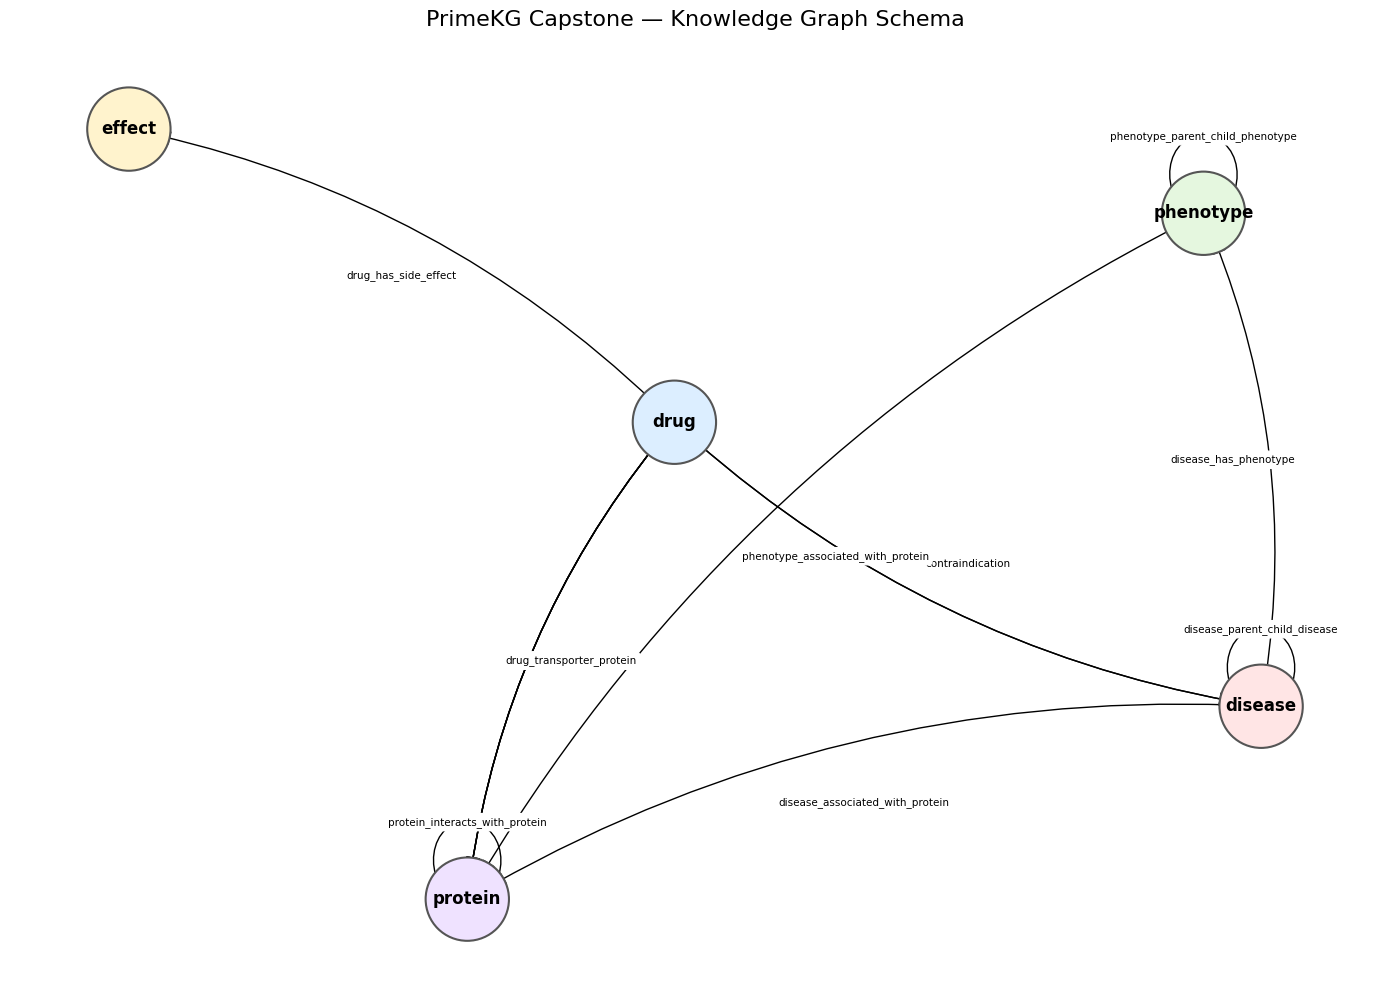

[Fig 1] Schema graph saved -> /mnt/data/fig1_schema_graph.png


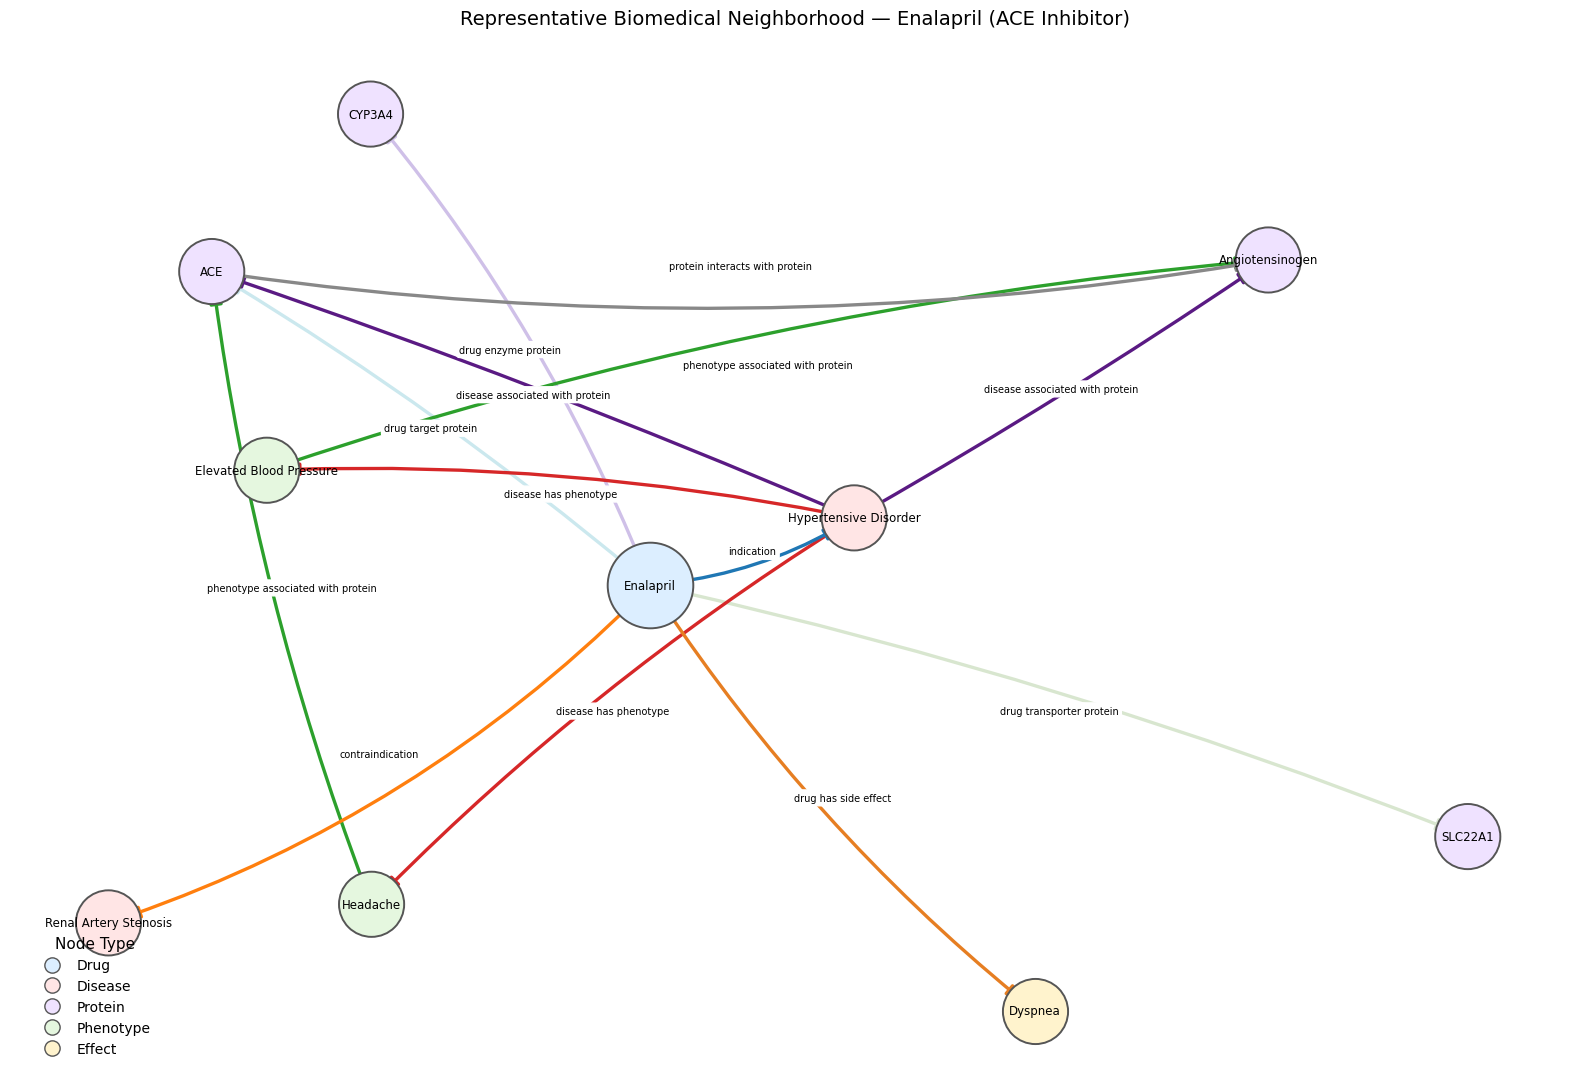

[Fig 2] Sample neighborhood saved -> /mnt/data/fig2_sample_neighborhood.png

[Fig 3] Center disease: hypertension  (disease:1200_1134_15512_5080_100078)
         Subgraph: 624 nodes, 753 edges


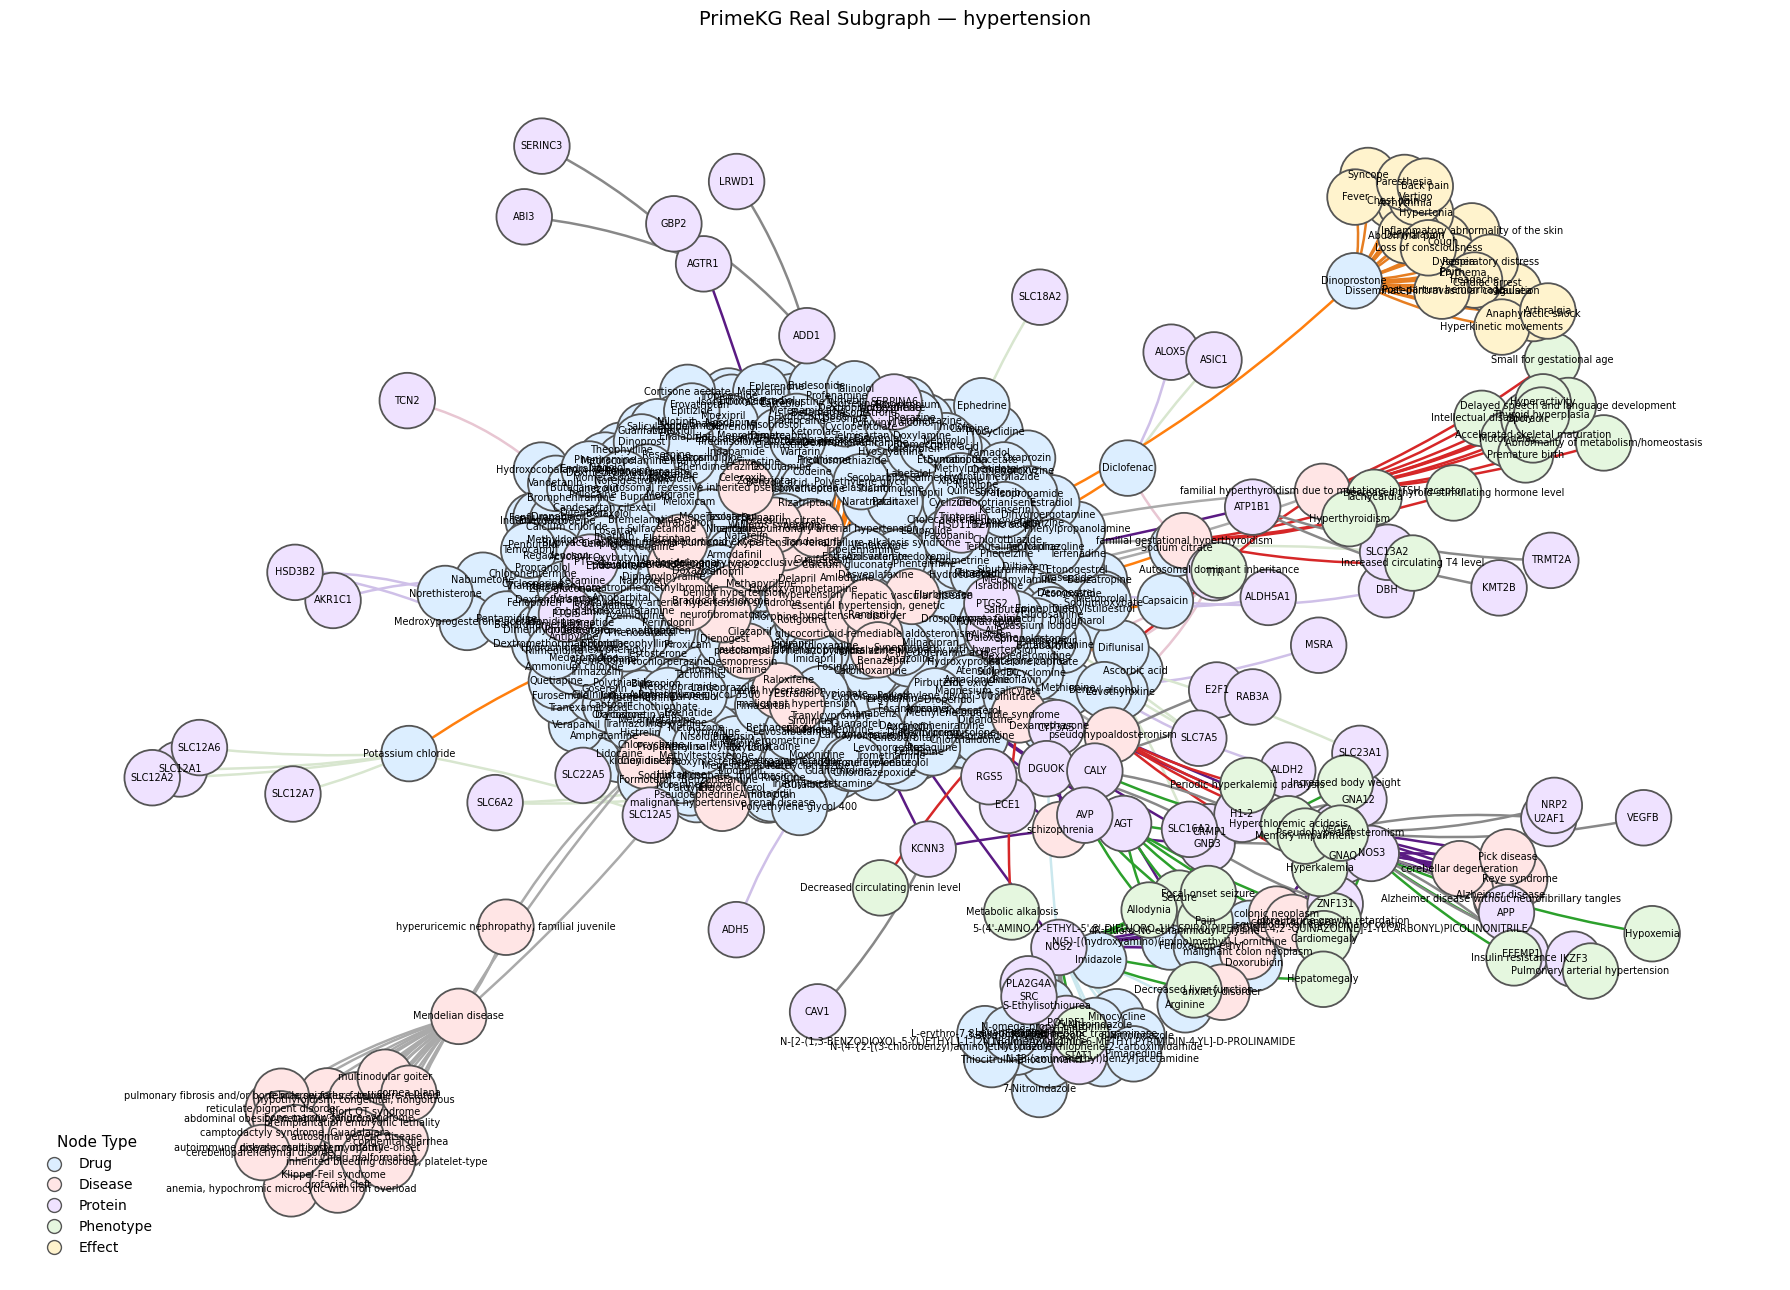

[Fig 3] Disease subgraph saved -> /mnt/data/fig3_subgraph_hypertension.png

[Fig 4] Center drug: Metformin  (drug:DB00331)
  Drug: 1, Proteins: 9, Diseases: 12


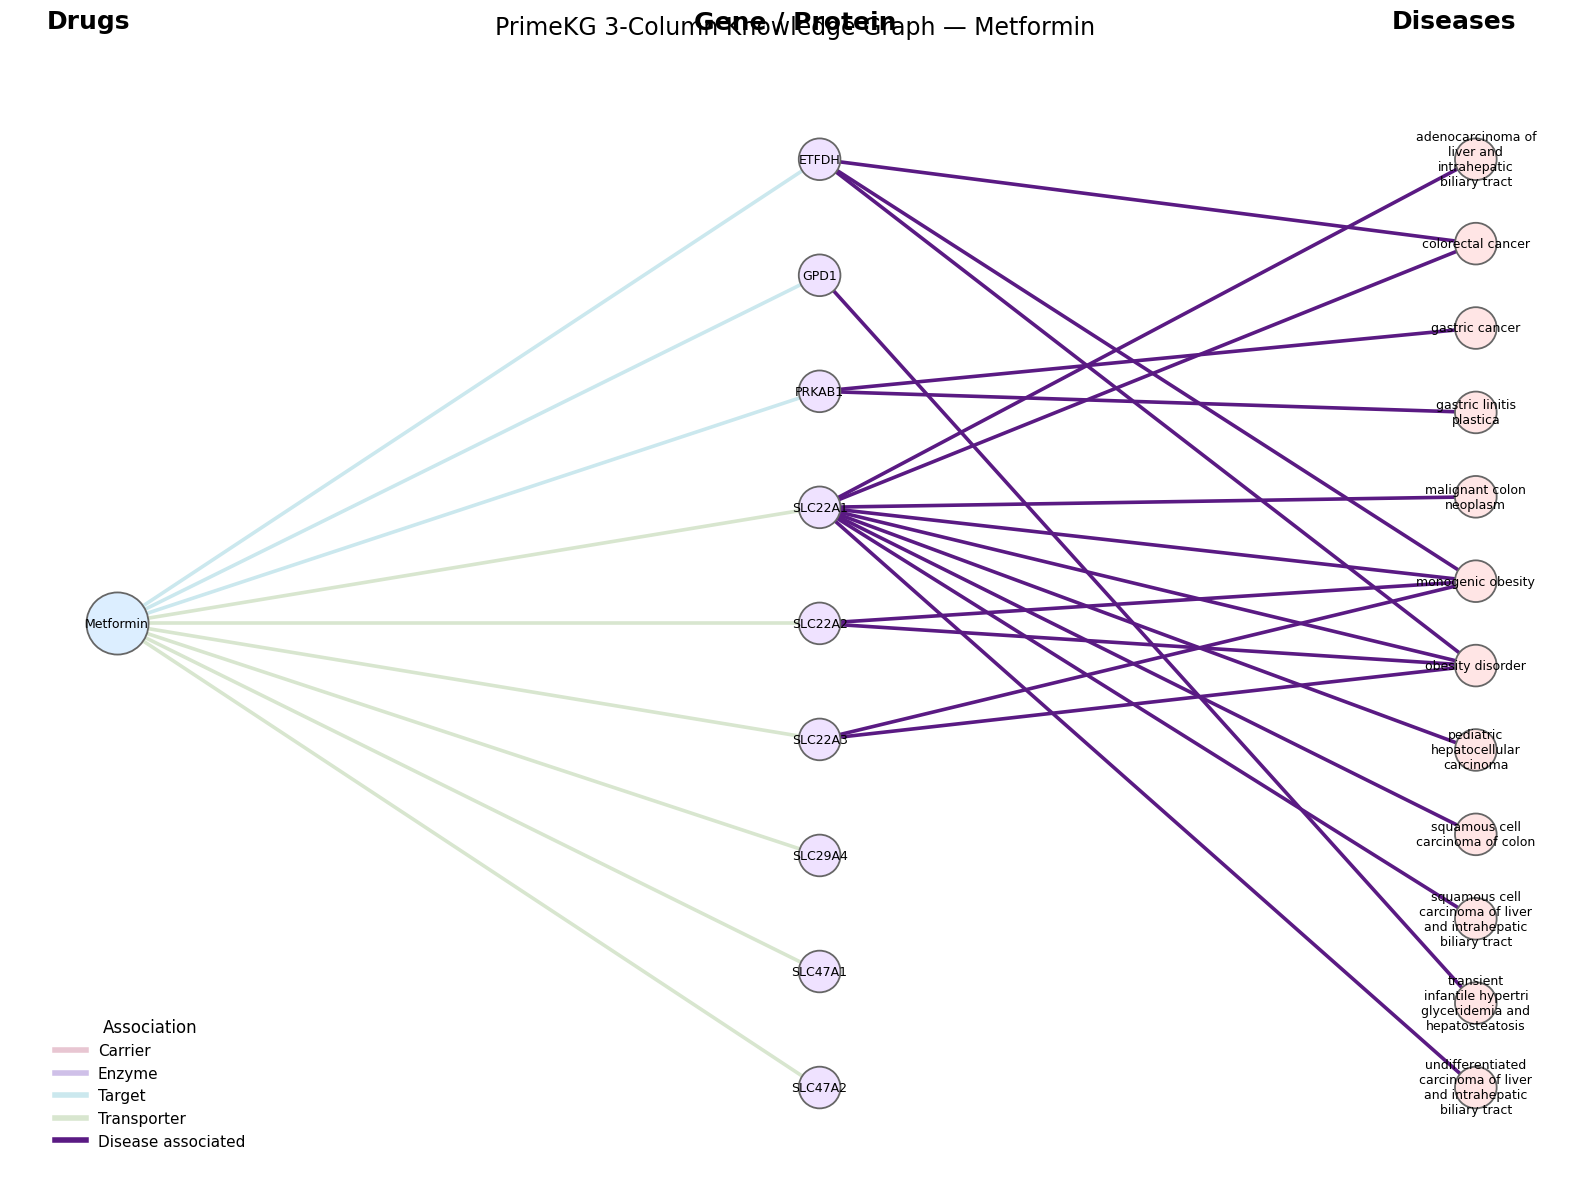

[Fig 4] 3-column KG saved -> /mnt/data/fig4_3column_kg.png

[Fig 5] Center disease: migraine disorder  (disease:5277)
  Drugs: 12, Proteins: 14, Phenotypes: 2, Diseases: 5


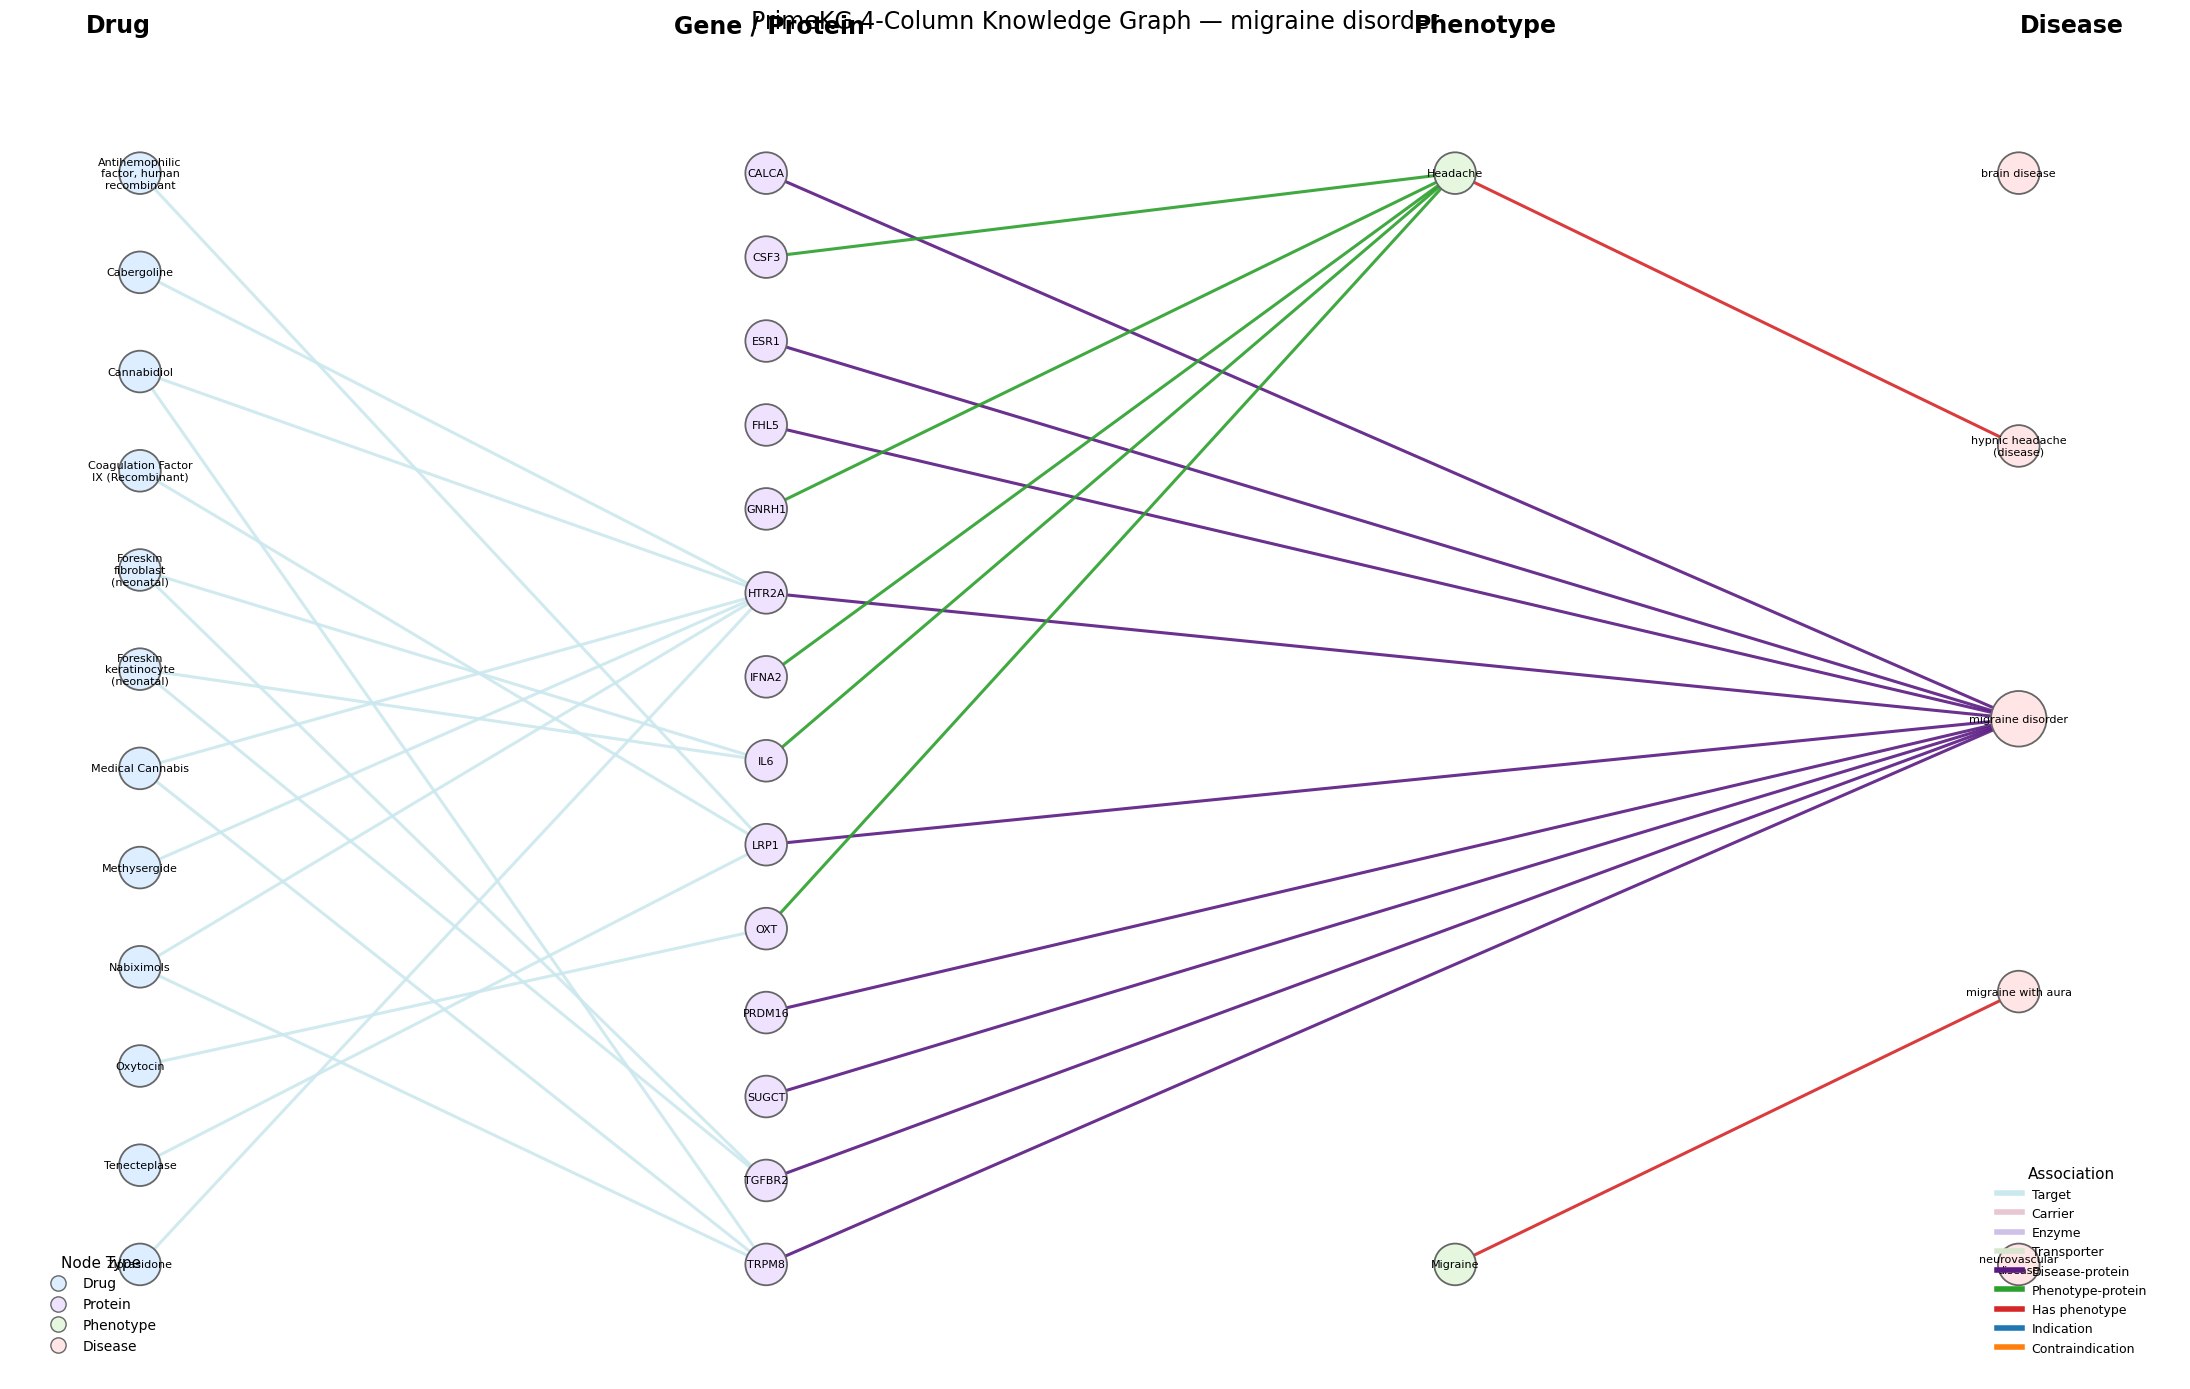

[Fig 5] 4-column KG saved -> /mnt/data/fig5_4column_kg.png

  BLOCK 05 COMPLETE
  Fig 1 : fig1_schema_graph.png  (schema)
  Fig 2 : fig2_sample_neighborhood.png  (sample neighborhood)
  Fig 3 : fig3_subgraph_hypertension.png  (real disease subgraph)
  Fig 4 : fig4_3column_kg.png  (3-column drug KG)
  Fig 5 : fig5_4column_kg.png  (4-column disease KG)


In [5]:
# USER SETTINGS (change these at the top):
#   DISEASE_QUERY : disease name for Fig 3 subgraph
#   CENTER_DRUG   : drug name to center the Fig 4 3-column layout
#   QUERY_4COL    : disease name for Fig 5 4-column layout

assert "canonical_edges_df" in globals(), "Run Block 04 first."
assert "nodes_master_df"    in globals(), "Run Block 04 first."

# Output directory
OUTPUT_DIR = Path("/mnt/data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# User-configurable query strings
DISEASE_QUERY = "hypertension"   # Fig 3: disease-centered real subgraph
CENTER_DRUG   = "Metformin"      # Fig 4: drug for the 3-column layout
QUERY_4COL    = "migraine"       # Fig 5: disease for the 4-column layout


# Shared helpers

def normalize_text(text: str) -> str:
    """Lowercase, strip, replace underscores with spaces."""
    return str(text).lower().strip().replace("_", " ")

def wrap_label(text: str, width: int = 16) -> str:
    """Word-wrap a node label so it fits inside a drawn node circle."""
    return "\n".join(textwrap.wrap(str(text), width=width))

def find_best_node(df: pd.DataFrame, name_col: str, query: str):
    """
    Search df for the best-matching node by name.
    Returns a single pd.Series (the matched row) or None.
    Priority: exact match > contains match, then non-grouped source,
    then shortest name (least ambiguous), then alphabetical.
    """
    q    = normalize_text(query)
    work = df.copy()
    work["_norm"]    = work[name_col].apply(normalize_text)
    work["_len"]     = work[name_col].str.len()
    # Grouped sources are PrimeKG cross-database aggregations;
    work["_grouped"] = work["node_source"].str.contains(
        "grouped", case=False, na=False
    ).astype(int)

    exact    = work[work["_norm"] == q]
    contains = work[work["_norm"].str.contains(q, na=False)]
    pool     = exact if not exact.empty else contains

    if pool.empty:
        return None

    return pool.sort_values(
        ["_grouped", "_len", name_col],
        ascending=[True, True, True],
    ).iloc[0]

def column_positions(
    node_list: list,
    x: float,
    y_top: float = 0.92,
    y_bottom: float = 0.08,
) -> dict:
    """
    Assign evenly-spaced (x, y) positions along a vertical column.
    Used to produce the clean multi-column KG layouts.
    """
    n = len(node_list)
    if n == 0:
        return {}
    if n == 1:
        return {node_list[0]: (x, 0.5)}
    step = (y_top - y_bottom) / (n - 1)
    ys   = list(reversed([y_bottom + i * step for i in range(n)]))
    return {node: (x, y) for node, y in zip(node_list, ys)}

def sorted_by_name(uid_list: list, name_lookup: dict) -> list:
    """Sort a list of UIDs alphabetically by their display names."""
    return sorted(uid_list, key=lambda u: name_lookup.get(u, u))

# Build a UID -> name lookup reused throughout this block
_uid_to_name = dict(
    zip(nodes_master_df["node_uid"], nodes_master_df["node_name"])
)

# Shared color palettes used across all figures
_NODE_COLORS = {
    "drug":      "#dceeff",
    "disease":   "#ffe5e5",
    "protein":   "#efe2ff",
    "phenotype": "#e5f7df",
    "effect":    "#fff3cd",
}
_EDGE_COLORS = {
    "drug_carrier_protein":               "#e8c6d2",
    "drug_enzyme_protein":                "#cfc0e8",
    "drug_target_protein":                "#cbe8ee",
    "drug_transporter_protein":           "#d8e6cf",
    "disease_associated_with_protein":    "#5a1a83",
    "phenotype_associated_with_protein":  "#2ca02c",
    "disease_has_phenotype":              "#d62728",
    "indication":                         "#1f77b4",
    "contraindication":                   "#ff7f0e",
    "protein_interacts_with_protein":     "#888888",
    "disease_parent_child_disease":       "#aaaaaa",
    "drug_has_side_effect":               "#e67e22",
}
_EDGE_CURVATURE = {
    "drug_carrier_protein":               0.12,
    "drug_enzyme_protein":                0.08,
    "drug_target_protein":                0.04,
    "drug_transporter_protein":          -0.04,
    "disease_associated_with_protein":    0.02,
    "phenotype_associated_with_protein": -0.06,
    "disease_has_phenotype":              0.06,
    "indication":                         0.12,
    "contraindication":                  -0.12,
}


# FIG 1 — SCHEMA GRAPH

_SCHEMA_EDGES = [
    ("drug",      "indication",                        "disease"),
    ("drug",      "contraindication",                  "disease"),
    ("drug",      "drug_target_protein",               "protein"),
    ("drug",      "drug_carrier_protein",              "protein"),
    ("drug",      "drug_enzyme_protein",               "protein"),
    ("drug",      "drug_transporter_protein",          "protein"),
    ("drug",      "drug_has_side_effect",              "effect"),
    ("disease",   "disease_associated_with_protein",   "protein"),
    ("disease",   "disease_has_phenotype",             "phenotype"),
    ("disease",   "disease_parent_child_disease",      "disease"),
    ("phenotype", "phenotype_associated_with_protein", "protein"),
    ("phenotype", "phenotype_parent_child_phenotype",  "phenotype"),
    ("protein",   "protein_interacts_with_protein",    "protein"),
]

G_schema = nx.MultiDiGraph()
for src, rel, dst in _SCHEMA_EDGES:
    G_schema.add_edge(src, dst, label=rel)

fig, ax = plt.subplots(figsize=(14, 10))
pos_schema = nx.spring_layout(G_schema, seed=42, k=2.2)

schema_node_colors = [_NODE_COLORS.get(n, "#eeeeee") for n in G_schema.nodes()]
nx.draw_networkx_nodes(G_schema, pos_schema, ax=ax, node_size=3600,
                       node_color=schema_node_colors,
                       edgecolors="#555555", linewidths=1.5)
nx.draw_networkx_labels(G_schema, pos_schema, ax=ax,
                        font_size=12, font_weight="bold")
nx.draw_networkx_edges(G_schema, pos_schema, ax=ax,
                       arrows=True, arrowstyle="-|>", arrowsize=22,
                       connectionstyle="arc3,rad=0.15",
                       min_source_margin=20, min_target_margin=20)
schema_edge_labels = {
    (u, v, k): d["label"]
    for u, v, k, d in G_schema.edges(keys=True, data=True)
}
nx.draw_networkx_edge_labels(G_schema, pos_schema,
                              edge_labels=schema_edge_labels, ax=ax,
                              font_size=7.5, rotate=False)
ax.set_title("PrimeKG Capstone — Knowledge Graph Schema",
             fontsize=16, pad=16)
ax.axis("off")
plt.tight_layout()
fig1_path = OUTPUT_DIR / "fig1_schema_graph.png"
plt.savefig(fig1_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"[Fig 1] Schema graph saved -> {fig1_path}")


# FIG 2 — SAMPLE NEIGHBORHOOD GRAPH

_SAMPLE_NODES = [
    # (uid,                             display_name,               node_type)
    ("drug:DB00457",                   "Enalapril",                "drug"),
    ("disease:hypertensive_disorder",  "Hypertensive Disorder",    "disease"),
    ("disease:renal_artery_stenosis",  "Renal Artery Stenosis",    "disease"),
    ("protein:ACE",                    "ACE",                      "protein"),
    ("protein:AGT",                    "Angiotensinogen",          "protein"),
    ("protein:CYP3A4",                 "CYP3A4",                   "protein"),
    ("protein:SLC22A1",                "SLC22A1",                  "protein"),
    ("phenotype:headache",             "Headache",                 "phenotype"),
    ("phenotype:elevated_bp",          "Elevated Blood Pressure",  "phenotype"),
    ("effect:dyspnea",                 "Dyspnea",                  "effect"),
]

_SAMPLE_EDGES = [
    # (src_uid,                          dst_uid,                            edge_label)
    ("drug:DB00457",                   "disease:hypertensive_disorder",    "indication"),
    ("drug:DB00457",                   "disease:renal_artery_stenosis",    "contraindication"),
    ("drug:DB00457",                   "protein:ACE",                      "drug_target_protein"),
    ("drug:DB00457",                   "protein:CYP3A4",                   "drug_enzyme_protein"),
    ("drug:DB00457",                   "protein:SLC22A1",                  "drug_transporter_protein"),
    ("drug:DB00457",                   "effect:dyspnea",                   "drug_has_side_effect"),
    ("disease:hypertensive_disorder",  "protein:ACE",                      "disease_associated_with_protein"),
    ("disease:hypertensive_disorder",  "protein:AGT",                      "disease_associated_with_protein"),
    ("disease:hypertensive_disorder",  "phenotype:headache",               "disease_has_phenotype"),
    ("disease:hypertensive_disorder",  "phenotype:elevated_bp",            "disease_has_phenotype"),
    ("phenotype:headache",             "protein:ACE",                      "phenotype_associated_with_protein"),
    ("phenotype:elevated_bp",          "protein:AGT",                      "phenotype_associated_with_protein"),
    ("protein:ACE",                    "protein:AGT",                      "protein_interacts_with_protein"),
]

G_sample = nx.MultiDiGraph()
for uid, name, ntype in _SAMPLE_NODES:
    G_sample.add_node(uid, label=name, node_type=ntype,
                      is_center=(uid == "drug:DB00457"))
for src, dst, rel in _SAMPLE_EDGES:
    G_sample.add_edge(src, dst, label=rel)

fig, ax = plt.subplots(figsize=(16, 11))
pos_sample = nx.spring_layout(G_sample, seed=42, k=1.6)

# Draw each node type with its own color
for ntype, color in _NODE_COLORS.items():
    nodelist = [u for u, d in G_sample.nodes(data=True) if d["node_type"] == ntype]
    if not nodelist:
        continue
    sizes = [3800 if G_sample.nodes[u]["is_center"] else 2200 for u in nodelist]
    nx.draw_networkx_nodes(G_sample, pos_sample, ax=ax,
                           nodelist=nodelist, node_size=sizes,
                           node_color=color,
                           edgecolors="#555555", linewidths=1.4)

sample_labels = {u: d["label"] for u, d in G_sample.nodes(data=True)}
nx.draw_networkx_labels(G_sample, pos_sample, labels=sample_labels,
                        ax=ax, font_size=8.5)

# Draw each relation type with its own color and curvature
for rel, color in _EDGE_COLORS.items():
    edgelist = [
        (u, v, k)
        for u, v, k, d in G_sample.edges(keys=True, data=True)
        if d["label"] == rel
    ]
    if not edgelist:
        continue
    rad = _EDGE_CURVATURE.get(rel, 0.08)
    nx.draw_networkx_edges(G_sample, pos_sample, ax=ax,
                           edgelist=edgelist,
                           edge_color=color, width=2.4,
                           arrows=True, arrowstyle="-|>", arrowsize=18,
                           connectionstyle=f"arc3,rad={rad}",
                           min_source_margin=14, min_target_margin=14)

sample_edge_labels = {
    (u, v, k): d["label"].replace("_", " ")
    for u, v, k, d in G_sample.edges(keys=True, data=True)
}
nx.draw_networkx_edge_labels(G_sample, pos_sample,
                              edge_labels=sample_edge_labels, ax=ax,
                              font_size=7, rotate=False)

# Node-type legend
sample_leg = [
    mlines.Line2D([], [], color="none", marker="o", markersize=11,
                  markerfacecolor=_NODE_COLORS[t],
                  markeredgecolor="#555555", label=t.capitalize())
    for t in ["drug", "disease", "protein", "phenotype", "effect"]
]
ax.legend(handles=sample_leg, title="Node Type", loc="lower left",
          bbox_to_anchor=(0.01, 0.01), frameon=False,
          fontsize=10, title_fontsize=11)

ax.set_title(
    "Representative Biomedical Neighborhood — Enalapril (ACE Inhibitor)",
    fontsize=14, pad=14)
ax.axis("off")
plt.tight_layout()
fig2_path = OUTPUT_DIR / "fig2_sample_neighborhood.png"
plt.savefig(fig2_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"[Fig 2] Sample neighborhood saved -> {fig2_path}")


# FIG 3 — DISEASE-CENTERED REAL SUBGRAPH

MAX_EDGES_PER_LABEL = 25   # cap per relation type

disease3_all = nodes_master_df[nodes_master_df["node_type"] == "disease"].copy()
picked3 = find_best_node(disease3_all, "node_name", DISEASE_QUERY)
if picked3 is None:
    raise ValueError(
        f"No disease found matching '{DISEASE_QUERY}'. "
        "Check the DISEASE_QUERY setting at the top of this block."
    )

center3_uid  = picked3["node_uid"]
center3_name = picked3["node_name"]
print(f"\n[Fig 3] Center disease: {center3_name}  ({center3_uid})")

# 1-hop: every edge that directly touches the center disease
hop1 = canonical_edges_df[
    (canonical_edges_df["src_uid"] == center3_uid) |
    (canonical_edges_df["dst_uid"] == center3_uid)
].copy()
hop1_nodes = set(hop1["src_uid"]) | set(hop1["dst_uid"]) | {center3_uid}

# 2-hop: thin expansion, capped per relation type to avoid visual clutter
hop2 = canonical_edges_df[
    canonical_edges_df["src_uid"].isin(hop1_nodes) |
    canonical_edges_df["dst_uid"].isin(hop1_nodes)
].copy()
hop2 = hop2.groupby("edge_label", group_keys=False).head(MAX_EDGES_PER_LABEL)

plot3_edges = (
    pd.concat([hop1, hop2], ignore_index=True)
    .drop_duplicates(subset=["edge_label", "src_uid", "dst_uid"])
)
plot3_node_uids = set(plot3_edges["src_uid"]) | set(plot3_edges["dst_uid"])
plot3_nodes = nodes_master_df[nodes_master_df["node_uid"].isin(plot3_node_uids)]

print(f"         Subgraph: {len(plot3_nodes):,} nodes, {len(plot3_edges):,} edges")

G3 = nx.MultiDiGraph()
for _, row in plot3_nodes.iterrows():
    G3.add_node(row["node_uid"],
                label=row["node_name"],
                node_type=row["node_type"],
                is_center=(row["node_uid"] == center3_uid))
for _, row in plot3_edges.iterrows():
    G3.add_edge(row["src_uid"], row["dst_uid"], label=row["edge_label"])

fig, ax = plt.subplots(figsize=(18, 13))
pos3 = nx.spring_layout(G3, seed=42, k=1.3)

# Center disease node is larger so it stands out
for ntype, color in _NODE_COLORS.items():
    nl = [u for u, d in G3.nodes(data=True) if d["node_type"] == ntype]
    if not nl:
        continue
    sizes = [4200 if G3.nodes[u]["is_center"] else 1600 for u in nl]
    nx.draw_networkx_nodes(G3, pos3, ax=ax, nodelist=nl,
                           node_size=sizes, node_color=color,
                           edgecolors="#555555", linewidths=1.3)

labels3 = {u: d["label"] for u, d in G3.nodes(data=True)}
nx.draw_networkx_labels(G3, pos3, labels=labels3, ax=ax, font_size=7)

for rel, color in _EDGE_COLORS.items():
    el3 = [(u, v, k) for u, v, k, d in G3.edges(keys=True, data=True)
           if d["label"] == rel]
    if el3:
        rad = _EDGE_CURVATURE.get(rel, 0.08)
        nx.draw_networkx_edges(G3, pos3, ax=ax, edgelist=el3,
                               edge_color=color, width=1.8,
                               arrows=True, arrowstyle="-|>", arrowsize=14,
                               connectionstyle=f"arc3,rad={rad}",
                               min_source_margin=10, min_target_margin=10)

leg3 = [
    mlines.Line2D([], [], color="none", marker="o", markersize=10,
                  markerfacecolor=_NODE_COLORS.get(t, "#eeeeee"),
                  markeredgecolor="#555555", label=t.capitalize())
    for t in ["drug", "disease", "protein", "phenotype", "effect"]
]
ax.legend(handles=leg3, title="Node Type", loc="lower left",
          bbox_to_anchor=(0.01, 0.01), frameon=False,
          fontsize=10, title_fontsize=11)

ax.set_title(f"PrimeKG Real Subgraph — {center3_name}", fontsize=14, pad=14)
ax.axis("off")
plt.tight_layout()
fig3_safe = normalize_text(center3_name).replace(" ", "_")
fig3_path = OUTPUT_DIR / f"fig3_subgraph_{fig3_safe}.png"
plt.savefig(fig3_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"[Fig 3] Disease subgraph saved -> {fig3_path}")


# FIG 4 — 3-COLUMN KG  (Drug | Gene/Protein | Disease)

MAX_PROTEINS_3COL = 20
MAX_DISEASES_3COL = 12

# Locate the center drug in the processed node table
drug3_all = nodes_master_df[nodes_master_df["node_type"] == "drug"].copy()
picked4 = find_best_node(drug3_all, "node_name", CENTER_DRUG)
if picked4 is None:
    raise ValueError(
        f"No drug found matching '{CENTER_DRUG}'. "
        "Change CENTER_DRUG at the top of this block."
    )

center4_uid  = picked4["node_uid"]
center4_name = picked4["node_name"]
print(f"\n[Fig 4] Center drug: {center4_name}  ({center4_uid})")

e = canonical_edges_df

# Drug -> protein edges (all four subtypes)
_DRUG_PROT_LABELS = {
    "drug_carrier_protein", "drug_enzyme_protein",
    "drug_target_protein",  "drug_transporter_protein",
}
drug_prot4 = e[
    e["edge_label"].isin(_DRUG_PROT_LABELS) &
    (e["src_uid"] == center4_uid)
].copy()

if drug_prot4.empty:
    raise ValueError(
        f"No drug-protein edges found for '{center4_name}'. "
        "Try a different drug name in CENTER_DRUG."
    )

# Keep the most-connected proteins (highest edge count)
top4_proteins = (
    drug_prot4.groupby("dst_uid").size()
    .nlargest(MAX_PROTEINS_3COL).index.tolist()
)
drug_prot4 = drug_prot4[drug_prot4["dst_uid"].isin(top4_proteins)]

# Disease-protein edges for those proteins (drawn protein->disease, left to right)
dis_prot4 = e[
    (e["edge_label"] == "disease_associated_with_protein") &
    e["dst_uid"].isin(top4_proteins)
].copy()
top4_diseases = (
    dis_prot4.groupby("src_uid").size()
    .nlargest(MAX_DISEASES_3COL).index.tolist()
)
dis_prot4 = dis_prot4[dis_prot4["src_uid"].isin(top4_diseases)]

# Node tables
drug4_nodes    = nodes_master_df[nodes_master_df["node_uid"] == center4_uid]
prot4_nodes    = nodes_master_df[nodes_master_df["node_uid"].isin(top4_proteins)]
disease4_nodes = nodes_master_df[nodes_master_df["node_uid"].isin(top4_diseases)]

print(f"  Drug: 1, Proteins: {len(prot4_nodes)}, Diseases: {len(disease4_nodes)}")

# Build graph
G4 = nx.MultiDiGraph()

for _, row in drug4_nodes.iterrows():
    G4.add_node(row["node_uid"],
                label=wrap_label(row["node_name"], 18),
                node_type="drug", is_center=True)
for _, row in prot4_nodes.iterrows():
    G4.add_node(row["node_uid"],
                label=wrap_label(row["node_name"], 18),
                node_type="protein", is_center=False)
for _, row in disease4_nodes.iterrows():
    G4.add_node(row["node_uid"],
                label=wrap_label(row["node_name"], 18),
                node_type="disease", is_center=False)

for _, row in drug_prot4.iterrows():
    G4.add_edge(row["src_uid"], row["dst_uid"], edge_label=row["edge_label"])

# Disease-protein edges are drawn protein->disease so they flow left to right
for _, row in dis_prot4.iterrows():
    G4.add_edge(row["dst_uid"], row["src_uid"],
                edge_label=row["edge_label"])

# Three-column layout
pos4 = {}
pos4.update(column_positions([center4_uid],                            x=0.05))
pos4.update(column_positions(sorted_by_name(top4_proteins, _uid_to_name), x=0.50))
pos4.update(column_positions(sorted_by_name(top4_diseases, _uid_to_name), x=0.92))

_3COL_EDGE_COLORS = {
    "drug_carrier_protein":            "#e8c6d2",
    "drug_enzyme_protein":             "#cfc0e8",
    "drug_target_protein":             "#cbe8ee",
    "drug_transporter_protein":        "#d8e6cf",
    "disease_associated_with_protein": "#5a1a83",
}
_3COL_EDGE_LABELS = {
    "drug_carrier_protein":            "Carrier",
    "drug_enzyme_protein":             "Enzyme",
    "drug_target_protein":             "Target",
    "drug_transporter_protein":        "Transporter",
    "disease_associated_with_protein": "Disease associated",
}

fig, ax = plt.subplots(figsize=(16, 12))

for ntype, nodelist in [
    ("drug",    [center4_uid]),
    ("protein", top4_proteins),
    ("disease", top4_diseases),
]:
    valid = [u for u in nodelist if u in pos4]
    sizes = [2000 if G4.nodes[u].get("is_center") else 900 for u in valid]
    nx.draw_networkx_nodes(G4, pos4, ax=ax,
                           nodelist=valid, node_size=sizes,
                           node_color=_NODE_COLORS[ntype],
                           edgecolors="#666666", linewidths=1.3)

labels4 = {u: G4.nodes[u]["label"] for u in G4.nodes() if u in pos4}
nx.draw_networkx_labels(G4, pos4, labels=labels4, ax=ax, font_size=9)

for rel, color in _3COL_EDGE_COLORS.items():
    el4 = [
        (u, v, k)
        for u, v, k, d in G4.edges(keys=True, data=True)
        if d["edge_label"] == rel and u in pos4 and v in pos4
    ]
    if el4:
        nx.draw_networkx_edges(G4, pos4, ax=ax, edgelist=el4,
                               edge_color=color, width=2.6,
                               arrows=False, connectionstyle="arc3,rad=0.0")

# Column headers
for x_frac, header in [
    (0.05, "Drugs"), (0.50, "Gene / Protein"), (0.92, "Diseases")
]:
    ax.text(x_frac, 1.03, header, fontsize=18, fontweight="bold",
            ha="center", transform=ax.transAxes)

leg4 = [
    mlines.Line2D([], [], color=_3COL_EDGE_COLORS[rel], linewidth=4,
                  label=_3COL_EDGE_LABELS[rel])
    for rel in _3COL_EDGE_COLORS
]
ax.legend(handles=leg4, title="Association",
          loc="lower left", bbox_to_anchor=(0.02, 0.02),
          frameon=False, fontsize=11, title_fontsize=12)

ax.set_title(f"PrimeKG 3-Column Knowledge Graph — {center4_name}",
             fontsize=17, pad=20)
ax.axis("off")
plt.tight_layout()
fig4_path = OUTPUT_DIR / "fig4_3column_kg.png"
plt.savefig(fig4_path, dpi=250, bbox_inches="tight")
plt.show()
print(f"[Fig 4] 3-column KG saved -> {fig4_path}")


# FIG 5 — 4-COLUMN KG  (Drug | Gene/Protein | Phenotype | Disease)

MAX_DISEASES_4COL   = 8
MAX_PHENOTYPES_4COL = 10
MAX_PROTEINS_4COL   = 18
MAX_DRUGS_4COL      = 12
INCLUDE_CONTRA      = True

# Find center disease
disease5_all = nodes_master_df[nodes_master_df["node_type"] == "disease"].copy()
picked5 = find_best_node(disease5_all, "node_name", QUERY_4COL)
if picked5 is None:
    raise ValueError(
        f"No disease found matching '{QUERY_4COL}'. "
        "Change QUERY_4COL at the top of this block."
    )

center5_uid  = picked5["node_uid"]
center5_name = picked5["node_name"]
print(f"\n[Fig 5] Center disease: {center5_name}  ({center5_uid})")

e = canonical_edges_df

# Nearby diseases via ontology hierarchy edges
dd5 = e[
    (e["edge_label"] == "disease_parent_child_disease") &
    ((e["src_uid"] == center5_uid) | (e["dst_uid"] == center5_uid))
]
nearby5 = {center5_uid} | set(dd5["src_uid"]) | set(dd5["dst_uid"])
if len(nearby5) > MAX_DISEASES_4COL:
    others5 = [u for u in nearby5 if u != center5_uid][:MAX_DISEASES_4COL - 1]
    nearby5 = {center5_uid} | set(others5)

# Disease -> phenotypes
dis_phen5 = e[
    (e["edge_label"] == "disease_has_phenotype") &
    e["src_uid"].isin(nearby5)
]
top5_phenotypes = (
    dis_phen5.groupby("dst_uid").size()
    .nlargest(MAX_PHENOTYPES_4COL).index.tolist()
)
dis_phen5 = dis_phen5[dis_phen5["dst_uid"].isin(top5_phenotypes)]

# Disease + phenotype -> proteins (union, ranked by total connectivity)
dis_prot5  = e[
    (e["edge_label"] == "disease_associated_with_protein") &
    e["src_uid"].isin(nearby5)
]
phen_prot5 = e[
    (e["edge_label"] == "phenotype_associated_with_protein") &
    e["src_uid"].isin(top5_phenotypes)
]
prot5_counts = pd.concat([
    dis_prot5[["dst_uid"]], phen_prot5[["dst_uid"]]
])["dst_uid"].value_counts()
top5_proteins = prot5_counts.head(MAX_PROTEINS_4COL).index.tolist()
dis_prot5  = dis_prot5[dis_prot5["dst_uid"].isin(top5_proteins)]
phen_prot5 = phen_prot5[phen_prot5["dst_uid"].isin(top5_proteins)]

# Proteins -> drugs (top drugs by protein connectivity)
_DRUG_PROT5 = {
    "drug_carrier_protein", "drug_enzyme_protein",
    "drug_target_protein",  "drug_transporter_protein",
}
drug_prot5 = e[e["edge_label"].isin(_DRUG_PROT5) & e["dst_uid"].isin(top5_proteins)]
top5_drugs = (
    drug_prot5.groupby("src_uid").size()
    .nlargest(MAX_DRUGS_4COL).index.tolist()
)
drug_prot5 = drug_prot5[drug_prot5["src_uid"].isin(top5_drugs)]

# Drug-disease indication / contraindication overlays
ind5_labels = ["indication"] + (["contraindication"] if INCLUDE_CONTRA else [])
drug_disease5 = e[
    e["edge_label"].isin(ind5_labels) &
    e["src_uid"].isin(top5_drugs) &
    e["dst_uid"].isin(nearby5)
]

# Node tables
get5 = lambda uids: nodes_master_df[nodes_master_df["node_uid"].isin(uids)]
drug5_nodes    = get5(top5_drugs)
prot5_nodes    = get5(top5_proteins)
phen5_nodes    = get5(top5_phenotypes)
disease5_nodes = get5(nearby5)

print(f"  Drugs: {len(drug5_nodes)}, Proteins: {len(prot5_nodes)}, "
      f"Phenotypes: {len(phen5_nodes)}, Diseases: {len(disease5_nodes)}")

# Build graph
G5 = nx.MultiDiGraph()

def _add5(df, ntype):
    for _, row in df.iterrows():
        G5.add_node(row["node_uid"],
                    label=wrap_label(row["node_name"], 18),
                    node_type=ntype,
                    is_center=(row["node_uid"] == center5_uid))

_add5(drug5_nodes,    "drug")
_add5(prot5_nodes,    "protein")
_add5(phen5_nodes,    "phenotype")
_add5(disease5_nodes, "disease")

def _addedge5(df):
    for _, row in df.iterrows():
        G5.add_edge(row["src_uid"], row["dst_uid"],
                    edge_label=row["edge_label"],
                    color=_EDGE_COLORS.get(row["edge_label"], "#999999"),
                    rad=_EDGE_CURVATURE.get(row["edge_label"], 0.0))

_addedge5(drug_prot5)
_addedge5(dis_prot5)
_addedge5(phen_prot5)
_addedge5(dis_phen5)
_addedge5(drug_disease5)

# Four-column layout
pos5 = {}
pos5.update(column_positions(sorted_by_name(top5_drugs,       _uid_to_name), x=0.05))
pos5.update(column_positions(sorted_by_name(top5_proteins,    _uid_to_name), x=0.35))
pos5.update(column_positions(sorted_by_name(top5_phenotypes,  _uid_to_name), x=0.68))
pos5.update(column_positions(sorted_by_name(list(nearby5),    _uid_to_name), x=0.95))

fig, ax = plt.subplots(figsize=(22, 14))

for ntype, uids in [
    ("drug",      top5_drugs),
    ("protein",   top5_proteins),
    ("phenotype", top5_phenotypes),
    ("disease",   list(nearby5)),
]:
    valid = [u for u in uids if u in pos5]
    sizes = [1600 if G5.nodes.get(u, {}).get("is_center") else 900 for u in valid]
    nx.draw_networkx_nodes(G5, pos5, ax=ax,
                           nodelist=valid, node_size=sizes,
                           node_color=_NODE_COLORS[ntype],
                           edgecolors="#666666", linewidths=1.3)

labels5 = {u: G5.nodes[u]["label"] for u in G5.nodes() if u in pos5}
nx.draw_networkx_labels(G5, pos5, labels=labels5, ax=ax, font_size=8)

for el5, col5 in _EDGE_COLORS.items():
    edgelist5 = [
        (u, v, k)
        for u, v, k, d in G5.edges(keys=True, data=True)
        if d["edge_label"] == el5 and u in pos5 and v in pos5
    ]
    if edgelist5:
        rad5 = _EDGE_CURVATURE.get(el5, 0.0)
        nx.draw_networkx_edges(G5, pos5, ax=ax, edgelist=edgelist5,
                               edge_color=col5, width=2.2,
                               arrows=False,
                               connectionstyle=f"arc3,rad={rad5}", alpha=0.9)

# Column headers
for x_frac, header in [
    (0.05, "Drug"), (0.35, "Gene / Protein"),
    (0.68, "Phenotype"), (0.95, "Disease")
]:
    ax.text(x_frac, 1.02, header, fontsize=17, fontweight="bold",
            ha="center", transform=ax.transAxes)

# Legends
node5_leg = [
    mlines.Line2D([], [], color="none", marker="o", markersize=11,
                  markerfacecolor=_NODE_COLORS[t],
                  markeredgecolor="#666666", label=t.capitalize())
    for t in ["drug", "protein", "phenotype", "disease"]
]
_EDGE5_LEG = [
    ("drug_target_protein",              "Target"),
    ("drug_carrier_protein",             "Carrier"),
    ("drug_enzyme_protein",              "Enzyme"),
    ("drug_transporter_protein",         "Transporter"),
    ("disease_associated_with_protein",  "Disease-protein"),
    ("phenotype_associated_with_protein","Phenotype-protein"),
    ("disease_has_phenotype",            "Has phenotype"),
    ("indication",                       "Indication"),
]
if INCLUDE_CONTRA:
    _EDGE5_LEG.append(("contraindication", "Contraindication"))

edge5_leg = [
    mlines.Line2D([], [], color=_EDGE_COLORS[rel], linewidth=4, label=lbl)
    for rel, lbl in _EDGE5_LEG
]

leg5a = ax.legend(handles=node5_leg, title="Node Type",
                  loc="lower left", bbox_to_anchor=(0.01, 0.01),
                  frameon=False, fontsize=10, title_fontsize=11)
ax.add_artist(leg5a)
ax.legend(handles=edge5_leg, title="Association",
          loc="lower right", bbox_to_anchor=(0.99, 0.01),
          frameon=False, fontsize=9, title_fontsize=11)

ax.set_title(f"PrimeKG 4-Column Knowledge Graph — {center5_name}",
             fontsize=17, pad=22)
ax.axis("off")
plt.tight_layout()
fig5_path = OUTPUT_DIR / "fig5_4column_kg.png"
plt.savefig(fig5_path, dpi=250, bbox_inches="tight")
plt.show()
print(f"[Fig 5] 4-column KG saved -> {fig5_path}")


#Summary
print()
print("=" * 55)
print("  BLOCK 05 COMPLETE")
print("=" * 55)
print(f"  Fig 1 : {fig1_path.name}  (schema)")
print(f"  Fig 2 : {fig2_path.name}  (sample neighborhood)")
print(f"  Fig 3 : {fig3_path.name}  (real disease subgraph)")
print(f"  Fig 4 : {fig4_path.name}  (3-column drug KG)")
print(f"  Fig 5 : {fig5_path.name}  (4-column disease KG)")
print("=" * 55)

## 6. Create the train/validation/test split

This block prepares the graph for the supervised drug repurposing task. The next step is to define exactly what the model should learn, split the target edges into training and evaluation sets, generate negative examples for validation and testing, and package everything into a PyTorch Geometric `HeteroData` object.

### A. Separate target edges from context edges

The block begins by copying `edges_model_ready_df` and splitting it into two parts:

- **target edges**: the edges the model is asked to predict  
- **context edges**: all other edge types that remain in the graph as supporting structure

Here, the target relation is set to:

- `TARGET_EDGE_TRIPLET = ("drug", "indication", "disease")`
- `TARGET_EDGE_LABEL = "indication"`

This means the model is specifically learning to predict whether a **drug** should connect to a **disease** through the **indication** edge type.

The code then checks that all retained indication edges really follow the expected direction of **drug → disease**. This is an important sanity check, because any leftover direction inconsistency would affect both training and evaluation.

After that, the target edges are deduplicated using the `(drug, disease)` pair. This ensures that the same therapeutic link is not counted multiple times in the supervision set.

### B. Split the target edges into train, validation, and test sets

Once the target edges are isolated, the block divides them into three splits:

- **70% training**
- **15% validation**
- **15% test**

The block also checks for leakage by making sure that no `(drug, disease)` pair appears in more than one split. This matters because if the same positive pair were present in both training and evaluation, model performance would be overstated.

### C. Generate negative drug–disease pairs

Link prediction requires both positive and negative examples. The positive examples are the known indication edges from PrimeKG, but the model also needs examples of drug–disease pairs that are **not** known indications.

To do this, the block defines a helper function called `sample_negatives(...)`. This function randomly samples drug–disease index pairs while avoiding any pair that already exists as a known positive indication edge.

A few important details about this step:

- the sampler works over the full range of drug indices and disease indices
- it rejects any sampled pair that is already a known positive
- it also avoids duplicate negative pairs
- it uses a seeded random generator so results are reproducible

The full set of positive indication pairs across all splits is collected into `all_positive_pairs`. This prevents the negative sampler from accidentally drawing a real therapeutic edge.

In this notebook, negative samples are generated for:
- **validation**
- **test**

The evaluation is balanced using:

- `NEG_RATIO = 1`

### D. Build the supervision tensors

After the splits are created, the block converts each supervision dataframe into PyTorch tensors using the helper function `df_to_edge_index(...)`.

Each tensor has shape:

`[2, number_of_edges]`

where:
- the first row contains source node indices
- the second row contains destination node indices

The resulting tensors are:

- `train_pos_edge_label_index`
- `val_pos_edge_label_index`
- `test_pos_edge_label_index`

along with the pre-sampled evaluation negatives:

- `val_neg_edge_label_index`
- `test_neg_edge_label_index`

### E. Build the PyTorch Geometric `HeteroData` object

The final part of the block constructs `train_data`, a PyTorch Geometric `HeteroData` object that stores the heterogeneous graph used during training.

#### Node setup

For each node type, the block stores only:

- `num_nodes`

It intentionally does **not** assign explicit node feature vectors (`.x`) at this stage.

The notebook avoids creating artificial scalar features like node indices, because doing so would impose an arbitrary numeric structure that does not meaningfully represent the biomedical entities.

#### Edge setup

The graph is then built from:
- **all context edges**
- **only the training indication edges**

So the training graph contains:
- every non-target biomedical relation as full context
- only the train portion of the `indication` edges

In [6]:
# Train / Val / Test Split + PyG HeteroData

assert "edges_model_ready_df" in globals(), "Run Block 04 first."
assert "num_nodes_dict"        in globals(), "Run Block 04 first."
assert "device"                in globals(), "Run Block 01 first."

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# The edge type we are predicting
TARGET_EDGE_TRIPLET = ("drug", "indication", "disease")  # PyG-style triplet key
TARGET_EDGE_LABEL   = "indication"

# Split ratios
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, "Ratios must sum to 1."

# Negative sampling config
NEG_RATIO = 1


# A. separate target vs context edges

split_df    = edges_model_ready_df.copy()
target_df   = split_df[split_df["edge_label"] == TARGET_EDGE_LABEL].copy()
context_df  = split_df[split_df["edge_label"] != TARGET_EDGE_LABEL].copy()

# Confirm all target edges are drug → disease
bad_target = target_df[
    (target_df["src_type"] != "drug") | (target_df["dst_type"] != "disease")
]
if not bad_target.empty:
    raise ValueError(f"Non-drug→disease rows inside indication edges:\n{bad_target.head()}")

# Deduplicate target edges on the (drug, disease) pair
target_df = target_df.drop_duplicates(subset=["src_uid", "dst_uid"]).copy()
target_df.reset_index(drop=True, inplace=True)

print("=" * 55)
print("  EDGE SPLIT OVERVIEW")
print("=" * 55)
print(f"  Target edges ({TARGET_EDGE_LABEL}) : {len(target_df):,}")
print(f"  Context edges                       : {len(context_df):,}")


# B. train / val / test split on target edges

# First split: train vs (val + test)
train_df, temp_df = train_test_split(
    target_df, test_size=(1.0 - TRAIN_RATIO),
    random_state=RANDOM_STATE, shuffle=True,
)

# Second split: val vs test
val_relative = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
val_df, test_df = train_test_split(
    temp_df, test_size=(1.0 - val_relative),
    random_state=RANDOM_STATE, shuffle=True,
)

# Tag each split for traceability
train_df = train_df.copy(); train_df["split"] = "train"
val_df   = val_df.copy();   val_df["split"]   = "val"
test_df  = test_df.copy();  test_df["split"]  = "test"

# Full target split table (useful for leakage checks and evidence extraction)
target_split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Verify no pair appears in two splits
train_pairs = set(zip(train_df["src_uid"], train_df["dst_uid"]))
val_pairs   = set(zip(val_df["src_uid"],   val_df["dst_uid"]))
test_pairs  = set(zip(test_df["src_uid"],  test_df["dst_uid"]))
assert len(train_pairs & val_pairs)  == 0, "Train/val leakage!"
assert len(train_pairs & test_pairs) == 0, "Train/test leakage!"
assert len(val_pairs   & test_pairs) == 0, "Val/test leakage!"

print(f"\n  Train indication edges : {len(train_df):,}")
print(f"  Val   indication edges : {len(val_df):,}")
print(f"  Test  indication edges : {len(test_df):,}")


# C. negative sampler

def sample_negatives(
    num_src:    int,
    num_dst:    int,
    forbidden:  set,
    n_samples:  int,
    seed:       int = 42,
) -> torch.Tensor:
    """
    Sample n_samples drug–disease pairs that are NOT in forbidden.

    Uses vectorized batch sampling with rejection for efficiency:
      - Draw 3×n candidates at once (oversample)
      - Filter out forbidden pairs
      - Repeat until we have enough

    Returns LongTensor of shape [2, n_samples].
    """
    rng = np.random.default_rng(seed)
    collected = set()

    while len(collected) < n_samples:
        need  = n_samples - len(collected)
        srcs  = rng.integers(0, num_src, need * 3).tolist()
        dsts  = rng.integers(0, num_dst, need * 3).tolist()
        for s, d in zip(srcs, dsts):
            pair = (s, d)
            if pair not in forbidden and pair not in collected:
                collected.add(pair)
                if len(collected) >= n_samples:
                    break

    pairs = list(collected)
    return torch.tensor(pairs, dtype=torch.long).t().contiguous()


# Build the full set of known positives
all_positive_pairs = set(
    zip(target_split_df["src_index"].tolist(),
        target_split_df["dst_index"].tolist())
)

num_drugs    = num_nodes_dict["drug"]
num_diseases = num_nodes_dict["disease"]


# D. build supervision tensors

def df_to_edge_index(df: pd.DataFrame) -> torch.Tensor:
    """Convert a split DataFrame to a LongTensor of shape [2, E]."""
    if df.empty:
        return torch.empty((2, 0), dtype=torch.long)
    arr = df[["src_index", "dst_index"]].to_numpy().T
    return torch.tensor(arr, dtype=torch.long)

train_pos_edge_label_index = df_to_edge_index(train_df)
val_pos_edge_label_index   = df_to_edge_index(val_df)
test_pos_edge_label_index  = df_to_edge_index(test_df)

# Pre-sample val and test negatives
val_neg_edge_label_index = sample_negatives(
    num_src=num_drugs, num_dst=num_diseases,
    forbidden=all_positive_pairs,
    n_samples=val_pos_edge_label_index.size(1) * NEG_RATIO,
    seed=RANDOM_STATE,
)
test_neg_edge_label_index = sample_negatives(
    num_src=num_drugs, num_dst=num_diseases,
    forbidden=all_positive_pairs,
    n_samples=test_pos_edge_label_index.size(1) * NEG_RATIO,
    seed=RANDOM_STATE + 1,
)

print(f"\n  Supervision tensor shapes:")
print(f"    train_pos : {tuple(train_pos_edge_label_index.shape)}")
print(f"    val_pos   : {tuple(val_pos_edge_label_index.shape)}")
print(f"    val_neg   : {tuple(val_neg_edge_label_index.shape)}")
print(f"    test_pos  : {tuple(test_pos_edge_label_index.shape)}")
print(f"    test_neg  : {tuple(test_neg_edge_label_index.shape)}")



# E. build pyg heterodata

train_data = HeteroData()

# Node stores — only num_nodes, no features
for node_type, n_nodes in num_nodes_dict.items():
    train_data[node_type].num_nodes = n_nodes

# Build the edge index dict for the TRAINING graph:
#   - All context edges (full set)
#   - Only TRAIN indication edges (val/test are held out)
train_graph_edge_index_dict = {}

# Context edges
for triplet, group in context_df.groupby(["src_type", "edge_label", "dst_type"]):
    src_t, rel, dst_t = triplet
    ei = torch.tensor(group[["src_index", "dst_index"]].to_numpy().T, dtype=torch.long)
    train_graph_edge_index_dict[(src_t, rel, dst_t)] = ei

# Training indication edges only
train_target_ei = df_to_edge_index(train_df)
train_graph_edge_index_dict[TARGET_EDGE_TRIPLET] = train_target_ei

# Assign to HeteroData
for edge_triplet, edge_index in train_graph_edge_index_dict.items():
    src_t, rel, dst_t = edge_triplet
    train_data[(src_t, rel, dst_t)].edge_index = edge_index

# Validation
bad_shapes = [
    (et, tuple(train_data[et].edge_index.shape))
    for et in train_data.edge_types
    if train_data[et].edge_index.dim() != 2 or train_data[et].edge_index.shape[0] != 2
]
if bad_shapes:
    raise ValueError(f"Invalid edge_index shapes: {bad_shapes}")

print("\n" + "=" * 55)
print("  PyG HETERODATA OBJECT")
print("=" * 55)
print(train_data)
print()
print("  Node types  :", train_data.node_types)
print("  Edge types  :", len(train_data.edge_types))
print()
print("  Node counts:")
for nt in train_data.node_types:
    print(f"    {nt}: {train_data[nt].num_nodes:,}")
print()
print("  Edge counts:")
for et in train_data.edge_types:
    print(f"    {et}: {train_data[et].edge_index.shape[1]:,}")

print()
print("=" * 55)
print("  BLOCK 06 COMPLETE — objects available:")
print("    train_data")
print("    train_pos_edge_label_index")
print("    val_pos_edge_label_index  / val_neg_edge_label_index")
print("    test_pos_edge_label_index / test_neg_edge_label_index")
print("    all_positive_pairs")
print("    TARGET_EDGE_TRIPLET")
print("    target_split_df")
print("    sample_negatives(...)")
print("=" * 55)

  EDGE SPLIT OVERVIEW
  Target edges (indication) : 9,388
  Context edges                       : 778,105

  Train indication edges : 6,571
  Val   indication edges : 1,408
  Test  indication edges : 1,409

  Supervision tensor shapes:
    train_pos : (2, 6571)
    val_pos   : (2, 1408)
    val_neg   : (2, 1408)
    test_pos  : (2, 1409)
    test_neg  : (2, 1409)

  PyG HETERODATA OBJECT
HeteroData(
  disease={ num_nodes=17080 },
  drug={ num_nodes=6681 },
  effect={ num_nodes=990 },
  phenotype={ num_nodes=15311 },
  protein={ num_nodes=19059 },
  (disease, disease_associated_with_protein, protein)={ edge_index=[2, 80411] },
  (disease, disease_has_phenotype, phenotype)={ edge_index=[2, 150317] },
  (disease, disease_parent_child_disease, disease)={ edge_index=[2, 64388] },
  (drug, contraindication, disease)={ edge_index=[2, 30675] },
  (drug, drug_carrier_protein, protein)={ edge_index=[2, 864] },
  (drug, drug_enzyme_protein, protein)={ edge_index=[2, 5317] },
  (drug, drug_has_sid

## 7. Model : **Baseline Heterogeneous GNN**.

### Model / Train Block.

This block defines and trains the baseline heterogeneous graph neural network used as the first predictive model. After the earlier blocks cleaned the PrimeKG graph and prepared the link prediction splits, this section focuses on learning node representations and using them to predict whether a drug should connect to a disease through the **indication** relation.

The baseline model is a heterogeneous GNN built with **GraphSAGE-style message passing**. It uses the full heterogeneous graph structure from the training set and learns embeddings for each node type, which are then used to score candidate drug–disease pairs.

### Define the supervision relation and evaluation inputs

The model in this block is trained for one specific link prediction task:

- **source node type:** `drug`
- **relation type:** `indication`
- **destination node type:** `disease`

This relation triplet is stored in `SUP_EDGE_TYPE`, which matches the target relation.

The block also loads the validation and test supervision tensors:
- positive validation edges
- negative validation edges
- positive test edges
- negative test edges

These are moved to the same device as the model so they can be used during evaluation.

To support safe negative sampling during training, the code builds a complete set of known positive drug–disease pairs across training, validation, and test. This prevents the model from accidentally sampling a real positive edge as a negative example.

### Shared utility functions

Several helper functions are defined in this block because they are reused later in the notebook as well.

#### Negative edge sampling

The function `sample_negative_edges_bipartite(...)` generates random drug–disease pairs that do not exist in the known positive set. These sampled negatives are used during training so the model learns to distinguish true indication edges from false ones.

#### Loss functions

The block defines multiple loss-related functions:

- **`bce_loss`** applies binary cross-entropy to positive and negative scores
- **`bpr_loss`** applies a ranking-based loss that encourages positives to score higher than negatives
- **`combined_loss`** combines both objectives into one training loss

Using both classification-style and ranking-style supervision helps the model not only separate positives from negatives, but also rank true indications more highly.

#### Evaluation function

The function `evaluate_link_prediction(...)` computes the validation or test metrics for a given model. It evaluates the model on positive and negative edges and reports metrics such as:

- **AUROC**
- **AUPRC**
- **accuracy**
- **precision**
- **recall**
- **F1 score**
- **score gap**

The score gap is included as an extra diagnostic measure to show how well the model separates positive and negative predictions.

#### Ranking helper

The function `score_all_drugs_for_disease(...)` scores all drugs for a chosen disease while masking out drugs already known to be positive in training. This makes it possible to inspect how the trained model ranks candidate repurposing drugs for a disease after training.

### Model architecture

This block defines two main model classes.

#### `HeteroEmbeddingEncoder`

This class creates one trainable embedding table per node type. Since the graph does not include hand-engineered node feature vectors, the model learns node representations directly through embeddings.

Each node type, such as drug, disease, or protein, gets its own embedding matrix. This gives the model a learnable starting representation for every node in the graph.

#### `BaselineHeteroLinkPredictor`

This is the main baseline GNN model. It has three core components:

1. **Input embeddings**  
   It starts from the node-type-specific embeddings produced by `HeteroEmbeddingEncoder`.

2. **Heterogeneous message passing**  
   It applies stacked `HeteroConv` layers built from `SAGEConv` operators. These layers aggregate information across the different relation types in the graph so that each node representation reflects its local biomedical neighborhood.

3. **Edge scoring**  
   It uses a DistMult-style decoder to score drug–disease pairs. The decoder compares the learned source and destination embeddings using a relation-specific weight vector.

The model also includes:
- **LayerNorm** for stability
- **dropout** for regularization
- **residual connections** so nodes retain part of their earlier representation across layers
- **output projection layers** to map node embeddings into the final scoring space
- **unit-sphere normalization** of embeddings before scoring, which helps stabilize ranking behavior

An additional embedding regularization term is also included to keep the learned representations from growing too large.

### Training setup

The block defines a helper function called `_train_epoch(...)` that performs one full epoch of training. During each epoch, the function:

1. computes node embeddings using the current graph
2. samples fresh negative drug–disease edges
3. scores both positive and negative training pairs
4. computes the combined loss
5. adds embedding regularization
6. performs backpropagation and an optimizer step

This makes the training loop easier to read and reuse.

### Hyperparameters and model initialization

The baseline model is then configured using a set of hyperparameters such as:
- hidden dimension size
- output embedding size
- number of GNN layers
- dropout
- learning rate
- weight decay
- number of epochs

After instantiating the model, the notebook performs a warm-up forward pass. This is necessary because `SAGEConv` is used with lazy input dimensions, so some weights are not fully initialized until the first actual forward call.

The optimizer is set to **AdamW**, which provides adaptive optimization with decoupled weight decay. A **cosine annealing learning rate scheduler** is also used so that the learning rate decreases smoothly over time and helps the model settle into a better final solution.

### Training loop

The main training loop runs for a fixed number of epochs. In each epoch, the notebook:

- trains the model on the training graph
- evaluates it on the validation set
- stores the loss and validation metrics
- tracks the best-performing checkpoint based on validation AUPRC

Validation AUPRC is used as the main model-selection metric because the task is a link prediction problem where ranking quality is especially important.

Progress is printed periodically so the training behavior can be monitored over time.

### Restore the best model and run final evaluation

Once training is complete, the block restores the checkpoint that achieved the best validation AUPRC. This ensures that the final reported model is the strongest version seen during training, rather than simply the one from the last epoch.

The restored model is then evaluated on:
- the validation set
- the test set

Device : cuda
Supervision edge : ('drug', 'indication', 'disease')
Node types       : ['disease', 'drug', 'effect', 'phenotype', 'protein']
Edge types       : 13

Train indication edges : 6,571
Drug nodes             : 6,681
Disease nodes          : 17,080
Known positive pairs   : 9,388

  BASELINE MODEL
BaselineHeteroLinkPredictor(
  (input_encoder): HeteroEmbeddingEncoder(
    (embeddings): ModuleDict(
      (disease): Embedding(17080, 128)
      (drug): Embedding(6681, 128)
      (effect): Embedding(990, 128)
      (phenotype): Embedding(15311, 128)
      (protein): Embedding(19059, 128)
    )
  )
  (convs): ModuleList(
    (0-1): 2 x HeteroConv(num_relations=13)
  )
  (norms): ModuleList(
    (0-1): 2 x ModuleDict(
      (disease): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (drug): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (effect): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (phenotype): LayerNorm((128,), eps=1e-05, elementwise_af

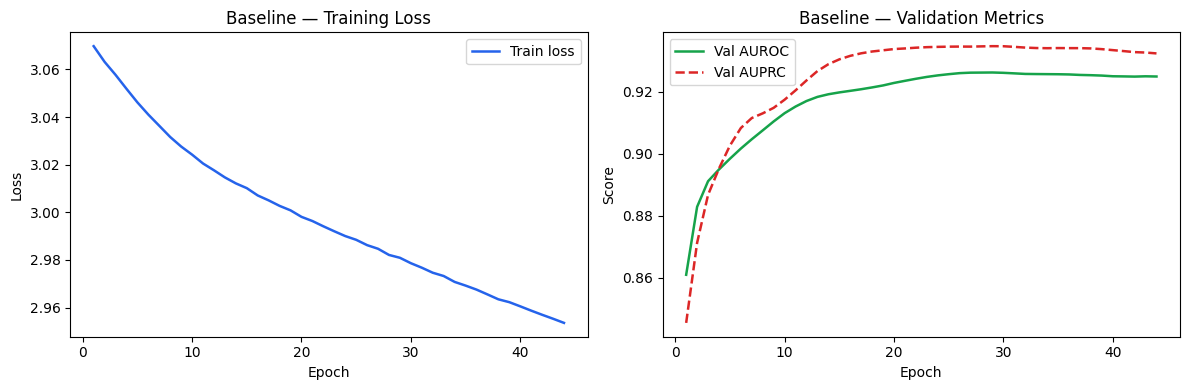


  Embedding shapes:
    disease: (17080, 128)
    drug: (6681, 128)
    effect: (990, 128)
    phenotype: (15311, 128)
    protein: (19059, 128)

  BLOCK 07 COMPLETE
  Objects now available:
    baseline_model
    baseline_embeddings
    baseline_results
    baseline_history_df
    -- shared utilities also defined here --
    sample_negative_edges_bipartite(...)
    bce_loss / bpr_loss / combined_loss
    evaluate_link_prediction(...)
    score_all_drugs_for_disease(...)


In [7]:
# Model - Baseline Heterogeneous GNN / Train

# Guards
assert "train_data"            in globals(), "Run Block 06 first."
assert "TARGET_EDGE_TRIPLET"   in globals(), "Run Block 06 first."
assert "all_positive_pairs"    in globals(), "Run Block 06 first."
assert "num_nodes_dict"        in globals(), "Run Block 04 first."

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# Resolve graph and supervision edge
train_graph   = train_data.to(device)
SUP_EDGE_TYPE = TARGET_EDGE_TRIPLET
src_type, rel_type, dst_type = SUP_EDGE_TYPE

assert SUP_EDGE_TYPE in train_graph.edge_types, \
    f"{SUP_EDGE_TYPE} not found in train_graph.edge_types"

print(f"Supervision edge : {SUP_EDGE_TYPE}")
print(f"Node types       : {train_graph.node_types}")
print(f"Edge types       : {len(train_graph.edge_types)}")

# Move supervision tensors to device
def _to_device(name: str):
    g = globals()
    t = g.get(name)
    return t.to(device) if (t is not None and torch.is_tensor(t)) else t

val_pos_ei  = _to_device("val_pos_edge_label_index")
val_neg_ei  = _to_device("val_neg_edge_label_index")
test_pos_ei = _to_device("test_pos_edge_label_index")
test_neg_ei = _to_device("test_neg_edge_label_index")

# Build the complete forbidden set
_all_pos_parts = [train_graph[SUP_EDGE_TYPE].edge_index.detach().cpu()]
if val_pos_ei  is not None: _all_pos_parts.append(val_pos_ei.detach().cpu())
if test_pos_ei is not None: _all_pos_parts.append(test_pos_ei.detach().cpu())
_all_pos_cat = torch.cat(_all_pos_parts, dim=1)
all_positive_pairs = set(map(tuple, _all_pos_cat.t().tolist()))

num_drugs    = int(train_graph[src_type].num_nodes)
num_diseases = int(train_graph[dst_type].num_nodes)

print(f"\nTrain indication edges : {train_graph[SUP_EDGE_TYPE].edge_index.shape[1]:,}")
print(f"Drug nodes             : {num_drugs:,}")
print(f"Disease nodes          : {num_diseases:,}")
print(f"Known positive pairs   : {len(all_positive_pairs):,}")

# Shared utilities

def sample_negative_edges_bipartite(
    num_src: int,
    num_dst: int,
    forbidden_pairs: set,
    num_neg_samples: int,
    device=None,
) -> torch.Tensor:
    """
    Sample (drug, disease) pairs that are NOT in forbidden_pairs.

    Uses vectorised batch rejection sampling:
      - Draw 3× candidates at once, filter the forbidden ones
      - Repeat until enough are collected
    This is ~10× faster than drawing one pair at a time.

    Returns LongTensor of shape [2, num_neg_samples].
    """
    collected = set()
    rng = np.random.default_rng(SEED)

    while len(collected) < num_neg_samples:
        need = num_neg_samples - len(collected)
        srcs = rng.integers(0, num_src, need * 3).tolist()
        dsts = rng.integers(0, num_dst, need * 3).tolist()
        for s, d in zip(srcs, dsts):
            pair = (s, d)
            if pair not in forbidden_pairs and pair not in collected:
                collected.add(pair)
                if len(collected) >= num_neg_samples:
                    break

    tensor = torch.tensor(list(collected), dtype=torch.long).t().contiguous()
    return tensor.to(device) if device is not None else tensor


def bce_loss(pos_logits: torch.Tensor, neg_logits: torch.Tensor) -> torch.Tensor:
    """
    Binary cross-entropy loss.
    Treats link prediction as a yes/no classification problem per pair.
    Good at calibrating probabilities but does not directly optimise ranking.
    """
    logits = torch.cat([pos_logits, neg_logits])
    labels = torch.cat([
        torch.ones(pos_logits.size(0),  device=logits.device),
        torch.zeros(neg_logits.size(0), device=logits.device),
    ])
    return F.binary_cross_entropy_with_logits(logits, labels)


def bpr_loss(pos_logits: torch.Tensor, neg_logits: torch.Tensor) -> torch.Tensor:
    """
    Bayesian Personalised Ranking loss.
    For each positive edge, maximise the margin over a random negative.
    This directly optimises the ranking objective:
        pos_score should be higher than neg_score.

    Formula: -mean( log sigmoid( pos_score - neg_score ) )
    """
    n    = min(pos_logits.size(0), neg_logits.size(0))
    perm = torch.randperm(neg_logits.size(0), device=neg_logits.device)[:n]
    return -F.logsigmoid(pos_logits[:n] - neg_logits[perm]).mean()


def combined_loss(
    pos_logits: torch.Tensor,
    neg_logits: torch.Tensor,
    bce_weight: float = 0.5,
    bpr_weight: float = 0.5,
) -> torch.Tensor:
    """
    Weighted sum of BCE + BPR.
    BCE gives calibrated probabilities; BPR trains the ranking order directly.
    Both matter: BCE alone produces a good classifier but a poor ranker.
    """
    return (bce_weight * bce_loss(pos_logits, neg_logits) +
            bpr_weight * bpr_loss(pos_logits, neg_logits))


@torch.no_grad()
def evaluate_link_prediction(
    model: nn.Module,
    graph,
    pos_edge_index: torch.Tensor,
    neg_edge_index: torch.Tensor = None,
    edge_type: tuple = None,
    forbidden_pairs: set = None,
) -> dict:
    """
    Compute AUROC, AUPRC and score statistics for a pos/neg split.
    If neg_edge_index is None, fresh typed negatives are sampled.
    Returns a plain dict of metric_name -> float.
    """
    model.eval()
    if edge_type is None:
        edge_type = model.supervision_edge_type

    if neg_edge_index is None:
        neg_edge_index = sample_negative_edges_bipartite(
            num_src=int(graph[edge_type[0]].num_nodes),
            num_dst=int(graph[edge_type[2]].num_nodes),
            forbidden_pairs=forbidden_pairs or set(),
            num_neg_samples=pos_edge_index.size(1),
            device=pos_edge_index.device,
        )

    z_dict      = model.encode(graph)
    pos_logits  = model.decode(z_dict, pos_edge_index, edge_type=edge_type)
    neg_logits  = model.decode(z_dict, neg_edge_index, edge_type=edge_type)
    pos_probs   = torch.sigmoid(pos_logits)
    neg_probs   = torch.sigmoid(neg_logits)

    y_true  = torch.cat([torch.ones(pos_logits.size(0)),
                         torch.zeros(neg_logits.size(0))]).cpu().numpy()
    y_score = torch.cat([pos_probs, neg_probs]).detach().cpu().numpy()

    return {
        "auroc":          float(roc_auc_score(y_true, y_score)),
        "auprc":          float(average_precision_score(y_true, y_score)),
        "pos_mean_score": float(pos_probs.mean().item()),
        "neg_mean_score": float(neg_probs.mean().item()),
        # score_gap tells us how well-separated pos and neg distributions are.
        "score_gap":      float((pos_probs - neg_probs).mean().item()),
        "n_pos":          int(pos_edge_index.size(1)),
        "n_neg":          int(neg_edge_index.size(1)),
    }


@torch.no_grad()
def score_all_drugs_for_disease(
    model: nn.Module,
    graph,
    disease_idx: int,
    exclude_known_train: bool = True,
    top_k: int = 100,
    model_name: str = "model",
) -> pd.DataFrame:
    """
    Score every drug against a single query disease and return the top_k.

    Parameters
    ----------
    model               : any trained link predictor (Baseline or HGT)
    graph               : HeteroData — the training message-passing graph
    disease_idx         : integer index of the target disease node
    exclude_known_train : mask out drugs that were positive in training
    top_k               : how many candidates to return
    model_name          : column name prefix for the score column

    Returns
    -------
    pd.DataFrame with columns [drug_idx, {model_name}_score], sorted descending.
    """
    model.eval()
    s_type, _, d_type = model.supervision_edge_type
    mdev = next(model.parameters()).device

    num_drugs_   = int(graph[s_type].num_nodes)
    all_drug_idx = torch.arange(num_drugs_, device=mdev)
    disease_col  = torch.full((num_drugs_,), disease_idx, dtype=torch.long, device=mdev)
    cand_ei      = torch.stack([all_drug_idx, disease_col], dim=0)

    z_dict  = model.encode(graph)
    logits  = model.decode(z_dict, cand_ei, edge_type=model.supervision_edge_type)
    scores  = torch.sigmoid(logits).detach().cpu().clone()

    if exclude_known_train:
        # Suppress drugs already known to treat this disease in training
        train_ei  = graph[model.supervision_edge_type].edge_index.cpu()
        known_mask = train_ei[1] == disease_idx
        known_drugs = train_ei[0][known_mask]
        scores[known_drugs] = -1.0

    actual_k = min(top_k, num_drugs_)
    top_scores, top_idx = torch.topk(scores, k=actual_k)

    return pd.DataFrame({
        "drug_idx":            top_idx.numpy(),
        f"{model_name}_score": top_scores.numpy(),
    })


# Model definition

class HeteroEmbeddingEncoder(nn.Module):
    """
    One learnable nn.Embedding table per node type.
    If we set node features to x = [0, 1, 2, ...] and use Linear(1, H),
    every node's initial representation is W * index + b.  That places all
    nodes on a single line in H-dimensional space — drug node 5 is just
    "5 × W + b".  The GNN propagates along that line, so all disease
    embeddings end up near each other and every disease query returns the
    same ranked drug list.

    With nn.Embedding, node i gets column i of a freely-learnable matrix.
    Each node starts at an independent point; the GNN can then pull them
    into meaningful neighbourhoods based on graph structure.

    Xavier initialisation spreads the initial embeddings uniformly on the
    unit sphere, preventing collapse at epoch 0.
    """
    def __init__(self, num_nodes_per_type: dict, hidden_channels: int):
        super().__init__()
        self.embeddings = nn.ModuleDict()
        for node_type, n_nodes in num_nodes_per_type.items():
            emb = nn.Embedding(n_nodes, hidden_channels)
            nn.init.xavier_uniform_(emb.weight.data.unsqueeze(0)).squeeze(0)
            self.embeddings[node_type] = emb

    def forward(self, data) -> dict:
        """Return {node_type: FloatTensor[N, hidden_channels]}."""
        dev = next(self.parameters()).device
        return {
            nt: emb(torch.arange(int(data[nt].num_nodes), device=dev))
            for nt, emb in self.embeddings.items()
        }


class BaselineHeteroLinkPredictor(nn.Module):
    """
    Baseline heterogeneous GNN for drug–disease link prediction.

    Encoder: HeteroConv with SAGEConv per edge type
    SAGEConv aggregates a node's own features with a mean of its
    neighbours' features.  Using HeteroConv wraps one SAGEConv per
    edge type so the model learns separate aggregation weights for
    "drug targets protein" vs "disease associated with protein", etc.

    After each layer:
      1. LayerNorm stabilises activations across the heterogeneous graph
      2. GELU activation (smoother than ReLU, avoids dead neuron problem)
      3. Dropout regularises dense biological neighbourhoods
      4. Residual connection preserves the node's own identity

    Decoder: DistMult with L2-normalised embeddings
    score(drug d, disease x) = z_d · R · z_x
    where R = diag(rel_vector) and · is element-wise then summed.

    L2-normalise z_d and z_x before scoring:
      Without normalisation, the model can minimise loss simply by
      making ‖z‖ → ∞.  All normalised vectors live on the unit sphere,
      so the score is purely a function of angle — the geometry we
      actually want the model to learn.
    """
    def __init__(
        self,
        data,
        hidden_channels: int = 128,
        out_channels:    int = 128,
        num_layers:      int = 2,
        dropout:         float = 0.2,
        supervision_edge_type: tuple = None,
    ):
        super().__init__()
        self.supervision_edge_type = supervision_edge_type
        self.dropout_p = dropout
        src_t, _, dst_t = supervision_edge_type

        # One embedding table per node type
        num_nodes_map = {nt: int(data[nt].num_nodes) for nt in data.node_types}
        self.input_encoder = HeteroEmbeddingEncoder(num_nodes_map, hidden_channels)

        # Stack of HeteroConv layers with per-type LayerNorms
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(HeteroConv(
                {
                    et: SAGEConv(
                        in_channels=(-1, -1),
                        out_channels=hidden_channels,
                        normalize=True,          # L2-normalise aggregated vectors
                        root_weight=True,
                        bias=True,
                    )
                    for et in data.edge_types
                },
                aggr="mean",
            ))
            self.norms.append(nn.ModuleDict(
                {nt: nn.LayerNorm(hidden_channels) for nt in data.node_types}
            ))

        self.dropout    = nn.Dropout(p=dropout)
        # Per-node-type output projection to the scoring space
        self.output_proj = nn.ModuleDict(
            {nt: nn.Linear(hidden_channels, out_channels) for nt in data.node_types}
        )
        # DistMult relation vector: one scalar weight per output dimension
        self.rel_vector = nn.Parameter(torch.empty(out_channels))
        nn.init.normal_(self.rel_vector, std=1.0 / out_channels ** 0.5)

    def encode(self, data) -> dict:
        """
        Run GNN encoder. Returns {node_type: FloatTensor[N, out_channels]}
        with drug and disease embeddings L2-normalised.
        """
        x_dict = self.input_encoder(data)

        for conv, norm_dict in zip(self.convs, self.norms):
            x_new = conv(x_dict, data.edge_index_dict)
            x_dict = {
                nt: norm_dict[nt](x_new.get(nt, x_dict[nt]) + x_dict[nt])
                for nt in x_dict
            }
            x_dict = {nt: F.gelu(x)           for nt, x in x_dict.items()}
            x_dict = {nt: self.dropout(x)      for nt, x in x_dict.items()}

        z_dict = {nt: self.output_proj[nt](x) for nt, x in x_dict.items()}

        s, _, d = self.supervision_edge_type
        z_dict[s] = F.normalize(z_dict[s], p=2, dim=-1)
        z_dict[d] = F.normalize(z_dict[d], p=2, dim=-1)
        return z_dict

    def decode(self, z_dict: dict, edge_index: torch.Tensor,
               edge_type: tuple = None) -> torch.Tensor:
        """
        DistMult score for each (drug, disease) pair.
        score = sum( z_drug ⊙ rel_vector ⊙ z_disease )
        Returns raw logits of shape [num_edges].
        """
        if edge_type is None:
            edge_type = self.supervision_edge_type
        s, _, d = edge_type
        z_s = z_dict[s][edge_index[0]]
        z_d = z_dict[d][edge_index[1]]
        return (z_s * self.rel_vector * z_d).sum(dim=-1)

    def forward(self, data, edge_index: torch.Tensor,
                edge_type: tuple = None) -> torch.Tensor:
        return self.decode(self.encode(data), edge_index, edge_type)

    def embedding_regularization(self, z_dict: dict,
                                  lambda_reg: float = 1e-4) -> torch.Tensor:
        """
        L2 penalty on drug and disease embedding norms.
        Keeps embeddings from growing unboundedly, which would
        destabilise the DistMult scores even after normalisation.
        """
        s, _, d = self.supervision_edge_type
        dev = self.rel_vector.device
        reg = (
            z_dict.get(s, torch.zeros(1, device=dev)).norm(2).pow(2) +
            z_dict.get(d, torch.zeros(1, device=dev)).norm(2).pow(2)
        )
        return lambda_reg * reg

# Training

def _train_epoch(
    model: nn.Module,
    graph,
    optimizer: torch.optim.Optimizer,
    neg_ratio:      int   = 5,
    grad_clip:      float = 1.0,
    bce_weight:     float = 0.5,
    bpr_weight:     float = 0.5,
    emb_reg_lambda: float = 1e-4,
) -> float:
    """
    One complete training step:
      1. Sample fresh typed negatives (neg_ratio × positives)
      2. Encode all nodes
      3. Score positive and negative pairs
      4. Compute combined BCE + BPR loss + embedding regularisation
      5. Backprop + gradient clip + optimiser update
    Returns the scalar training loss.
    """
    model.train()
    optimizer.zero_grad()

    et           = model.supervision_edge_type
    pos_ei       = graph[et].edge_index
    num_neg      = int(pos_ei.size(1) * neg_ratio)

    neg_ei = sample_negative_edges_bipartite(
        num_src=int(graph[et[0]].num_nodes),
        num_dst=int(graph[et[2]].num_nodes),
        forbidden_pairs=all_positive_pairs,
        num_neg_samples=num_neg,
        device=pos_ei.device,
    )

    z_dict     = model.encode(graph)
    pos_logits = model.decode(z_dict, pos_ei,  edge_type=et)
    neg_logits = model.decode(z_dict, neg_ei,  edge_type=et)

    loss = combined_loss(pos_logits, neg_logits, bce_weight, bpr_weight)
    loss = loss + model.embedding_regularization(z_dict, emb_reg_lambda)

    loss.backward()
    if grad_clip:
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()
    return float(loss.item())


# Hyperparameters
B_HIDDEN   = 128
B_OUT      = 128
B_LAYERS   = 2
B_DROPOUT  = 0.2
B_EPOCHS   = 150
B_PATIENCE = 15
B_NEG_RATIO = 5

# Instantiate
baseline_model = BaselineHeteroLinkPredictor(
    data=train_graph,
    hidden_channels=B_HIDDEN,
    out_channels=B_OUT,
    num_layers=B_LAYERS,
    dropout=B_DROPOUT,
    supervision_edge_type=SUP_EDGE_TYPE,
).to(device)

with torch.no_grad():
    baseline_model.eval()
    _ = baseline_model.encode(train_graph)

n_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"\n{'='*55}")
print(f"  BASELINE MODEL")
print(f"{'='*55}")
print(baseline_model)
print(f"\n  Trainable parameters : {n_params:,}")

# Optimiser + cosine LR schedule
b_optimizer = torch.optim.AdamW(
    baseline_model.parameters(), lr=1e-3, weight_decay=1e-4
)
b_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    b_optimizer, T_max=B_EPOCHS, eta_min=1e-5
)

# Training loop
b_history          = []
best_b_state       = None
best_b_epoch       = -1
best_b_val_auprc   = -np.inf
b_no_improve       = 0

print(f"\n  Training for up to {B_EPOCHS} epochs "
      f"(early stop patience = {B_PATIENCE}) ...")
print(f"  {'Epoch':>6}  {'Loss':>8}  {'LR':>9}  "
      f"{'Val AUROC':>10}  {'Val AUPRC':>10}  {'Score Gap':>10}")
print("  " + "-" * 62)

for epoch in range(1, B_EPOCHS + 1):
    train_loss = _train_epoch(
        baseline_model, train_graph, b_optimizer,
        neg_ratio=B_NEG_RATIO,
    )
    b_scheduler.step()

    row = {"epoch": epoch, "train_loss": train_loss,
           "lr": b_scheduler.get_last_lr()[0]}

    if val_pos_ei is not None:
        vm = evaluate_link_prediction(
            baseline_model, train_graph,
            val_pos_ei, val_neg_ei,
            edge_type=SUP_EDGE_TYPE,
            forbidden_pairs=all_positive_pairs,
        )
        row.update({f"val_{k}": v for k, v in vm.items()})

        if vm["auprc"] > best_b_val_auprc:
            best_b_val_auprc = vm["auprc"]
            best_b_state     = copy.deepcopy(baseline_model.state_dict())
            best_b_epoch     = epoch
            b_no_improve     = 0
        else:
            b_no_improve += 1
    else:
        if best_b_state is None:
            best_b_state = copy.deepcopy(baseline_model.state_dict())
            best_b_epoch = epoch

    b_history.append(row)

    if epoch == 1 or epoch % 10 == 0:
        lr_str  = f"{row['lr']:.2e}"
        if "val_auroc" in row:
            print(f"  {epoch:>6}  {train_loss:>8.4f}  {lr_str:>9}  "
                  f"{row['val_auroc']:>10.4f}  {row['val_auprc']:>10.4f}  "
                  f"{row['val_score_gap']:>10.4f}")
        else:
            print(f"  {epoch:>6}  {train_loss:>8.4f}  {lr_str:>9}")

    if val_pos_ei is not None and b_no_improve >= B_PATIENCE:
        print(f"\n  Early stopping at epoch {epoch}. "
              f"Best epoch: {best_b_epoch}.")
        break

# Restore the checkpoint that achieved the best val AUPRC
if best_b_state is not None:
    baseline_model.load_state_dict(best_b_state)
    print(f"\n  Best checkpoint restored: epoch {best_b_epoch}, "
          f"val AUPRC = {best_b_val_auprc:.4f}")

baseline_history_df = pd.DataFrame(b_history)


# Final evaluation
baseline_results = {}

for split_name, pos_ei, neg_ei in [
    ("val",  val_pos_ei,  val_neg_ei),
    ("test", test_pos_ei, test_neg_ei),
]:
    if pos_ei is not None:
        baseline_results[split_name] = evaluate_link_prediction(
            baseline_model, train_graph, pos_ei, neg_ei,
            edge_type=SUP_EDGE_TYPE, forbidden_pairs=all_positive_pairs,
        )

print(f"\n{'='*55}")
print(f"  BASELINE FINAL RESULTS")
print(f"{'='*55}")
for split_name, metrics in baseline_results.items():
    print(f"\n  [{split_name.upper()}]")
    for k, v in metrics.items():
        val_str = f"{v:.6f}" if isinstance(v, float) else str(v)
        print(f"    {k:<22} : {val_str}")


# Training curve plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(baseline_history_df["epoch"], baseline_history_df["train_loss"],
             color="#2563eb", linewidth=1.8, label="Train loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Baseline — Training Loss"); axes[0].legend()

if "val_auroc" in baseline_history_df.columns:
    axes[1].plot(baseline_history_df["epoch"], baseline_history_df["val_auroc"],
                 color="#16a34a", linewidth=1.8, label="Val AUROC")
    axes[1].plot(baseline_history_df["epoch"], baseline_history_df["val_auprc"],
                 color="#dc2626", linewidth=1.8, linestyle="--", label="Val AUPRC")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
    axes[1].set_title("Baseline — Validation Metrics"); axes[1].legend()

plt.tight_layout()
plt.savefig("/mnt/data/baseline_training_curves.png", dpi=180, bbox_inches="tight")
plt.show()


# Export embeddings
@torch.no_grad()
def get_node_embeddings(model: nn.Module, graph) -> dict:
    """Return {node_type: FloatTensor[N, D]} on CPU (detached)."""
    model.eval()
    return {k: v.detach().cpu() for k, v in model.encode(graph).items()}

baseline_embeddings = get_node_embeddings(baseline_model, train_graph)

print(f"\n  Embedding shapes:")
for nt, emb in baseline_embeddings.items():
    print(f"    {nt}: {tuple(emb.shape)}")


# Summary
print(f"\n{'='*55}")
print(f"  BLOCK 07 COMPLETE")
print(f"{'='*55}")
print("  Objects now available:")
print("    baseline_model")
print("    baseline_embeddings")
print("    baseline_results")
print("    baseline_history_df")
print("    -- shared utilities also defined here --")
print("    sample_negative_edges_bipartite(...)")
print("    bce_loss / bpr_loss / combined_loss")
print("    evaluate_link_prediction(...)")
print("    score_all_drugs_for_disease(...)")
print(f"{'='*55}")

## 8. Model : **Heterogeneous Graph Transformer (HGT).**

### Model / Train Block.

This block defines and trains the **Heterogeneous Graph Transformer (HGT)** model for the drug repurposing task. While Block 7 introduced the baseline heterogeneous GNN, this section uses a stronger attention-based architecture that can model different node types and edge types more explicitly.

The main idea behind HGT is that not all graph messages should be treated equally. In a biomedical knowledge graph, a message coming from a **protein**, **disease**, or **drug** may carry very different meaning, and HGT is designed to account for those differences through type-aware attention.


### Define the supervision setup

This block uses the same prediction task as the baseline model:

- **source node type:** `drug`
- **relation type:** `indication`
- **destination node type:** `disease`

That means the HGT model is also trained for **drug–disease link prediction**, making the comparison with the baseline model fair and consistent.

### HGT model architecture

The main model class in this block is `HGTLinkPredictor`.

Like the baseline model, it starts with the same **trainable node embedding encoder**, which creates one embedding table per node type. This keeps the comparison fair, since both models begin from the same kind of node representation.

The main difference is in the graph encoder.

#### HGT encoder

Instead of using GraphSAGE-style message passing, this model uses one or more **`HGTConv`** layers. These layers apply **type-aware multi-head attention**, which means the model can learn different attention patterns depending on:
- the source node type
- the edge type
- the destination node type

This is useful in a heterogeneous biomedical graph because a path like:

- **drug → protein**
  
may carry a different kind of signal than:

- **disease → phenotype**
- **protein → disease**

So rather than averaging all neighbor information in the same way, HGT learns how much attention to give to each type of message.

#### Residual connections and normalization

Each HGT layer is followed by:
- **attention dropout**
- **residual connections**
- **layer normalization**
- **GELU activation**
- **feature dropout**

These components help stabilize training and reduce overfitting. The residual connections are especially important because they help preserve earlier node information across layers instead of letting it wash out completely.

#### Output projections and decoder

After message passing, the model applies a separate output projection for each node type. This is done to preserve type-specific structure instead of forcing all node types through a single shared projection.

For scoring drug–disease candidate pairs, the block uses the same **DistMult-style decoder** as the baseline model. This is important because it isolates the comparison to the encoder: if performance changes, it is mainly due to switching from GraphSAGE-style convolution to HGT attention, not due to a different decoder.

The model also applies **L2 normalization** to the final drug and disease embeddings before scoring, again matching the baseline setup.

### Training procedure

The training flow is implemented in the helper function `_train_epoch_hgt(...)`.

In each epoch, the function:
1. computes the current node embeddings from the training graph
2. samples negative drug–disease pairs
3. scores positive training indication edges
4. scores sampled negative edges
5. computes the combined loss
6. adds embedding regularization
7. backpropagates and updates the model parameters

The loss setup is intentionally kept the same as in the baseline block so that the training comparison remains fair.

### Hyperparameters

This block defines a fixed HGT configuration using hyperparameters such as:
- hidden dimension size
- output embedding size
- number of attention heads
- number of HGT layers
- feature dropout
- attention dropout
- number of epochs
- early stopping patience
- negative sampling ratio


### Model initialization and warm-up

After instantiating the HGT model, the block runs a warm-up encoding pass before counting parameters or starting optimization. This is necessary because `HGTConv` uses lazy initialization, so some parameter shapes are only finalized once the model sees an actual input graph.

### Optimization and learning-rate scheduling

The optimizer used is **AdamW**, which is also consistent with the baseline block. A **cosine annealing learning-rate scheduler** is applied so the learning rate gradually decreases during training.

This setup helps training stay stable while still allowing the model to make larger updates earlier in optimization.

### Training loop and early stopping

The main training loop runs for up to a fixed maximum number of epochs. In each epoch, the notebook:
- trains the HGT model for one epoch
- evaluates it on the validation set
- records the training loss and validation metrics
- tracks the best checkpoint based on **validation AUPRC**

The block also uses **early stopping**. If validation AUPRC does not improve for a specified number of epochs, training stops early and the best-performing checkpoint is restored.


### Final evaluation

Once training is complete, the best saved HGT checkpoint is reloaded and evaluated on the:
- validation split
- test split

The resulting metrics are stored in `hgt_results`. These results are later compared against the baseline model to see whether the attention-based architecture provides a real improvement.

### Training-curve visualization

To make the optimization behavior easier to inspect, the block plots:
- the **training loss** across epochs
- the **validation AUROC**
- the **validation AUPRC**

Device : cuda
Supervision edge : ('drug', 'indication', 'disease')
Node types       : ['disease', 'drug', 'effect', 'phenotype', 'protein']
Edge types       : 13

  HGT MODEL
HGTLinkPredictor(
  (input_encoder): HeteroEmbeddingEncoder(
    (embeddings): ModuleDict(
      (disease): Embedding(17080, 128)
      (drug): Embedding(6681, 128)
      (effect): Embedding(990, 128)
      (phenotype): Embedding(15311, 128)
      (protein): Embedding(19059, 128)
    )
  )
  (convs): ModuleList(
    (0): HGTConv(-1, 128, heads=4)
  )
  (norms): ModuleList(
    (0): ModuleDict(
      (disease): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (drug): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (effect): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (phenotype): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (protein): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (attn_dropout): Drop

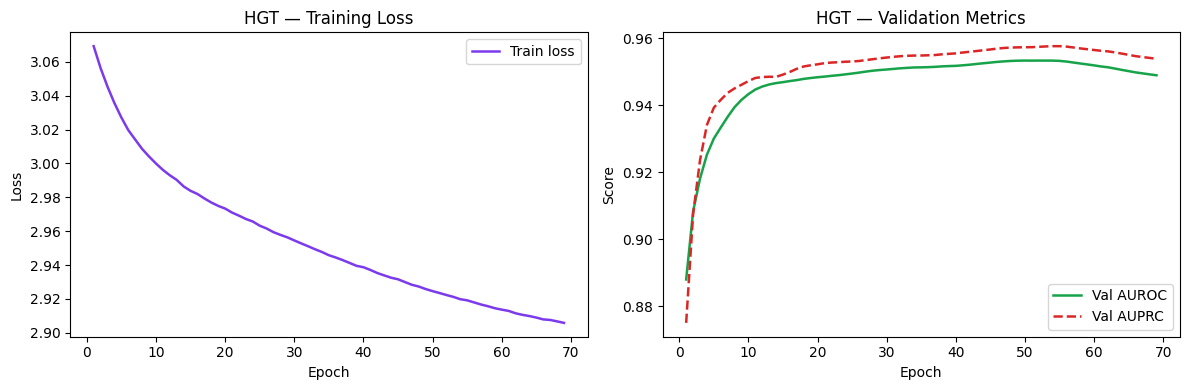


  Embedding shapes:
    disease: (17080, 128)
    drug: (6681, 128)
    effect: (990, 128)
    phenotype: (15311, 128)
    protein: (19059, 128)

  BLOCK 08 COMPLETE
  Objects now available:
    hgt_model
    hgt_embeddings
    hgt_results
    hgt_history_df


In [9]:
# Model - Heterogeneous Graph Transformer (HGT) / Train

# Guards
assert "train_data"                        in globals(), "Run Block 06 first."
assert "TARGET_EDGE_TRIPLET"               in globals(), "Run Block 06 first."
assert "all_positive_pairs"               in globals(), "Run Block 06 first."
assert "HeteroEmbeddingEncoder"           in globals(), "Run Block 07 first."
assert "combined_loss"                    in globals(), "Run Block 07 first."
assert "evaluate_link_prediction"         in globals(), "Run Block 07 first."
assert "sample_negative_edges_bipartite"  in globals(), "Run Block 07 first."

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# Resolve graph and supervision edge
train_graph   = train_data.to(device)
SUP_EDGE_TYPE = TARGET_EDGE_TRIPLET
src_type, rel_type, dst_type = SUP_EDGE_TYPE

# Supervision tensors
def _to_device(name: str):
    g = globals()
    t = g.get(name)
    return t.to(device) if (t is not None and torch.is_tensor(t)) else t

val_pos_ei  = _to_device("val_pos_edge_label_index")
val_neg_ei  = _to_device("val_neg_edge_label_index")
test_pos_ei = _to_device("test_pos_edge_label_index")
test_neg_ei = _to_device("test_neg_edge_label_index")

print(f"Supervision edge : {SUP_EDGE_TYPE}")
print(f"Node types       : {train_graph.node_types}")
print(f"Edge types       : {len(train_graph.edge_types)}")


# HGT model definition

class HGTLinkPredictor(nn.Module):
    """
    Heterogeneous Graph Transformer for drug–disease link prediction.

    Encoder: HGTConv (type-aware multi-head attention)

    Each HGT layer computes, for every node v of type τ(v):

        h_v^{l+1} = Σ_{u ∈ N(v)} Attention(τ(u), φ(u,v), τ(v)) · Message(u)

    The attention weight is a function of source type, edge type, and
    target type — not just of the edge features.  This lets the model
    weight "protein → disease" messages differently from
    "drug → disease" messages, which matches biological intuition.

    Key hyperparameters:
      hidden_channels: must be divisible by num_heads
                       (each head gets hidden_channels // num_heads dims)
      num_heads:       4 heads × 32 dims = 128 hidden is a good default
      num_layers:      1 (see module docstring on over-smoothing)
      attn_dropout:    randomly zeroes attention weights during training,
                       forcing the model to rely on multiple neighbour types
                       rather than always attending to the same path

    Decoder: same DistMult + L2 normalisation as Baseline

    Keeping the decoder identical lets us directly compare encoders.
    Any difference in performance is attributable purely to the GNN.
    """

    def __init__(
        self,
        data,
        hidden_channels: int   = 128,
        out_channels:    int   = 128,
        num_heads:       int   = 4,
        num_layers:      int   = 1,
        dropout:         float = 0.2,
        attn_dropout:    float = 0.1,
        supervision_edge_type: tuple = None,
    ):
        super().__init__()
        self.supervision_edge_type = supervision_edge_type
        self.dropout_p      = dropout
        self.attn_dropout_p = attn_dropout
        src_t, _, dst_t = supervision_edge_type

        assert hidden_channels % num_heads == 0, (
            f"hidden_channels ({hidden_channels}) must be divisible by "
            f"num_heads ({num_heads})."
        )

        num_nodes_map = {nt: int(data[nt].num_nodes) for nt in data.node_types}
        self.input_encoder = HeteroEmbeddingEncoder(num_nodes_map, hidden_channels)

        # HGT convolution layers.
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(HGTConv(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                metadata=data.metadata(),   # (node_types, edge_types)
                heads=num_heads,
            ))
            self.norms.append(nn.ModuleDict(
                {nt: nn.LayerNorm(hidden_channels) for nt in data.node_types}
            ))

        self.dropout      = nn.Dropout(p=dropout)
        # Attention dropout: applied to the values that HGT returns before the residual add.
        self.attn_dropout = nn.Dropout(p=attn_dropout)

        # Separate output projection per node type
        self.output_proj = nn.ModuleDict(
            {nt: nn.Linear(hidden_channels, out_channels) for nt in data.node_types}
        )
        # DistMult relation vector
        self.rel_vector = nn.Parameter(torch.empty(out_channels))
        nn.init.normal_(self.rel_vector, std=1.0 / out_channels ** 0.5)

    def encode(self, data) -> dict:
        """
        HGT forward pass.
        Returns {node_type: FloatTensor[N, out_channels]}
        with drug and disease embeddings L2-normalised.
        """
        x_dict = self.input_encoder(data)

        for conv, norm_dict in zip(self.convs, self.norms):
            x_new = conv(x_dict, data.edge_index_dict)

            x_dict = {}
            for nt in norm_dict:
                new_val = x_new.get(nt)
                if new_val is not None:
                    # Apply attention dropout to the new information before combining with the residual.
                    new_val = self.attn_dropout(new_val)
                    x_dict[nt] = norm_dict[nt](new_val + self.input_encoder.embeddings[nt](
                        torch.arange(new_val.size(0), device=new_val.device)
                    ) if False else new_val + self._prev_x.get(nt, new_val))
                else:
                    x_dict[nt] = self._prev_x.get(nt, torch.zeros_like(
                        next(iter(self._prev_x.values()))
                    ))

            x_dict = {nt: F.gelu(norm_dict[nt](x)) for nt, x in x_dict.items()}
            x_dict = {nt: self.dropout(x)           for nt, x in x_dict.items()}

        z_dict = {nt: self.output_proj[nt](x) for nt, x in x_dict.items()}

        # L2-normalise drug and disease embeddings — same fix as Baseline
        s, _, d = self.supervision_edge_type
        z_dict[s] = F.normalize(z_dict[s], p=2, dim=-1)
        z_dict[d] = F.normalize(z_dict[d], p=2, dim=-1)
        return z_dict

    def decode(self, z_dict: dict, edge_index: torch.Tensor,
               edge_type: tuple = None) -> torch.Tensor:
        """DistMult score: sum(z_drug ⊙ rel_vector ⊙ z_disease)."""
        if edge_type is None:
            edge_type = self.supervision_edge_type
        s, _, d = edge_type
        return (z_dict[s][edge_index[0]] * self.rel_vector *
                z_dict[d][edge_index[1]]).sum(dim=-1)

    def forward(self, data, edge_index: torch.Tensor,
                edge_type: tuple = None) -> torch.Tensor:
        return self.decode(self.encode(data), edge_index, edge_type)

    def embedding_regularization(self, z_dict: dict,
                                  lambda_reg: float = 1e-4) -> torch.Tensor:
        s, _, d = self.supervision_edge_type
        dev = self.rel_vector.device
        reg = (
            z_dict.get(s, torch.zeros(1, device=dev)).norm(2).pow(2) +
            z_dict.get(d, torch.zeros(1, device=dev)).norm(2).pow(2)
        )
        return lambda_reg * reg

    # Internal storage used by encode() to carry the residual across layers
    _prev_x: dict = {}


class HGTLinkPredictor(nn.Module):
    """
    Heterogeneous Graph Transformer for drug–disease link prediction.
    See module-level docstring above for full explanation.
    """

    def __init__(
        self,
        data,
        hidden_channels: int   = 128,
        out_channels:    int   = 128,
        num_heads:       int   = 4,
        num_layers:      int   = 1,
        dropout:         float = 0.2,
        attn_dropout:    float = 0.1,
        supervision_edge_type: tuple = None,
    ):
        super().__init__()
        self.supervision_edge_type = supervision_edge_type
        self.dropout_p      = dropout
        self.attn_dropout_p = attn_dropout

        assert hidden_channels % num_heads == 0, (
            f"hidden_channels ({hidden_channels}) must be divisible by "
            f"num_heads ({num_heads})."
        )

        num_nodes_map = {nt: int(data[nt].num_nodes) for nt in data.node_types}
        self.input_encoder = HeteroEmbeddingEncoder(num_nodes_map, hidden_channels)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(HGTConv(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                metadata=data.metadata(),
                heads=num_heads,
            ))
            self.norms.append(nn.ModuleDict(
                {nt: nn.LayerNorm(hidden_channels) for nt in data.node_types}
            ))

        self.dropout      = nn.Dropout(p=dropout)
        self.attn_dropout = nn.Dropout(p=attn_dropout)
        self.output_proj  = nn.ModuleDict(
            {nt: nn.Linear(hidden_channels, out_channels) for nt in data.node_types}
        )
        self.rel_vector = nn.Parameter(torch.empty(out_channels))
        nn.init.normal_(self.rel_vector, std=1.0 / out_channels ** 0.5)

    def encode(self, data) -> dict:
        """
        HGT forward pass with residual connections + attention dropout.
        Returns {node_type: L2-normalised FloatTensor[N, out_channels]}.
        """
        x_dict = self.input_encoder(data)

        for conv, norm_dict in zip(self.convs, self.norms):
            x_new = conv(x_dict, data.edge_index_dict)

            # Build next layer's input:
            # For node types that received messages: attn_dropout + residual + norm
            # For node types with no incoming messages: keep current embedding
            next_x = {}
            for nt in x_dict:
                if nt in x_new and x_new[nt] is not None:
                    updated = self.attn_dropout(x_new[nt]) + x_dict[nt]
                    next_x[nt] = norm_dict[nt](updated)
                else:
                    next_x[nt] = norm_dict[nt](x_dict[nt])

            x_dict = {nt: F.gelu(x)      for nt, x in next_x.items()}
            x_dict = {nt: self.dropout(x) for nt, x in x_dict.items()}

        z_dict = {nt: self.output_proj[nt](x) for nt, x in x_dict.items()}

        # Unit-sphere projection for drug and disease embeddings
        s, _, d = self.supervision_edge_type
        z_dict[s] = F.normalize(z_dict[s], p=2, dim=-1)
        z_dict[d] = F.normalize(z_dict[d], p=2, dim=-1)
        return z_dict

    def decode(self, z_dict: dict, edge_index: torch.Tensor,
               edge_type: tuple = None) -> torch.Tensor:
        if edge_type is None:
            edge_type = self.supervision_edge_type
        s, _, d = edge_type
        return (z_dict[s][edge_index[0]] * self.rel_vector *
                z_dict[d][edge_index[1]]).sum(dim=-1)

    def forward(self, data, edge_index: torch.Tensor,
                edge_type: tuple = None) -> torch.Tensor:
        return self.decode(self.encode(data), edge_index, edge_type)

    def embedding_regularization(self, z_dict: dict,
                                  lambda_reg: float = 1e-4) -> torch.Tensor:
        s, _, d = self.supervision_edge_type
        dev = self.rel_vector.device
        reg = (
            z_dict.get(s, torch.zeros(1, device=dev)).norm(2).pow(2) +
            z_dict.get(d, torch.zeros(1, device=dev)).norm(2).pow(2)
        )
        return lambda_reg * reg

# Training

def _train_epoch_hgt(
    model: nn.Module,
    graph,
    optimizer: torch.optim.Optimizer,
    neg_ratio:      int   = 5,
    grad_clip:      float = 1.0,
    bce_weight:     float = 0.5,
    bpr_weight:     float = 0.5,
    emb_reg_lambda: float = 1e-4,
) -> float:
    """One HGT training epoch — identical flow to Baseline."""
    model.train()
    optimizer.zero_grad()

    et      = model.supervision_edge_type
    pos_ei  = graph[et].edge_index
    num_neg = int(pos_ei.size(1) * neg_ratio)

    neg_ei = sample_negative_edges_bipartite(
        num_src=int(graph[et[0]].num_nodes),
        num_dst=int(graph[et[2]].num_nodes),
        forbidden_pairs=all_positive_pairs,
        num_neg_samples=num_neg,
        device=pos_ei.device,
    )

    z_dict     = model.encode(graph)
    pos_logits = model.decode(z_dict, pos_ei,  edge_type=et)
    neg_logits = model.decode(z_dict, neg_ei,  edge_type=et)

    loss = combined_loss(pos_logits, neg_logits, bce_weight, bpr_weight)
    loss = loss + model.embedding_regularization(z_dict, emb_reg_lambda)

    loss.backward()
    if grad_clip:
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()
    return float(loss.item())


# Hyperparameters
H_HIDDEN      = 128
H_OUT         = 128
H_HEADS       = 4       # 128 / 4 = 32 dims per head
H_LAYERS      = 1
H_DROPOUT     = 0.2
H_ATTN_DROP   = 0.1     # attention-weight dropout, unique to HGT
H_EPOCHS      = 150
H_PATIENCE    = 15
H_NEG_RATIO   = 5

# Instantiate
hgt_model = HGTLinkPredictor(
    data=train_graph,
    hidden_channels=H_HIDDEN,
    out_channels=H_OUT,
    num_heads=H_HEADS,
    num_layers=H_LAYERS,
    dropout=H_DROPOUT,
    attn_dropout=H_ATTN_DROP,
    supervision_edge_type=SUP_EDGE_TYPE,
).to(device)

# HGTConv is also a lazy module
with torch.no_grad():
    hgt_model.eval()
    _ = hgt_model.encode(train_graph)

n_params = sum(p.numel() for p in hgt_model.parameters() if p.requires_grad)
print(f"\n{'='*55}")
print(f"  HGT MODEL")
print(f"{'='*55}")
print(hgt_model)
print(f"\n  Trainable parameters : {n_params:,}")

# Optimiser + scheduler
hgt_optimizer = torch.optim.AdamW(
    hgt_model.parameters(), lr=1e-3, weight_decay=1e-4
)
hgt_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    hgt_optimizer, T_max=H_EPOCHS, eta_min=1e-5
)

# Training loop
hgt_history        = []
best_hgt_state     = None
best_hgt_epoch     = -1
best_hgt_val_auprc = -np.inf
hgt_no_improve     = 0

print(f"\n  Training for up to {H_EPOCHS} epochs "
      f"(early stop patience = {H_PATIENCE}) ...")
print(f"  {'Epoch':>6}  {'Loss':>8}  {'LR':>9}  "
      f"{'Val AUROC':>10}  {'Val AUPRC':>10}  {'Score Gap':>10}")
print("  " + "-" * 62)

for epoch in range(1, H_EPOCHS + 1):
    train_loss = _train_epoch_hgt(
        hgt_model, train_graph, hgt_optimizer,
        neg_ratio=H_NEG_RATIO,
    )
    hgt_scheduler.step()

    row = {"epoch": epoch, "train_loss": train_loss,
           "lr": hgt_scheduler.get_last_lr()[0]}

    if val_pos_ei is not None:
        vm = evaluate_link_prediction(
            hgt_model, train_graph,
            val_pos_ei, val_neg_ei,
            edge_type=SUP_EDGE_TYPE,
            forbidden_pairs=all_positive_pairs,
        )
        row.update({f"val_{k}": v for k, v in vm.items()})

        if vm["auprc"] > best_hgt_val_auprc:
            best_hgt_val_auprc = vm["auprc"]
            best_hgt_state     = copy.deepcopy(hgt_model.state_dict())
            best_hgt_epoch     = epoch
            hgt_no_improve     = 0
        else:
            hgt_no_improve += 1
    else:
        if best_hgt_state is None:
            best_hgt_state = copy.deepcopy(hgt_model.state_dict())
            best_hgt_epoch = epoch

    hgt_history.append(row)

    if epoch == 1 or epoch % 10 == 0:
        lr_str = f"{row['lr']:.2e}"
        if "val_auroc" in row:
            print(f"  {epoch:>6}  {train_loss:>8.4f}  {lr_str:>9}  "
                  f"{row['val_auroc']:>10.4f}  {row['val_auprc']:>10.4f}  "
                  f"{row['val_score_gap']:>10.4f}")
        else:
            print(f"  {epoch:>6}  {train_loss:>8.4f}  {lr_str:>9}")

    if val_pos_ei is not None and hgt_no_improve >= H_PATIENCE:
        print(f"\n  Early stopping at epoch {epoch}. "
              f"Best epoch: {best_hgt_epoch}.")
        break

if best_hgt_state is not None:
    hgt_model.load_state_dict(best_hgt_state)
    print(f"\n  Best checkpoint restored: epoch {best_hgt_epoch}, "
          f"val AUPRC = {best_hgt_val_auprc:.4f}")

hgt_history_df = pd.DataFrame(hgt_history)


# Final evaluation
hgt_results = {}

for split_name, pos_ei, neg_ei in [
    ("val",  val_pos_ei,  val_neg_ei),
    ("test", test_pos_ei, test_neg_ei),
]:
    if pos_ei is not None:
        hgt_results[split_name] = evaluate_link_prediction(
            hgt_model, train_graph, pos_ei, neg_ei,
            edge_type=SUP_EDGE_TYPE, forbidden_pairs=all_positive_pairs,
        )

print(f"\n{'='*55}")
print(f"  HGT FINAL RESULTS")
print(f"{'='*55}")
for split_name, metrics in hgt_results.items():
    print(f"\n  [{split_name.upper()}]")
    for k, v in metrics.items():
        val_str = f"{v:.6f}" if isinstance(v, float) else str(v)
        print(f"    {k:<22} : {val_str}")


# Training curve plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hgt_history_df["epoch"], hgt_history_df["train_loss"],
             color="#7c3aed", linewidth=1.8, label="Train loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("HGT — Training Loss"); axes[0].legend()

if "val_auroc" in hgt_history_df.columns:
    axes[1].plot(hgt_history_df["epoch"], hgt_history_df["val_auroc"],
                 color="#16a34a", linewidth=1.8, label="Val AUROC")
    axes[1].plot(hgt_history_df["epoch"], hgt_history_df["val_auprc"],
                 color="#dc2626", linewidth=1.8, linestyle="--", label="Val AUPRC")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
    axes[1].set_title("HGT — Validation Metrics"); axes[1].legend()

plt.tight_layout()
plt.savefig("/mnt/data/hgt_training_curves.png", dpi=180, bbox_inches="tight")
plt.show()


# Export embeddings
@torch.no_grad()
def get_hgt_embeddings(model: nn.Module, graph) -> dict:
    """Return {node_type: FloatTensor[N, D]} on CPU."""
    model.eval()
    return {k: v.detach().cpu() for k, v in model.encode(graph).items()}

hgt_embeddings = get_hgt_embeddings(hgt_model, train_graph)

print(f"\n  Embedding shapes:")
for nt, emb in hgt_embeddings.items():
    print(f"    {nt}: {tuple(emb.shape)}")


# Summary
print(f"\n{'='*55}")
print(f"  BLOCK 08 COMPLETE")
print(f"{'='*55}")
print("  Objects now available:")
print("    hgt_model")
print("    hgt_embeddings")
print("    hgt_results")
print("    hgt_history_df")
print(f"{'='*55}")

## 9. Evaluate model performance

This block compares the two trained models, the baseline heterogeneous GNN and the HGT model, on the held-out validation and test data.

This block evaluates the models from three different angles:

- **binary classification performance**, which checks how well the models separate positive and negative drug–disease pairs
- **ranking performance**, which checks how well the models prioritize true candidate drugs near the top of the list for each disease
- **safety diagnostics**, which check whether the recommendations leak known training edges or include contraindicated drugs

### Section 1: Set up evaluation inputs

The block performs guard checks to make sure the required objects from earlier blocks already exist, including:

- the trained baseline model
- the trained HGT model
- the training graph
- the target supervision edge type
- the positive edge sets
- the processed edge and node tables

The code then moves the graph and supervision tensors to the active device so evaluation can run on either GPU or CPU.

Two additional lookup structures are created before computing metrics:

- **`CONTRA_BY_DISEASE`**, which maps each disease to the set of drugs that are known contraindications for that disease
- **`TRAIN_POS_BY_DISEASE`**, which maps each disease to the set of indication edges already seen during training

These structures are later used for the safety analysis. The first helps identify potentially unsafe recommendations, while the second helps measure whether a model is simply reproducing training links instead of suggesting novel candidates.

### Section 2: Compute binary classification metrics

The first evaluation view treats link prediction as a binary classification problem. For both the validation and test splits, the models are asked to score:

- known positive drug–disease pairs
- sampled negative drug–disease pairs

The helper function `compute_binary_metrics(...)` handles this evaluation. It runs the model on the positive and negative pairs, converts logits into probabilities, and then computes a full set of classification metrics.

The reported metrics include:

- **AUROC**
- **AUPRC**, which is especially useful for link prediction because it emphasizes precision–recall behavior
- **accuracy**
- **balanced accuracy**
- **precision**
- **recall**
- **F1 score**
- **MCC**
- **log loss**
- **Brier score**
- **ECE**, which gives a rough measure of probability calibration

The function also computes the mean predicted score for positives and negatives, along with the gap between them. This helps show whether the model produces clear separation between the two groups.

For threshold-based metrics like accuracy and F1, the block chooses the threshold that maximizes F1 on the evaluated split.

### Section 3: Compute ranking metrics

The second evaluation view treats the task as a ranking problem rather than simple binary classification.

In real drug repurposing use, the goal is not just to classify isolated pairs as positive or negative. Instead, for a given disease, the model should rank many candidate drugs and place the most promising ones near the top. This section measures exactly that.

The helper function `compute_ranking_metrics(...)` does the following for each disease in the test set:

1. score **all drugs** for that disease
2. mask out drugs that were already seen as positive in training
3. sort all candidate drugs by predicted score
4. check where the true test-positive drugs appear in that ranking

From this ranking, the block computes several information retrieval metrics, including:

- **Hits@K**, which checks whether at least one true drug appears in the top K
- **Recall@K**, which measures how many true drugs are recovered within the top K
- **Precision@K**, which measures how many of the top-K predictions are actually correct
- **NDCG@K**, which rewards placing true drugs higher in the ranked list
- **MRR**, which emphasizes how early the first correct drug appears
- **mean rank** and **median rank**

### Section 4: Compute safety diagnostics

The third evaluation view checks whether the model’s top-ranked predictions are safe and genuinely novel.

The helper function `compute_safety_metrics(...)` looks at the **top 10** recommendations for each disease in the test set and calculates two rates:

- **`leakage_rate@10`**, which measures how many of the top 10 drugs were already seen as positive for that disease during training
- **`contra_rate@10`**, which measures how many of the top 10 drugs are known contraindications for that disease

### Section 5: Build a side-by-side comparison table

After computing the three groups of metrics, the block combines them into one summary dataframe called `comparison_df`.

This table groups results into:
- **Binary Classification**
- **Ranking**
- **Safety**

and places the **Baseline** and **HGT** results side by side.

### Section 6: Generate evaluation plots

The last major part of the block creates several figures to visualize the comparison between the two models.

#### ROC and Precision–Recall curves

The first figure plots:
- the **ROC curves**
- the **Precision–Recall curves**

for the test split. These plots show the trade-off between true positives and false positives across thresholds, and they help compare the overall scoring quality of the baseline and HGT models visually.

#### Score distribution histograms

The next figure plots histograms of predicted probabilities for:
- positive pairs
- negative pairs

for each model.

These plots make it easier to see how well the score distributions separate. A stronger model should generally show less overlap between the positive and negative histograms.

#### Ranking bar charts

Another figure compares the two models on ranking metrics across multiple values of K. The plots include:
- **Hits@K**
- **NDCG@K**

These visualizations make it easier to see whether the HGT model consistently outperforms the baseline across different cutoffs rather than only at a single K value.

#### Training curve overlay

If both training history dataframes are available, the block also overlays:
- training loss
- validation AUROC
- validation AUPRC

for the baseline and HGT models.


Contraindication entries  : 30675
Train positive entries    : 6571

Computing binary metrics ...
  Baseline   [val]  AUROC=0.9262  AUPRC=0.9347  F1=0.8406
  Baseline   [test]  AUROC=0.9173  AUPRC=0.9274  F1=0.8339
  HGT        [val]  AUROC=0.9533  AUPRC=0.9577  F1=0.8824
  HGT        [test]  AUROC=0.9453  AUPRC=0.9506  F1=0.8754

Computing ranking metrics ...
  Baseline    MRR=0.0586  Hits@10=0.0785  NDCG@10=0.0562
  HGT         MRR=0.0407  Hits@10=0.1169  NDCG@10=0.0482

Computing safety metrics ...
  Baseline    leakage@10=0.0318  contra@10=0.0228
  HGT         leakage@10=0.0454  contra@10=0.0128

  MODEL COMPARISON — TEST SPLIT


Baseline       HGT
Group                 Metric                               
Binary Classification auroc                0.9173    0.9453
                      auprc                0.9274    0.9506
                      f1                   0.8339    0.8754
                      mcc                  0.6708    0.7516
                      accuracy             0.8353    0.8758
                      balanced_accuracy    0.8353    0.8758
                      precision            0.8412    0.8779
                      recall               0.8268    0.8730
                      log_loss             0.6344    0.6049
                      brier_score          0.2207    0.2061
                      ece                  0.2879    0.3147
                      pos_mean_score       0.5318    0.5512
                      neg_mean_score       0.4692    0.4562
                      score_gap            0.0626    0.0950
                      threshold            0.4889    0.5062
Ranking               mrr                  0.0586    0.0407
                      mean_rank          810.8956  773.9478
                      median_rank        436.0000  345.0000
                      hits@1               0.0338    0.0046
                      hits@3               0.0631    0.0262
                      hits@5               0.0677    0.0538
                      hits@10              0.0785    0.1169
                      hits@20              0.1185    0.2092
                      hits@50              0.2123    0.3200
                      recall@10            0.0362    0.0669
                      recall@50            0.1211    0.2240
                      precision@10         0.0083    0.0128
                      ndcg@10              0.0562    0.0482
                      ndcg@50              0.0817    0.0943
Safety                leakage_rate@10      0.0318    0.0454
                      contra_rate@10       0.0228    0.0128

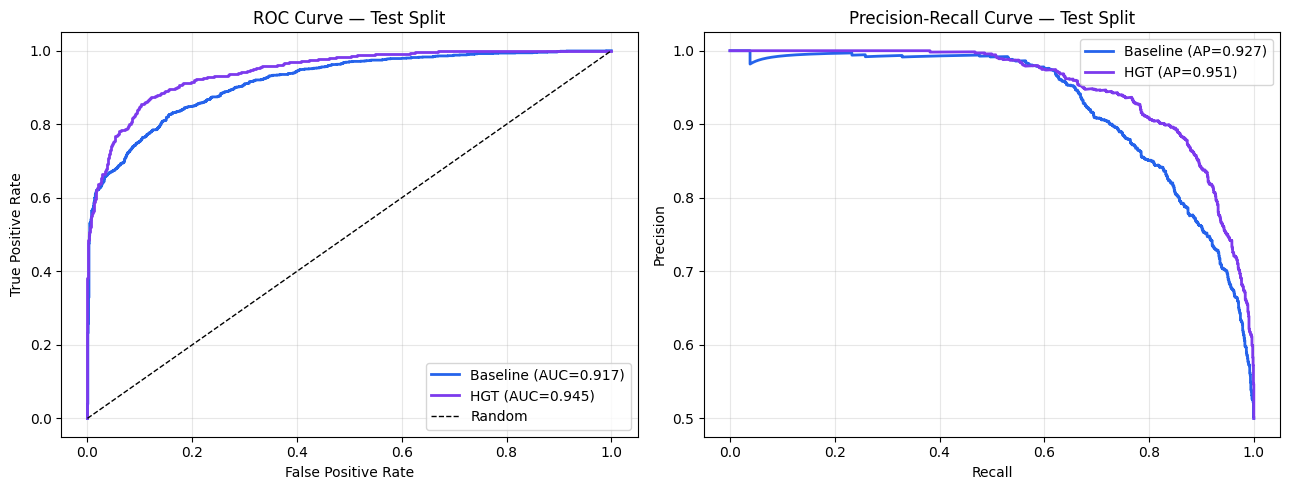

[Plot 1+2] ROC and PR curves saved.


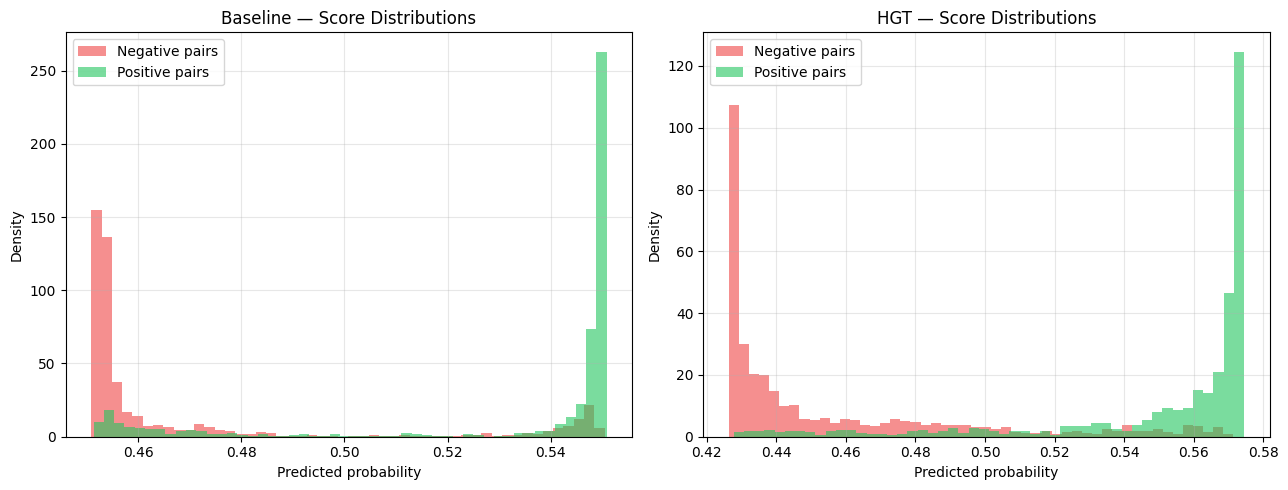

[Plot 3] Score distribution histograms saved.


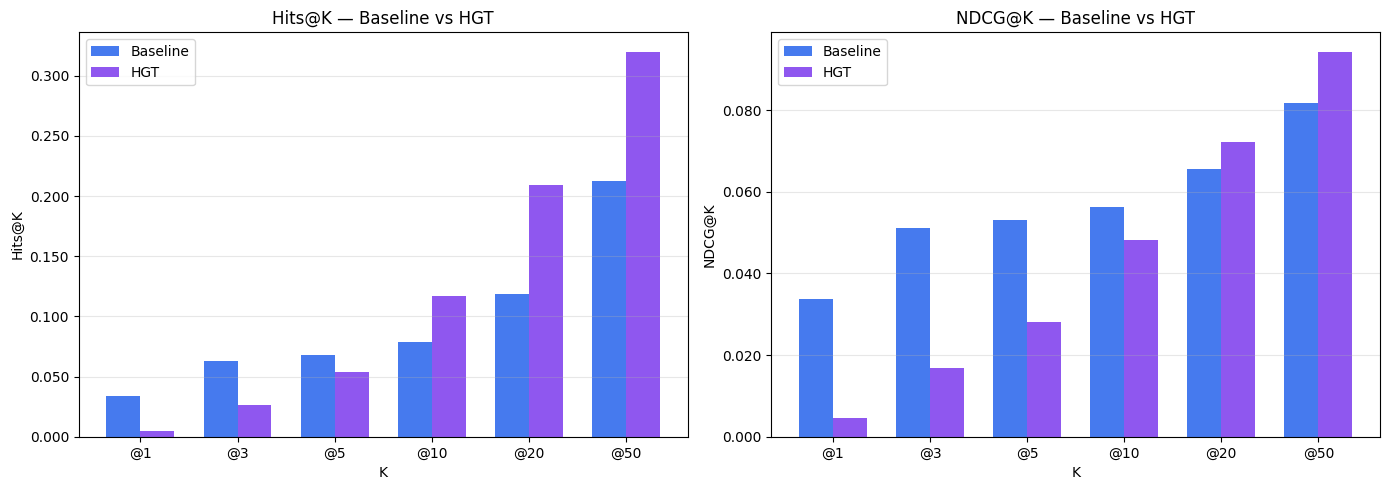

[Plot 4] Hits@K and NDCG@K bar charts saved.


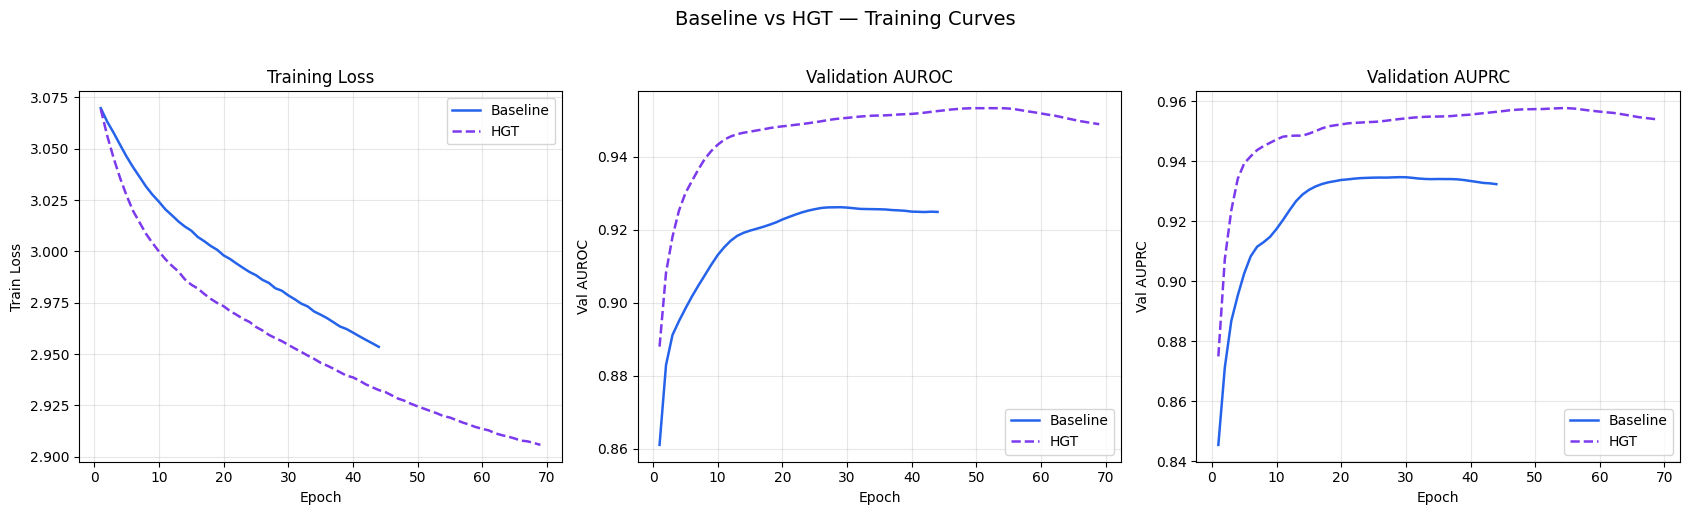

[Plot 5] Training curves overlay saved.

  BLOCK 09 COMPLETE
  Objects now available:
    binary_metrics    {model_name: {split: metrics_dict}}
    ranking_metrics   {model_name: metrics_dict}
    safety_metrics    {model_name: metrics_dict}
    comparison_df     full side-by-side DataFrame

  Figures saved to /mnt/data/:
    eval_roc_pr_curves.png
    eval_score_distributions.png
    eval_ranking_bars.png
    eval_training_curves_overlay.png


In [11]:
# Full Model Evaluation / Metrics

# Guards
assert "baseline_model"          in globals(), "Run Block 07 first."
assert "hgt_model"               in globals(), "Run Block 08 first."
assert "train_data"              in globals(), "Run Block 06 first."
assert "TARGET_EDGE_TRIPLET"     in globals(), "Run Block 06 first."
assert "all_positive_pairs"      in globals(), "Run Block 06 first."
assert "edges_model_ready_df"    in globals(), "Run Block 04 first."
assert "nodes_master_df"         in globals(), "Run Block 04 first."
assert "score_all_drugs_for_disease" in globals(), "Run Block 07 first."

device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_graph   = train_data.to(device)
SUP_EDGE_TYPE = TARGET_EDGE_TRIPLET
src_type, rel_type, dst_type = SUP_EDGE_TYPE

# Resolve supervision tensors
def _to_device(name):
    g = globals()
    t = g.get(name)
    return t.to(device) if (t is not None and torch.is_tensor(t)) else t

val_pos_ei  = _to_device("val_pos_edge_label_index")
val_neg_ei  = _to_device("val_neg_edge_label_index")
test_pos_ei = _to_device("test_pos_edge_label_index")
test_neg_ei = _to_device("test_neg_edge_label_index")

# Build contraindication index

_contra_df = edges_model_ready_df[
    edges_model_ready_df["edge_label"] == "contraindication"
].copy()
CONTRA_BY_DISEASE = defaultdict(set)
for _, row in _contra_df.iterrows():
    CONTRA_BY_DISEASE[int(row["dst_index"])].add(int(row["src_index"]))

# Build train positive index
TRAIN_POS_BY_DISEASE = defaultdict(set)
train_ei = train_graph[SUP_EDGE_TYPE].edge_index.cpu()
for drug_idx, dis_idx in zip(train_ei[0].tolist(), train_ei[1].tolist()):
    TRAIN_POS_BY_DISEASE[dis_idx].add(drug_idx)

print("Contraindication entries  :", sum(len(v) for v in CONTRA_BY_DISEASE.values()))
print("Train positive entries    :", sum(len(v) for v in TRAIN_POS_BY_DISEASE.values()))


# Section 1: binary classification metrics

def compute_binary_metrics(
    model,
    graph,
    pos_ei: torch.Tensor,
    neg_ei: torch.Tensor,
    edge_type: tuple,
) -> dict:
    """
    Full suite of binary classification metrics for a pos/neg split.

    Threshold is chosen to maximise F1 on the test set itself
    (this is fair because we are reporting, not selecting a model with it).

    Metrics included:
      AUROC          area under ROC — overall ranking quality
      AUPRC          area under PR curve — better for imbalanced sets
      Accuracy       raw fraction correct after thresholding
      Bal. Accuracy  average of sensitivity and specificity
      Precision      TP / (TP + FP)
      Recall         TP / (TP + FN)
      F1             harmonic mean of precision and recall
      MCC            Matthews Correlation Coefficient (-1 to 1)
      Log Loss       penalises confident wrong answers
      Brier Score    mean squared error of probabilities
      ECE            Expected Calibration Error (are probabilities trustworthy?)
    """
    model.eval()
    with torch.no_grad():
        z_dict     = model.encode(graph)
        pos_logits = model.decode(z_dict, pos_ei, edge_type=edge_type)
        neg_logits = model.decode(z_dict, neg_ei, edge_type=edge_type)

    pos_probs = torch.sigmoid(pos_logits).cpu().numpy()
    neg_probs = torch.sigmoid(neg_logits).cpu().numpy()
    y_score   = np.concatenate([pos_probs, neg_probs])
    y_true    = np.concatenate([np.ones(len(pos_probs)), np.zeros(len(neg_probs))])

    # Find the threshold that maximises F1
    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_true, y_score)
    with np.errstate(divide="ignore", invalid="ignore"):
        f1_arr = np.where(
            (prec_arr + rec_arr) > 0,
            2 * prec_arr * rec_arr / (prec_arr + rec_arr),
            0.0,
        )
    best_thresh = float(thresh_arr[np.argmax(f1_arr[:-1])])
    y_pred      = (y_score >= best_thresh).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

    frac_pos, mean_pred = calibration_curve(y_true, y_score, n_bins=10)
    ece = float(np.mean(np.abs(frac_pos - mean_pred)))

    return {
        "auroc":            float(roc_auc_score(y_true, y_score)),
        "auprc":            float(average_precision_score(y_true, y_score)),
        "accuracy":         float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy":float(balanced_accuracy_score(y_true, y_pred)),
        "precision":        float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":           float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":               float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc":              float(matthews_corrcoef(y_true, y_pred)),
        "log_loss":         float(log_loss(y_true, y_score)),
        "brier_score":      float(np.mean((y_score - y_true) ** 2)),
        "ece":              ece,
        "threshold":        best_thresh,
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "pos_mean_score":   float(pos_probs.mean()),
        "neg_mean_score":   float(neg_probs.mean()),
        "score_gap":        float(pos_probs.mean() - neg_probs.mean()),
    }


print("\nComputing binary metrics ...")
binary_metrics = {}
for model_name, model_obj in [("Baseline", baseline_model), ("HGT", hgt_model)]:
    binary_metrics[model_name] = {}
    for split, pos_ei, neg_ei in [
        ("val",  val_pos_ei,  val_neg_ei),
        ("test", test_pos_ei, test_neg_ei),
    ]:
        if pos_ei is not None:
            binary_metrics[model_name][split] = compute_binary_metrics(
                model_obj, train_graph, pos_ei, neg_ei, SUP_EDGE_TYPE
            )
            print(f"  {model_name:<10} [{split}]  "
                  f"AUROC={binary_metrics[model_name][split]['auroc']:.4f}  "
                  f"AUPRC={binary_metrics[model_name][split]['auprc']:.4f}  "
                  f"F1={binary_metrics[model_name][split]['f1']:.4f}")


# 2: ranking metrics

@torch.no_grad()
def compute_ranking_metrics(
    model,
    graph,
    test_pos_ei: torch.Tensor,
    k_values: list = None,
    forbidden_pairs: set = None,
) -> dict:
    """
    Evaluate ranking quality for all diseases in test_pos_ei.

    For each unique disease in the test split:
      1. Score all drugs (excluding training positives)
      2. Rank them descending
      3. Compute all K-dependent metrics

    Returns a flat dict of metric -> value.
    """
    if k_values is None:
        k_values = [1, 3, 5, 10, 20, 50]

    model.eval()
    num_drugs    = int(graph[src_type].num_nodes)
    num_diseases = int(graph[dst_type].num_nodes)
    model_device = next(model.parameters()).device

    # Build {disease_idx: set of test-positive drug indices}
    test_positives_by_disease = defaultdict(set)
    for drug_i, dis_i in zip(
        test_pos_ei[0].cpu().tolist(),
        test_pos_ei[1].cpu().tolist()
    ):
        test_positives_by_disease[dis_i].add(drug_i)

    # Only evaluate diseases that have at least one test positive
    eval_diseases = sorted(test_positives_by_disease.keys())

    # Accumulators
    hits        = {k: [] for k in k_values}
    recalls     = {k: [] for k in k_values}
    precisions  = {k: [] for k in k_values}
    ndcgs       = {k: [] for k in k_values}
    mrr_list    = []
    mean_ranks  = []

    for dis_idx in eval_diseases:
        true_drugs = test_positives_by_disease[dis_idx]

        # Score all drugs for this disease
        all_drug_t  = torch.arange(num_drugs, device=model_device)
        disease_t   = torch.full((num_drugs,), dis_idx, dtype=torch.long, device=model_device)
        cand_ei     = torch.stack([all_drug_t, disease_t], dim=0)

        z_dict  = model.encode(graph)
        logits  = model.decode(z_dict, cand_ei, edge_type=SUP_EDGE_TYPE)
        scores  = torch.sigmoid(logits).cpu().numpy()

        train_drugs = TRAIN_POS_BY_DISEASE.get(dis_idx, set())
        for d in train_drugs:
            scores[d] = -1.0

        # Sort descending: ranked_drugs[0] is the top candidate
        ranked_drugs = np.argsort(-scores)

        # Find the ranks of the true test-positive drugs
        true_ranks = []
        for drug_idx in true_drugs:
            rank = int(np.where(ranked_drugs == drug_idx)[0][0]) + 1  # 1-based
            true_ranks.append(rank)

        if not true_ranks:
            continue

        # MRR: 1 / rank of the first (highest-ranked) true drug
        mrr_list.append(1.0 / min(true_ranks))
        mean_ranks.append(float(np.mean(true_ranks)))

        # Compute K-dependent metrics
        for k in k_values:
            top_k_set = set(ranked_drugs[:k].tolist())

            # Hits@K: did at least one true drug land in top K?
            hit = int(len(top_k_set & true_drugs) > 0)
            hits[k].append(hit)

            # Recall@K: what fraction of true drugs are in top K?
            recall_k = len(top_k_set & true_drugs) / len(true_drugs)
            recalls[k].append(recall_k)

            # Precision@K: what fraction of top K are true drugs?
            prec_k = len(top_k_set & true_drugs) / k
            precisions[k].append(prec_k)

            # NDCG@K: position-weighted version of Recall@K
            relevance = np.array([
                1.0 if drug in true_drugs else 0.0
                for drug in ranked_drugs[:k]
            ])
            ideal = np.sort(relevance)[::-1]
            dcg   = sum(r / math.log2(i + 2) for i, r in enumerate(relevance))
            idcg  = sum(r / math.log2(i + 2) for i, r in enumerate(ideal))
            ndcgs[k].append(dcg / idcg if idcg > 0 else 0.0)

    # Aggregate
    result = {
        "n_diseases_eval": len(eval_diseases),
        "mrr":             float(np.mean(mrr_list))  if mrr_list  else 0.0,
        "mean_rank":       float(np.mean(mean_ranks)) if mean_ranks else 0.0,
        "median_rank":     float(np.median(mean_ranks)) if mean_ranks else 0.0,
    }
    for k in k_values:
        result[f"hits@{k}"]      = float(np.mean(hits[k]))       if hits[k]      else 0.0
        result[f"recall@{k}"]    = float(np.mean(recalls[k]))    if recalls[k]   else 0.0
        result[f"precision@{k}"] = float(np.mean(precisions[k])) if precisions[k] else 0.0
        result[f"ndcg@{k}"]      = float(np.mean(ndcgs[k]))      if ndcgs[k]     else 0.0

    return result


print("\nComputing ranking metrics ...")
ranking_metrics = {}
if test_pos_ei is not None:
    for model_name, model_obj in [("Baseline", baseline_model), ("HGT", hgt_model)]:
        ranking_metrics[model_name] = compute_ranking_metrics(
            model_obj, train_graph, test_pos_ei,
            k_values=[1, 3, 5, 10, 20, 50],
            forbidden_pairs=all_positive_pairs,
        )
        print(f"  {model_name:<10}  "
              f"MRR={ranking_metrics[model_name]['mrr']:.4f}  "
              f"Hits@10={ranking_metrics[model_name]['hits@10']:.4f}  "
              f"NDCG@10={ranking_metrics[model_name]['ndcg@10']:.4f}")
else:
    print("  test_pos_ei not found — skipping ranking metrics.")


#3: Safety diagnostics
@torch.no_grad()
def compute_safety_metrics(
    model,
    graph,
    test_pos_ei: torch.Tensor,
    top_k: int = 10,
) -> dict:
    """
    Leakage rate and contraindication rate at top_k recommendations.
    Lower is better for both.
    """
    model.eval()
    num_drugs    = int(graph[src_type].num_nodes)
    model_device = next(model.parameters()).device

    eval_diseases = sorted(set(test_pos_ei[1].cpu().tolist()))

    leakage_counts = []
    contra_counts  = []

    for dis_idx in eval_diseases:
        all_drug_t = torch.arange(num_drugs, device=model_device)
        disease_t  = torch.full((num_drugs,), dis_idx, dtype=torch.long, device=model_device)
        cand_ei    = torch.stack([all_drug_t, disease_t], dim=0)

        z_dict = model.encode(graph)
        logits = model.decode(z_dict, cand_ei, edge_type=SUP_EDGE_TYPE)
        scores = torch.sigmoid(logits).cpu().numpy()

        top_k_drugs = set(np.argsort(-scores)[:top_k].tolist())

        # Leakage: how many of top_k were seen as positive during training?
        leakage = len(top_k_drugs & TRAIN_POS_BY_DISEASE.get(dis_idx, set()))
        leakage_counts.append(leakage / top_k)

        # Contraindication: how many of top_k are contraindicated?
        contra = len(top_k_drugs & CONTRA_BY_DISEASE.get(dis_idx, set()))
        contra_counts.append(contra / top_k)

    return {
        f"leakage_rate@{top_k}": float(np.mean(leakage_counts)),
        f"contra_rate@{top_k}":  float(np.mean(contra_counts)),
        "n_diseases_eval":        len(eval_diseases),
    }


print("\nComputing safety metrics ...")
safety_metrics = {}
if test_pos_ei is not None:
    for model_name, model_obj in [("Baseline", baseline_model), ("HGT", hgt_model)]:
        safety_metrics[model_name] = compute_safety_metrics(
            model_obj, train_graph, test_pos_ei, top_k=10
        )
        sm = safety_metrics[model_name]
        print(f"  {model_name:<10}  "
              f"leakage@10={sm['leakage_rate@10']:.4f}  "
              f"contra@10={sm['contra_rate@10']:.4f}")


# Section 4: Comparison table

def _build_comparison_table() -> pd.DataFrame:
    """
    Assemble all metrics into a single wide comparison DataFrame.
    Rows = metric groups, Columns = Baseline / HGT (test split).
    """
    rows = []

    # --- Binary metrics ---
    for metric in [
        "auroc", "auprc", "f1", "mcc",
        "accuracy", "balanced_accuracy",
        "precision", "recall",
        "log_loss", "brier_score", "ece",
        "pos_mean_score", "neg_mean_score", "score_gap",
        "threshold",
    ]:
        row = {"Metric": metric, "Group": "Binary Classification"}
        for mn in ["Baseline", "HGT"]:
            v = binary_metrics.get(mn, {}).get("test", {}).get(metric, None)
            row[mn] = f"{v:.4f}" if isinstance(v, float) else str(v)
        rows.append(row)

    # --- Ranking metrics ---
    for metric in [
        "mrr", "mean_rank", "median_rank",
        "hits@1", "hits@3", "hits@5", "hits@10", "hits@20", "hits@50",
        "recall@10", "recall@50",
        "precision@10",
        "ndcg@10", "ndcg@50",
    ]:
        row = {"Metric": metric, "Group": "Ranking"}
        for mn in ["Baseline", "HGT"]:
            v = ranking_metrics.get(mn, {}).get(metric, None)
            row[mn] = f"{v:.4f}" if isinstance(v, float) else "N/A"
        rows.append(row)

    # --- Safety metrics ---
    for metric in ["leakage_rate@10", "contra_rate@10"]:
        row = {"Metric": metric, "Group": "Safety"}
        for mn in ["Baseline", "HGT"]:
            v = safety_metrics.get(mn, {}).get(metric, None)
            row[mn] = f"{v:.4f}" if isinstance(v, float) else "N/A"
        rows.append(row)

    return pd.DataFrame(rows).set_index(["Group", "Metric"])


comparison_df = _build_comparison_table()

print(f"\n{'='*55}")
print(f"  MODEL COMPARISON — TEST SPLIT")
print(f"{'='*55}")
pd.set_option("display.max_rows", 60)
display(comparison_df)


# 5: Visualisations

_COLORS = {"Baseline": "#2563eb", "HGT": "#7c3aed"}

# Get raw prob arrays for a model on test split
@torch.no_grad()
def _get_probs(model, pos_ei, neg_ei):
    model.eval()
    z    = model.encode(train_graph)
    pos_ = torch.sigmoid(model.decode(z, pos_ei, SUP_EDGE_TYPE)).cpu().numpy()
    neg_ = torch.sigmoid(model.decode(z, neg_ei, SUP_EDGE_TYPE)).cpu().numpy()
    y_s  = np.concatenate([pos_, neg_])
    y_t  = np.concatenate([np.ones(len(pos_)), np.zeros(len(neg_))])
    return y_t, y_s, pos_, neg_

# Plot 1: ROC curves
if test_pos_ei is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for model_name, model_obj in [("Baseline", baseline_model), ("HGT", hgt_model)]:
        y_t, y_s, _, _ = _get_probs(model_obj, test_pos_ei, test_neg_ei)
        fpr, tpr, _    = roc_curve(y_t, y_s)
        auc_val        = binary_metrics[model_name]["test"]["auroc"]
        axes[0].plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.3f})",
                     color=_COLORS[model_name], linewidth=2)

    axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve — Test Split")
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Precision-Recall curves
    for model_name, model_obj in [("Baseline", baseline_model), ("HGT", hgt_model)]:
        y_t, y_s, _, _ = _get_probs(model_obj, test_pos_ei, test_neg_ei)
        prec, rec, _   = precision_recall_curve(y_t, y_s)
        ap             = binary_metrics[model_name]["test"]["auprc"]
        axes[1].plot(rec, prec, label=f"{model_name} (AP={ap:.3f})",
                     color=_COLORS[model_name], linewidth=2)

    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve — Test Split")
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/mnt/data/eval_roc_pr_curves.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("[Plot 1+2] ROC and PR curves saved.")

# Plot 3: Score distribution histograms
if test_pos_ei is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, (model_name, model_obj) in zip(
        axes, [("Baseline", baseline_model), ("HGT", hgt_model)]
    ):
        _, _, pos_p, neg_p = _get_probs(model_obj, test_pos_ei, test_neg_ei)
        ax.hist(neg_p, bins=50, alpha=0.6, color="#ef4444", label="Negative pairs", density=True)
        ax.hist(pos_p, bins=50, alpha=0.6, color="#22c55e", label="Positive pairs", density=True)
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Density")
        ax.set_title(f"{model_name} — Score Distributions")
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/mnt/data/eval_score_distributions.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("[Plot 3] Score distribution histograms saved.")

# Plot 4: Hits@K bar chart
if ranking_metrics:
    k_values_plot = [1, 3, 5, 10, 20, 50]
    x   = np.arange(len(k_values_plot))
    w   = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric_prefix, ylabel in [
        (axes[0], "hits@",  "Hits@K"),
        (axes[1], "ndcg@",  "NDCG@K"),
    ]:
        for i, (model_name, _) in enumerate(
            [("Baseline", None), ("HGT", None)]
        ):
            vals = [
                ranking_metrics.get(model_name, {}).get(f"{metric_prefix}{k}", 0.0)
                for k in k_values_plot
            ]
            ax.bar(x + i * w, vals, w, label=model_name,
                   color=_COLORS[model_name], alpha=0.85)

        ax.set_xticks(x + w / 2)
        ax.set_xticklabels([f"@{k}" for k in k_values_plot])
        ax.set_xlabel("K"); ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} — Baseline vs HGT")
        ax.legend(); ax.grid(True, alpha=0.3, axis="y")
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

    plt.tight_layout()
    plt.savefig("/mnt/data/eval_ranking_bars.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("[Plot 4] Hits@K and NDCG@K bar charts saved.")

# Plot 5: Training curves overlay (Baseline vs HGT)
if "baseline_history_df" in globals() and "hgt_history_df" in globals():
    bdf = baseline_history_df
    hdf = hgt_history_df

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Loss
    axes[0].plot(bdf["epoch"], bdf["train_loss"], color=_COLORS["Baseline"],
                 linewidth=1.8, label="Baseline")
    axes[0].plot(hdf["epoch"], hdf["train_loss"], color=_COLORS["HGT"],
                 linewidth=1.8, linestyle="--", label="HGT")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train Loss")
    axes[0].set_title("Training Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Val AUROC
    if "val_auroc" in bdf.columns and "val_auroc" in hdf.columns:
        axes[1].plot(bdf["epoch"], bdf["val_auroc"], color=_COLORS["Baseline"],
                     linewidth=1.8, label="Baseline")
        axes[1].plot(hdf["epoch"], hdf["val_auroc"], color=_COLORS["HGT"],
                     linewidth=1.8, linestyle="--", label="HGT")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val AUROC")
        axes[1].set_title("Validation AUROC"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Val AUPRC
    if "val_auprc" in bdf.columns and "val_auprc" in hdf.columns:
        axes[2].plot(bdf["epoch"], bdf["val_auprc"], color=_COLORS["Baseline"],
                     linewidth=1.8, label="Baseline")
        axes[2].plot(hdf["epoch"], hdf["val_auprc"], color=_COLORS["HGT"],
                     linewidth=1.8, linestyle="--", label="HGT")
        axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val AUPRC")
        axes[2].set_title("Validation AUPRC"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle("Baseline vs HGT — Training Curves", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("/mnt/data/eval_training_curves_overlay.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("[Plot 5] Training curves overlay saved.")


# Summary
print(f"\n{'='*55}")
print(f"  BLOCK 09 COMPLETE")
print(f"{'='*55}")
print("  Objects now available:")
print("    binary_metrics    {model_name: {split: metrics_dict}}")
print("    ranking_metrics   {model_name: metrics_dict}")
print("    safety_metrics    {model_name: metrics_dict}")
print("    comparison_df     full side-by-side DataFrame")
print()
print("  Figures saved to /mnt/data/:")
print("    eval_roc_pr_curves.png")
print("    eval_score_distributions.png")
print("    eval_ranking_bars.png")
print("    eval_training_curves_overlay.png")
print(f"{'='*55}")

## 10. Extract evidence and perform safety reasoning

This block adds an interpretation layer on top of the model predictions. Up to this point, the notebook has trained GNN models that can score drug–disease pairs, but a high model score alone is not enough for a repurposing recommendation. To make the predictions more useful and explainable, this block extracts structured graph evidence that can support a drug candidate and also checks for safety-related warning signals.

### 1. Build node name lookups

The block starts by creating fast lookup dictionaries that map node indices back to readable names and raw IDs. These are built mainly from `nodes_master_df`, which was created earlier as the unified node table.

This is necessary because most of the graph logic in the notebook works with integer node indices for efficiency, but later evidence tables and explanations need human-readable labels such as disease names, protein names, and drug names.

The code also supplements the lookup from the edge table in case any nodes are missing from the first pass. By the end of this step, helper functions such as `get_node_name(...)` can convert graph indices into readable display names.

### 2. Detect important edge type groups

Since the graph is heterogeneous and contains many relation types, the block next identifies which edge types belong to which biological role. Instead of hard-coding everything in one place, it groups edge types into categories such as:

- drug–protein relations
- disease–protein relations
- protein–protein interaction edges
- disease–disease hierarchy or similarity edges
- disease–phenotype relations
- drug–effect or side-effect relations
- contraindication edges
- therapeutic indication edges

### 3. Build adjacency indexes for the graph

After identifying the edge groups, the block constructs adjacency dictionaries from the training graph. These indexes are built in both directions:

- **outgoing adjacency**
- **incoming adjacency**


### 4. Build therapeutic lookup tables from training data

The block then creates two lookup structures from the training indication edges:

- **`TRAIN_THERAPEUTIC_BY_DISEASE`**: maps each disease to the drugs already known to treat it
- **`TRAIN_DISEASES_BY_DRUG`**: maps each drug to the diseases it already treats

These lookups are used later for two main reasons:

- to identify what a drug is already known to treat
- to support disease-to-disease transfer evidence, where a drug may be considered plausible for a query disease because it already treats a biologically related disease

This gives the later reranking steps an explicit way to connect repurposing suggestions to existing therapeutic knowledge in the graph.

### 5. Define a model-scoring helper

Before extracting evidence, the block defines a helper function called `score_all_drugs_for_disease(...)`. This function uses the selected trained model, either the baseline model or the HGT model, to score all drug candidates for a chosen disease.

The result is a ranked dataframe of candidate drugs with their raw model scores. This is useful because the notebook does not want to explain every possible drug. Instead, it first uses the trained model to identify promising candidates and then attaches evidence and safety analysis to those candidates.

### 6. Extract supportive evidence paths

This is the core evidence-building section of the block. It defines the graph patterns that count as possible supporting evidence for a drug–disease recommendation.

#### Shared protein bridge

This captures cases where:
- a drug connects to a protein
- the disease is also associated with that same protein

This is one of the strongest and most direct evidence types because it suggests a shared molecular target or mechanism.

Conceptually, the pattern is:

**drug → protein ← disease**

#### PPI bridge

This captures indirect molecular support through the protein–protein interaction network. In this case:
- the drug connects to protein A
- protein A interacts with protein B
- the disease is associated with protein B

This provides a less direct but still biologically meaningful connection between the drug and disease.

Conceptually, the pattern is:

**drug → protein A — PPI — protein B ← disease**

#### Disease-to-disease transfer evidence

This looks for diseases related to the query disease through ontology or disease hierarchy edges and then checks whether the candidate drug already treats one of those related diseases.

This supports the idea of repurposing through disease similarity: if a drug already treats a related condition, it may also be relevant for the query disease.

Conceptually, the pattern is:

**drug → related disease ← disease hierarchy → query disease**

#### Effect or phenotype overlap

This checks whether:
- the drug connects to a phenotype or effect
- the disease also connects to the same phenotype

This is used as another form of evidence suggesting that the drug may interact with biology relevant to the disease presentation.

Conceptually, the pattern is:

**drug → phenotype/effect ← disease**

Together, these extractors build a broader evidence picture rather than relying on only one mechanistic route.

### 7. Extract safety signals

In addition to supportive evidence, the block also searches for graph patterns that may indicate risk.

#### Direct contraindication

This is the clearest safety warning. If the graph already contains a contraindication edge between the candidate drug and the disease, that is treated as a strong negative signal.

Conceptually:

**drug — contraindication → disease**

#### Adverse effect overlap

This safety pattern checks whether:
- the drug has a known adverse effect
- the disease is associated with the same phenotype or symptom

This can indicate that the drug may worsen or conflict with the disease state.

Conceptually:

**drug → adverse effect ← disease phenotype**

These safety signals are not necessarily used to reject a candidate automatically, but they become important penalties or flags in the later reranking blocks.

### 8. Build the main evidence bundle

After defining all evidence and safety extractors, the block combines them into a main wrapper function called `extract_evidence_bundle(...)`.

Given a disease and a candidate drug, this function collects:
- supportive evidence paths
- safety signals
- metadata such as node names and edge details
- counts and summaries that are easier to use later

This evidence bundle acts as a structured package containing the full reasoning context for a recommendation.

The block also defines helper functions to convert the bundle into more usable forms:

- **`evidence_bundle_to_tables(bundle)`** converts the bundle into clean evidence and safety dataframes
- **`bundle_to_rag_json(bundle)`** converts the bundle into a JSON-ready format that can later be passed into a reporting or explanation system

### 9. Run Demo

At the end of the block, a small demo section tests the evidence extraction pipeline on a sample disease query and top-ranked candidate drugs. This helps verify that the functions work correctly and gives an early preview of the kind of evidence that will later appear in the final recommendation tables and explanation outputs.

In [12]:
# Evidence Extraction & Safety Reasoning

# Guards
assert "train_data"         in globals(), "Run Block 06 first."
assert "TARGET_EDGE_TRIPLET" in globals(), "Run Block 06 first."
assert "nodes_master_df"    in globals(), "Run Block 04 first."
assert "baseline_model"     in globals() or "hgt_model" in globals(), \
    "Run Block 07 (baseline) or Block 08 (HGT) first."

graph         = train_data
SUP_EDGE_TYPE = TARGET_EDGE_TRIPLET
SUP_SRC_TYPE, SUP_REL_TYPE, SUP_DST_TYPE = SUP_EDGE_TYPE

if "hgt_model" in globals():
    evidence_model      = hgt_model
    EVIDENCE_MODEL_NAME = "HGT"
else:
    evidence_model      = baseline_model
    EVIDENCE_MODEL_NAME = "Baseline"

print(f"Evidence model    : {EVIDENCE_MODEL_NAME}")
print(f"Supervision edge  : {SUP_EDGE_TYPE}")


# 1. Node name lookup

_NODE_NAME_LOOKUP: dict[tuple, str] = {}
_NODE_ID_LOOKUP:   dict[tuple, str] = {}

for _, row in nodes_master_df.iterrows():
    ntype = str(row["node_type"]).strip().lower()
    nidx  = int(row["node_index_within_type"])
    name  = str(row.get("node_name", "")).strip()
    raw_id = str(row.get("node_id_raw", "")).strip()
    if name:
        _NODE_NAME_LOOKUP[(ntype, nidx)] = name
    if raw_id:
        _NODE_ID_LOOKUP[(ntype, nidx)] = raw_id

# Supplement from edge table if any nodes were missed
for col_prefix in [("src", "src_index"), ("dst", "dst_index")]:
    prefix, idx_col = col_prefix
    for _, row in edges_model_ready_df.iterrows():
        ntype = str(row[f"{prefix}_type"]).strip().lower()
        nidx  = int(row[idx_col])
        name  = str(row.get(f"{prefix}_name", "")).strip()
        if name and (ntype, nidx) not in _NODE_NAME_LOOKUP:
            _NODE_NAME_LOOKUP[(ntype, nidx)] = name

def get_node_name(node_type: str, node_idx: int) -> str:
    """
    Return 'DisplayName (type_idx)' for a node.
    Raises KeyError if no name is found — this should never happen
    if nodes_master_df covers all nodes.
    """
    key = (str(node_type).strip().lower(), int(node_idx))
    name = _NODE_NAME_LOOKUP.get(key)
    if not name:
        raise KeyError(f"No name found for {key}. Check nodes_master_df coverage.")
    return f"{name} ({node_type}_{node_idx})"

def get_node_id(node_type: str, node_idx: int):
    """Return the raw database ID (e.g. DrugBank ID) for a node."""
    key = (str(node_type).strip().lower(), int(node_idx))
    return _NODE_ID_LOOKUP.get(key)

# Coverage check — drugs and diseases must be fully covered
_coverage = []
for ntype in graph.node_types:
    n       = int(graph[ntype].num_nodes)
    found   = sum((ntype.lower(), i) in _NODE_NAME_LOOKUP for i in range(n))
    _coverage.append({"node_type": ntype, "num_nodes": n,
                       "names_found": found,
                       "coverage_pct": round(100.0 * found / max(n, 1), 2)})

node_name_coverage_df = pd.DataFrame(_coverage)
print("\nNode-name coverage:")
display(node_name_coverage_df)

for core_t in [SUP_SRC_TYPE, SUP_DST_TYPE]:
    row = node_name_coverage_df[node_name_coverage_df["node_type"] == core_t]
    assert len(row) > 0 and int(row["names_found"].iloc[0]) > 0, \
        f"No names found for required type: {core_t}"


# 2. Edge type group detection

def _norm(s: str) -> str:
    return str(s).lower().replace("-", "_").replace(" ", "_")

def _type_has(node_type: str, keys: list) -> bool:
    t = _norm(node_type)
    return any(k in t for k in keys)

def _rel_has(relation: str, keys: list) -> bool:
    r = _norm(relation)
    return any(k in r for k in keys)

def _find_edge_types(src_keys, dst_keys, rel_keys=None, allow_reverse=False):
    """Return edge types matching src_keys on source, dst_keys on dest."""
    found = []
    for et in graph.edge_types:
        s, r, d = et
        s_ok = _type_has(s, src_keys)
        d_ok = _type_has(d, dst_keys)
        r_ok = True if rel_keys is None else _rel_has(r, rel_keys)
        if s_ok and d_ok and r_ok:
            found.append(et)
        elif allow_reverse and _type_has(s, dst_keys) and _type_has(d, src_keys) and r_ok:
            found.append(et)
    return found

_DRUG_K    = ["drug", "compound"]
_DIS_K     = ["disease", "disorder"]
_PROT_K    = ["protein", "gene"]
_PHENO_K   = ["phenotype", "effect", "symptom", "adverse"]

drug_protein_edge_types    = _find_edge_types(_DRUG_K, _PROT_K, None, allow_reverse=True)
disease_protein_edge_types = _find_edge_types(_DIS_K,  _PROT_K, None, allow_reverse=True)
ppi_edge_types             = _find_edge_types(_PROT_K, _PROT_K, ["ppi", "interact"])
disease_disease_edge_types = _find_edge_types(_DIS_K,  _DIS_K,  None)
drug_effect_edge_types     = _find_edge_types(_DRUG_K, _PHENO_K, None, allow_reverse=True)
disease_effect_edge_types  = _find_edge_types(_DIS_K,  _PHENO_K, None, allow_reverse=True)
contra_edge_types          = _find_edge_types(_DRUG_K, _DIS_K, ["contra"], allow_reverse=True)

# The supervision edge is always a therapeutic edge
therapeutic_edge_types = list({SUP_EDGE_TYPE})

print("\nDetected edge type groups:")
for name, ets in [
    ("drug_protein",    drug_protein_edge_types),
    ("disease_protein", disease_protein_edge_types),
    ("ppi",             ppi_edge_types),
    ("disease_disease", disease_disease_edge_types),
    ("drug_effect",     drug_effect_edge_types),
    ("disease_effect",  disease_effect_edge_types),
    ("contraindication",contra_edge_types),
    ("therapeutic",     therapeutic_edge_types),
]:
    print(f"  {name:<18}: {len(ets)} edge types")


# 3. Adjacency indexes

EDGE_INDEX_OUT: dict = {}   # {edge_type: {src_idx: [dst_idx, ...]}}
EDGE_INDEX_IN:  dict = {}   # {edge_type: {dst_idx: [src_idx, ...]}}

for et in graph.edge_types:
    ei      = graph[et].edge_index.detach().cpu()
    out_map = defaultdict(list)
    in_map  = defaultdict(list)
    for s, d in ei.t().tolist():
        out_map[int(s)].append(int(d))
        in_map[int(d)].append(int(s))
    EDGE_INDEX_OUT[et] = out_map
    EDGE_INDEX_IN[et]  = in_map

def get_neighbors(node_type: str, node_idx: int,
                  edge_types: list = None) -> list:
    """
    Return list of {neighbor_type, neighbor_idx, relation, direction}
    for all edges incident to (node_type, node_idx).
    """
    rows = []
    node_idx = int(node_idx)
    for et in (edge_types or graph.edge_types):
        s_type, rel, d_type = et
        if node_type == s_type:
            for nbr in EDGE_INDEX_OUT[et].get(node_idx, []):
                rows.append({"neighbor_type": d_type, "neighbor_idx": int(nbr),
                              "relation": rel, "edge_type": et, "direction": "out"})
        if node_type == d_type:
            for nbr in EDGE_INDEX_IN[et].get(node_idx, []):
                rows.append({"neighbor_type": s_type, "neighbor_idx": int(nbr),
                              "relation": rel, "edge_type": et, "direction": "in"})
    return rows

def shared_intermediates(left_type, left_idx, right_type, right_idx,
                         left_ets, right_ets, allowed_type_keys=None, top_n=5):
    """
    Find nodes that are neighbors of both (left_type, left_idx) and
    (right_type, right_idx) via their respective edge type sets.
    Returns up to top_n shared intermediate node records.
    """
    left_nbrs  = get_neighbors(left_type,  left_idx,  left_ets)
    right_nbrs = get_neighbors(right_type, right_idx, right_ets)

    if allowed_type_keys:
        left_nbrs  = [r for r in left_nbrs  if _type_has(r["neighbor_type"], allowed_type_keys)]
        right_nbrs = [r for r in right_nbrs if _type_has(r["neighbor_type"], allowed_type_keys)]

    left_map  = defaultdict(list)
    right_map = defaultdict(list)
    for r in left_nbrs:
        left_map[(r["neighbor_type"], int(r["neighbor_idx"]))].append(r)
    for r in right_nbrs:
        right_map[(r["neighbor_type"], int(r["neighbor_idx"]))].append(r)

    shared = list(set(left_map) & set(right_map))[:top_n]
    out = []
    for key in shared:
        interm_type, interm_idx = key
        l = left_map[key][0]
        r = right_map[key][0]
        out.append({
            "intermediate_type": interm_type,
            "intermediate_idx":  int(interm_idx),
            "intermediate_name": get_node_name(interm_type, interm_idx),
            "left_relation":     l["relation"],
            "right_relation":    r["relation"],
        })
    return out


# 4. Training therapeutic lookups

TRAIN_THERAPEUTIC_BY_DISEASE: dict[int, set] = defaultdict(set)
TRAIN_DISEASES_BY_DRUG:       dict[int, set] = defaultdict(set)

ei_train = graph[SUP_EDGE_TYPE].edge_index.detach().cpu()
for drug_idx, dis_idx in ei_train.t().tolist():
    TRAIN_THERAPEUTIC_BY_DISEASE[int(dis_idx)].add(int(drug_idx))
    TRAIN_DISEASES_BY_DRUG[int(drug_idx)].add(int(dis_idx))

print(f"\nTraining therapeutic pairs : {sum(len(v) for v in TRAIN_THERAPEUTIC_BY_DISEASE.values()):,}")


# 5. Model scoring helper

@torch.no_grad()
def score_all_drugs_for_disease(model, graph, disease_idx: int,
                                edge_type: tuple = None) -> pd.DataFrame:
    """
    Score every drug against one disease using the model.
    Returns DataFrame[drug_idx, score] sorted descending.
    """
    if edge_type is None:
        edge_type = model.supervision_edge_type
    s_type, _, d_type = edge_type
    dev  = next(model.parameters()).device
    n    = int(graph[s_type].num_nodes)
    ei   = torch.stack([
        torch.arange(n, device=dev),
        torch.full((n,), disease_idx, dtype=torch.long, device=dev)
    ])
    model.eval()
    z    = model.encode(graph.to(dev))
    logits = model.decode(z, ei, edge_type=edge_type)
    scores = torch.sigmoid(logits).cpu().numpy()
    return (pd.DataFrame({"drug_idx": np.arange(n), "score": scores})
              .sort_values("score", ascending=False)
              .reset_index(drop=True))

@torch.no_grad()
def score_pair(model, graph, drug_idx: int, disease_idx: int) -> float:
    """Score a single (drug, disease) pair."""
    dev = next(model.parameters()).device
    ei  = torch.tensor([[drug_idx], [disease_idx]], dtype=torch.long, device=dev)
    model.eval()
    z   = model.encode(graph.to(dev))
    return float(torch.sigmoid(model.decode(z, ei)).item())


# 6. Evidence extractors

def _fmt_path(*parts) -> str:
    """Format a path as 'A --[rel]--> B ...' string."""
    return " ".join(str(p) for p in parts)

def extract_shared_protein_evidence(drug_idx: int, disease_idx: int,
                                    top_n: int = 5) -> list:
    """
    Find proteins targeted by the drug that are also associated with
    the disease.  This is the strongest mechanistic evidence type —
    it shows the drug acts on a biological target directly relevant
    to the disease.
    """
    rows = shared_intermediates(
        SUP_SRC_TYPE, drug_idx,
        SUP_DST_TYPE, disease_idx,
        drug_protein_edge_types, disease_protein_edge_types,
        allowed_type_keys=_PROT_K, top_n=top_n,
    )
    out = []
    for r in rows:
        out.append({
            "evidence_type":      "shared_protein_bridge",
            "drug_idx":           int(drug_idx),
            "disease_idx":        int(disease_idx),
            "intermediate_type":  r["intermediate_type"],
            "intermediate_idx":   r["intermediate_idx"],
            "intermediate_name":  r["intermediate_name"],
            "path_text": _fmt_path(
                get_node_name(SUP_SRC_TYPE, drug_idx),
                f"--[{r['left_relation']}]-->",
                r["intermediate_name"],
                f"<--[{r['right_relation']}]--",
                get_node_name(SUP_DST_TYPE, disease_idx),
            ),
            "score_hint": 3.0,
        })
    return out


def extract_ppi_bridge_evidence(drug_idx: int, disease_idx: int,
                                top_n: int = 5) -> list:
    """
    Find 2-hop protein paths: drug → protein A — PPI — protein B ← disease.
    The PPI hop extends the drug's reach to proteins it doesn't directly
    target but is functionally connected to through the interaction network.
    """
    drug_prots    = [r for r in get_neighbors(SUP_SRC_TYPE, drug_idx, drug_protein_edge_types)
                     if _type_has(r["neighbor_type"], _PROT_K)]
    disease_prots = {(r["neighbor_type"], int(r["neighbor_idx"])): r["relation"]
                     for r in get_neighbors(SUP_DST_TYPE, disease_idx, disease_protein_edge_types)
                     if _type_has(r["neighbor_type"], _PROT_K)}

    out  = []
    seen = set()

    for dp in drug_prots:
        p1_type, p1_idx = dp["neighbor_type"], int(dp["neighbor_idx"])
        for et in ppi_edge_types:
            s_t, rel, d_t = et
            if p1_type == s_t:
                nbrs     = EDGE_INDEX_OUT[et].get(p1_idx, [])
                nbr_type = d_t
            elif p1_type == d_t:
                nbrs     = EDGE_INDEX_IN[et].get(p1_idx, [])
                nbr_type = s_t
            else:
                continue

            for p2_idx in nbrs:
                key = (nbr_type, int(p2_idx))
                if key not in disease_prots or (p1_idx, p2_idx) in seen:
                    continue
                seen.add((p1_idx, p2_idx))
                out.append({
                    "evidence_type":      "ppi_bridge",
                    "drug_idx":           int(drug_idx),
                    "disease_idx":        int(disease_idx),
                    "intermediate_type":  nbr_type,
                    "intermediate_idx":   int(p2_idx),
                    "intermediate_name":  get_node_name(nbr_type, p2_idx),
                    "path_text": _fmt_path(
                        get_node_name(SUP_SRC_TYPE, drug_idx),
                        f"--[{dp['relation']}]-->",
                        get_node_name(p1_type, p1_idx),
                        f"--[{rel}]-->",
                        get_node_name(nbr_type, p2_idx),
                        f"<--[{disease_prots[key]}]--",
                        get_node_name(SUP_DST_TYPE, disease_idx),
                    ),
                    "score_hint": 2.5,
                })
                if len(out) >= top_n:
                    return out
    return out


def extract_disease_transfer_evidence(drug_idx: int, disease_idx: int,
                                      top_n: int = 5) -> list:
    """
    If the drug treats a related disease D', and D' is connected to the
    query disease in the disease hierarchy, infer a repurposing rationale.
    This is 'guilt by association' at the disease level.
    """
    out  = []
    seen = set()

    for other_dis in sorted(TRAIN_DISEASES_BY_DRUG.get(int(drug_idx), set())):
        for et in disease_disease_edge_types:
            s_t, rel, d_t = et
            if not (_type_has(s_t, _DIS_K) and _type_has(d_t, _DIS_K)):
                continue
            connected = (
                disease_idx in EDGE_INDEX_OUT[et].get(other_dis, []) or
                disease_idx in EDGE_INDEX_IN[et].get(other_dis, [])
            )
            if connected and (other_dis, rel) not in seen:
                seen.add((other_dis, rel))
                out.append({
                    "evidence_type":       "disease_disease_transfer",
                    "drug_idx":            int(drug_idx),
                    "disease_idx":         int(disease_idx),
                    "similar_disease_idx": int(other_dis),
                    "similar_disease_name": get_node_name(SUP_DST_TYPE, other_dis),
                    "path_text": _fmt_path(
                        get_node_name(SUP_SRC_TYPE, drug_idx),
                        "--[known treatment]-->",
                        get_node_name(SUP_DST_TYPE, other_dis),
                        f"--[{rel}]-->",
                        get_node_name(SUP_DST_TYPE, disease_idx),
                    ),
                    "score_hint": 2.2,
                })
                if len(out) >= top_n:
                    return out
    return out


def extract_effect_overlap_evidence(drug_idx: int, disease_idx: int,
                                    top_n: int = 5) -> list:
    """
    Find phenotypes / effects shared between the drug's known side effects
    and the disease's known phenotypes.  A drug that produces some of the
    same phenotypic effects as the disease does may be modulating a relevant
    pathway.
    """
    rows = shared_intermediates(
        SUP_SRC_TYPE, drug_idx,
        SUP_DST_TYPE, disease_idx,
        drug_effect_edge_types, disease_effect_edge_types,
        allowed_type_keys=_PHENO_K, top_n=top_n,
    )
    return [{
        "evidence_type":     "effect_or_phenotype_overlap",
        "drug_idx":          int(drug_idx),
        "disease_idx":       int(disease_idx),
        "intermediate_type": r["intermediate_type"],
        "intermediate_idx":  r["intermediate_idx"],
        "intermediate_name": r["intermediate_name"],
        "path_text": _fmt_path(
            get_node_name(SUP_SRC_TYPE, drug_idx),
            f"--[{r['left_relation']}]-->",
            r["intermediate_name"],
            f"<--[{r['right_relation']}]--",
            get_node_name(SUP_DST_TYPE, disease_idx),
        ),
        "score_hint": 1.5,
    } for r in rows]


# 7. Safety extractors

def extract_contraindications(drug_idx: int, disease_idx: int) -> list:
    """
    Check whether the graph contains a direct contraindication edge
    between this drug and this disease.  A high-severity safety signal.
    """
    out = []
    for et in contra_edge_types:
        s_t, rel, d_t = et
        hit = False
        if s_t == SUP_SRC_TYPE and d_t == SUP_DST_TYPE:
            hit = disease_idx in EDGE_INDEX_OUT[et].get(drug_idx, [])
        elif d_t == SUP_SRC_TYPE and s_t == SUP_DST_TYPE:
            hit = disease_idx in EDGE_INDEX_IN[et].get(drug_idx, [])
        if hit:
            out.append({
                "safety_type": "direct_contraindication",
                "severity":    "high",
                "relation":    rel,
                "text": (
                    f"Direct contraindication: "
                    f"{get_node_name(SUP_SRC_TYPE, drug_idx)} "
                    f"--[{rel}]-- "
                    f"{get_node_name(SUP_DST_TYPE, disease_idx)}"
                ),
            })
    return out


def extract_adverse_overlap(drug_idx: int, disease_idx: int,
                            top_n: int = 5) -> list:
    """
    Flag phenotypes that are both drug side effects and disease phenotypes.
    Giving a drug whose side effects mimic the disease's symptoms could
    worsen the patient's condition.
    """
    rows = shared_intermediates(
        SUP_SRC_TYPE, drug_idx,
        SUP_DST_TYPE, disease_idx,
        drug_effect_edge_types, disease_effect_edge_types,
        allowed_type_keys=_PHENO_K, top_n=top_n,
    )
    return [{
        "safety_type": "adverse_effect_overlap",
        "severity":    "medium",
        "relation":    f"{r['left_relation']} / {r['right_relation']}",
        "text": (
            f"Phenotype/effect overlap: {r['intermediate_name']} — "
            f"drug via [{r['left_relation']}], disease via [{r['right_relation']}]"
        ),
    } for r in rows]


def _risk_level(safety_rows: list) -> str:
    """Summarise overall risk from a list of safety records."""
    if not safety_rows:
        return "low"
    return "high" if any(r["severity"] == "high" for r in safety_rows) else "medium"


# 8. Main evidence bundle

def extract_evidence_bundle(drug_idx: int, disease_idx: int,
                             model=None, top_n_each: int = 5) -> dict:
    """
    Run all four evidence extractors + two safety extractors for a single
    (drug, disease) pair.

    Returns a structured dict with:
      drug/disease metadata, model score, evidence rows, safety rows,
      evidence count summary, and a risk level string.
    """
    if model is None:
        model = evidence_model

    drug_idx    = int(drug_idx)
    disease_idx = int(disease_idx)
    pred_score  = score_pair(model, graph, drug_idx, disease_idx)

    # Collect and rank evidence by score_hint
    evidence_rows = sorted(
        extract_shared_protein_evidence(drug_idx, disease_idx, top_n_each) +
        extract_ppi_bridge_evidence(drug_idx, disease_idx, top_n_each) +
        extract_disease_transfer_evidence(drug_idx, disease_idx, top_n_each) +
        extract_effect_overlap_evidence(drug_idx, disease_idx, top_n_each),
        key=lambda r: r.get("score_hint", 0.0), reverse=True,
    )
    safety_rows = (
        extract_contraindications(drug_idx, disease_idx) +
        extract_adverse_overlap(drug_idx, disease_idx, top_n_each)
    )

    return {
        "drug_idx":      drug_idx,
        "drug_name":     get_node_name(SUP_SRC_TYPE, drug_idx),
        "drug_id":       get_node_id(SUP_SRC_TYPE, drug_idx),
        "drug_type":     SUP_SRC_TYPE,
        "disease_idx":   disease_idx,
        "disease_name":  get_node_name(SUP_DST_TYPE, disease_idx),
        "disease_id":    get_node_id(SUP_DST_TYPE, disease_idx),
        "disease_type":  SUP_DST_TYPE,
        "model_name":    EVIDENCE_MODEL_NAME,
        "pred_score":    float(pred_score),
        "evidence_counts": dict(Counter(r["evidence_type"] for r in evidence_rows)),
        "n_evidence_rows": len(evidence_rows),
        "n_safety_flags":  len(safety_rows),
        "risk_level":      _risk_level(safety_rows),
        "evidence_rows":   evidence_rows,
        "safety_rows":     safety_rows,
    }


def evidence_bundle_to_tables(bundle: dict):
    """Split a bundle into (evidence_df, safety_df) DataFrames."""
    ev_df = pd.DataFrame(bundle["evidence_rows"]) if bundle["evidence_rows"] else \
            pd.DataFrame(columns=["evidence_type", "intermediate_name",
                                  "similar_disease_name", "path_text", "score_hint"])
    sf_df = pd.DataFrame(bundle["safety_rows"]) if bundle["safety_rows"] else \
            pd.DataFrame(columns=["safety_type", "severity", "relation", "text"])
    return ev_df, sf_df


def bundle_to_rag_json(bundle: dict) -> dict:
    """Return a JSON-serialisable version of a bundle for LLM prompting."""
    return {
        "drug":    {"idx": bundle["drug_idx"],    "name": bundle["drug_name"],
                    "id":  bundle["drug_id"],     "type": bundle["drug_type"]},
        "disease": {"idx": bundle["disease_idx"], "name": bundle["disease_name"],
                    "id":  bundle["disease_id"],  "type": bundle["disease_type"]},
        "model_name":      bundle["model_name"],
        "pred_score":      bundle["pred_score"],
        "risk_level":      bundle["risk_level"],
        "evidence_counts": bundle["evidence_counts"],
        "evidence":        bundle["evidence_rows"],
        "safety":          bundle["safety_rows"],
    }


# 9. Quick demo

# Pick the first test-positive disease as demo target
_demo_ei  = globals().get("test_pos_edge_label_index")
_demo_dis = int(_demo_ei[1, 0].item()) if _demo_ei is not None else 0

print(f"\nDemo disease index : {_demo_dis}")
print(f"Demo disease name  : {get_node_name(SUP_DST_TYPE, _demo_dis)}")

# Suppress known train drugs so recommendations are novel
_demo_raw  = score_all_drugs_for_disease(evidence_model, graph, _demo_dis)
_train_known = TRAIN_THERAPEUTIC_BY_DISEASE.get(_demo_dis, set())
_demo_raw  = _demo_raw[~_demo_raw["drug_idx"].isin(_train_known)].head(5)

_demo_bundle = extract_evidence_bundle(
    int(_demo_raw.iloc[0]["drug_idx"]), _demo_dis,
    model=evidence_model, top_n_each=5,
)
_ev_df, _sf_df = evidence_bundle_to_tables(_demo_bundle)

print(f"\nTop candidate    : {_demo_bundle['drug_name']}")
print(f"Predicted score  : {_demo_bundle['pred_score']:.4f}")
print(f"Risk level       : {_demo_bundle['risk_level']}")
print(f"Evidence counts  : {_demo_bundle['evidence_counts']}")

print("\nEvidence table (first 5 rows):")
display(_ev_df.head())
print("\nSafety table:")
display(_sf_df)


# Summary
print(f"\n{'='*55}")
print(f"  BLOCK 10 COMPLETE")
print(f"{'='*55}")
print("  Shared functions available:")
print("    get_node_name(node_type, idx)")
print("    score_all_drugs_for_disease(model, graph, disease_idx)")
print("    extract_evidence_bundle(drug_idx, disease_idx, model)")
print("    evidence_bundle_to_tables(bundle)")
print("    bundle_to_rag_json(bundle)")
print("    TRAIN_THERAPEUTIC_BY_DISEASE / TRAIN_DISEASES_BY_DRUG")
print("    EDGE_INDEX_OUT / EDGE_INDEX_IN")
print("    drug/disease/ppi/effect/contra edge type group lists")
print(f"{'='*55}")

Evidence model    : HGT
Supervision edge  : ('drug', 'indication', 'disease')

Node-name coverage:


,node_type,num_nodes,names_found,coverage_pct
0,disease,17080,17080,100.0
1,drug,6681,6681,100.0
2,effect,990,990,100.0
3,phenotype,15311,15311,100.0
4,protein,19059,19059,100.0



Detected edge type groups:
  drug_protein      : 4 edge types
  disease_protein   : 1 edge types
  ppi               : 1 edge types
  disease_disease   : 1 edge types
  drug_effect       : 1 edge types
  disease_effect    : 1 edge types
  contraindication  : 1 edge types
  therapeutic       : 1 edge types

Training therapeutic pairs : 6,571

Demo disease index : 1479
Demo disease name  : psoriatic arthritis (disease_1479)

Top candidate    : Capecitabine (drug_1067)
Predicted score  : 0.5734
Risk level       : low
Evidence counts  : {}

Evidence table (first 5 rows):


,evidence_type,intermediate_name,similar_disease_name,path_text,score_hint



Safety table:


,safety_type,severity,relation,text



  BLOCK 10 COMPLETE
  Shared functions available:
    get_node_name(node_type, idx)
    score_all_drugs_for_disease(model, graph, disease_idx)
    extract_evidence_bundle(drug_idx, disease_idx, model)
    evidence_bundle_to_tables(bundle)
    bundle_to_rag_json(bundle)
    TRAIN_THERAPEUTIC_BY_DISEASE / TRAIN_DISEASES_BY_DRUG
    EDGE_INDEX_OUT / EDGE_INDEX_IN
    drug/disease/ppi/effect/contra edge type group lists


## 11. Evidence-aware drug reranking

This block takes the raw model predictions for a queried disease and turns them into a more interpretable recommendation list. Instead of ranking drugs only by the model’s predicted score, this section adds two additional considerations:

- **supporting graph evidence**, which rewards candidates that have stronger biological justification
- **safety signals**, which penalize candidates that show warning signs in the graph

The final reranking formula used in this block is:

$$
\boxed{
\begin{aligned}
\mathbf{\text{final_score}} =\, &W_{\text{MODEL}} \times \text{raw_model_score} \\
+\, &W_{\text{EVIDENCE}} \times \text{evidence_strength} \\
-\, &W_{\text{SAFETY}} \times \text{safety_penalty}
\end{aligned}
}
$$

This makes the recommendations more useful than a plain model ranking, because the top drugs are no longer chosen only by predictive confidence. They are also filtered through a basic layer of explanation and risk awareness.

### 1. User settings and setup

The block begins by checking that the required functions and lookup tables from earlier sections already exist, especially the evidence extraction pipeline from Block 10 and the training-treatment lookups derived from the graph.

It then defines the main user-controlled settings, including:

- `DISEASE_QUERY` — the disease name entered as free text
- `MODEL_CHOICE` — whether to use the **HGT** model or the **baseline**
- `RAW_POOL` — how many raw candidate drugs to consider before reranking
- `FINAL_TOP_K` — how many final recommendations to keep
- `EVIDENCE_TOP_N` — how many evidence items to retain per evidence family
- `EXCLUDE_TRAIN` — whether to remove drugs already known to treat the disease in training
- `MIN_SCORE` — an optional minimum raw model score

The block also defines the weight values used in the reranking formula, along with finer-grained weights for specific evidence families and safety penalties.


### 2. Select the model to use

The next step resolves which trained model should drive the ranking.

If `MODEL_CHOICE` is set to `"hgt"`, the block uses the HGT model trained in Block 8.  
If it is set to `"baseline"`, it uses the baseline heterogeneous GNN from Block 7.

The selected model is stored in:
- `selected_model`
- `selected_model_name`

This is useful because the reranking logic itself stays the same regardless of which predictive model is used underneath.

### 3. Match the disease query to a graph disease node

Since the query is entered as free text, the notebook needs to map it to the correct disease node in the graph. This is handled by two helper functions:

- **`_clean(text)`** normalizes text by lowercasing it and removing punctuation
- **`match_disease(query)`** performs fuzzy matching against the disease nodes in `nodes_master_df`

The disease matcher scores candidates using multiple signals:
- exact match
- substring match
- edit-distance similarity
- token overlap

This makes the search more robust to formatting differences and slightly different naming conventions.

The top match is then chosen as the active disease for the rest of the block and stored in:
- `selected_disease_idx`
- `selected_disease_name`

### 4. Resolve known treatments for each drug

Before ranking candidates, the block defines a helper called `get_known_treatments(drug_idx)`. This function looks up the diseases that a drug already treats in the training graph and returns them as a readable string.

This is not part of the reranking score itself, but it is useful for interpretation. When a drug is recommended for a disease, it helps to know what that drug is already known to treat. For example, if the recommended drug already treats a related cardiovascular disease, that provides an intuitive repurposing rationale.

If the drug has no known training indications, the function labels it as:

- **`novel (no known indication)`**

That makes it easier to distinguish between:
- drugs being suggested through transfer from known related uses
- drugs that look like more novel repurposing candidates

### 5. Retrieve the raw candidate pool

Once the disease is matched and the model is selected, the block retrieves the raw model predictions using:

- `score_all_drugs_for_disease(selected_model, graph, selected_disease_idx)`

This produces a ranked list of candidate drugs and their raw model scores for the selected disease.

The block then optionally:
- removes drugs already known to treat the disease in training, if `EXCLUDE_TRAIN=True`
- filters by `MIN_SCORE`, if a minimum score threshold is provided

After that, it keeps only the top `RAW_POOL` candidates. This smaller pool is what the reranking step will analyze in more detail.

### 6. Compute evidence strength and safety penalty

This is the core scoring logic of the block.

Two helper functions are defined here:

#### `_evidence_strength(bundle)`

This function converts the evidence bundle from Block 10 into a weighted evidence score.

It looks at the number of evidence items in each evidence family, such as:
- shared protein bridges
- PPI bridges
- disease-to-disease transfer evidence
- effect or phenotype overlap

These evidence families are weighted differently. Shared protein bridges receive the highest weight because they are treated as the strongest mechanistic support, while phenotype overlap receives the lowest weight because it is more indirect.

The function returns:
- a raw evidence score
- a normalized evidence strength between 0 and 1
- the evidence counts for each family

#### `_safety_penalty(bundle)`

This function converts the safety rows in the evidence bundle into a penalty score.

It checks for:
- **direct contraindications**
- **adverse effect overlap**
- **zero-evidence cases**, where the candidate has no supporting evidence at all

These safety types are also weighted differently. Direct contraindications receive the strongest penalty, while lack of evidence is penalized more lightly.

The function returns:
- a raw safety score
- a normalized safety penalty between 0 and 1
- counts for the different safety signals

### 7. Rerank the candidate drugs

The main reranking loop iterates over every drug in the raw candidate pool.

For each candidate drug, the block:
1. reads the raw model score
2. calls `extract_evidence_bundle(...)` to build its supporting evidence and safety information
3. computes the normalized evidence strength
4. computes the normalized safety penalty
5. combines everything using the reranking formula

The resulting candidate record includes:
- drug index and name
- raw model score
- rerank score
- risk level
- number of evidence rows
- number of safety flags
- detailed evidence and safety counts

All of these candidate rows are collected into `reranked_df`.

The dataframe is then sorted primarily by:
- rerank score
- evidence strength
- raw model score

This makes the final ordering more biologically informed than the original model ranking alone.

### 8. Build the final top-K recommendation table

After the full candidate pool is reranked, the block takes the top `FINAL_TOP_K` drugs and stores them in:

- `final_topk_df`

It then adds a new column:

- `known_treatment_for`

using the `get_known_treatments(...)` helper described earlier.

This final top-K table is meant to be easy to inspect and present. It shows not only the reranked score, but also:
- the original model score
- the risk level
- how much evidence was found
- how many safety flags were triggered
- what each drug is already known to treat

### 9. Build detailed result objects for downstream use

In addition to the summary table, the block also constructs a richer per-drug result object for each top recommendation.

These are stored in:

- `final_detailed_results`

Each entry includes:
- the drug rank
- drug metadata
- model score
- rerank score
- risk level
- the full evidence bundle
- evidence and safety dataframes
- a JSON-formatted explanation bundle through `bundle_to_rag_json(...)`

This structured output is important because later blocks reuse it for:
- disease-aware reranking
- the final demo pipeline
- evidence display and explanation formatting

### 10. Display and summary outputs

At the end of the block, the notebook prints a formatted summary table for the selected disease and selected model. This table displays the top reranked candidates with columns such as:

- Drug
- Model Score
- Rerank Score
- Risk
- Evidence
- Safety Flags
- Known Treatment For

In [13]:
# Evidence-Aware Reranking

# Guards
assert "extract_evidence_bundle"      in globals(), "Run Block 10 first."
assert "score_all_drugs_for_disease"  in globals(), "Run Block 10 first."
assert "TRAIN_THERAPEUTIC_BY_DISEASE" in globals(), "Run Block 10 first."
assert "TRAIN_DISEASES_BY_DRUG"       in globals(), "Run Block 10 first."
assert "nodes_master_df"              in globals(), "Run Block 04 first."


# User settings

DISEASE_QUERY  = "hypertension"   # free-text disease name
MODEL_CHOICE   = "hgt"            # "hgt" or "baseline"

RAW_POOL       = 100    # raw candidates to score before reranking
FINAL_TOP_K    = 5      # drugs to return after reranking
EVIDENCE_TOP_N = 5      # evidence items per family per drug
EXCLUDE_TRAIN  = True   # exclude drugs already known in training
MIN_SCORE      = None   # optional raw score floor (e.g. 0.4)

# Reranking weights
W_MODEL    = 0.65
W_EVIDENCE = 0.30
W_SAFETY   = 0.20

# Evidence family weights
W_SHARED_PROT = 3.0
W_PPI         = 2.5
W_DD_TRANSFER = 2.0
W_EFFECT      = 1.0

# Safety penalty weights
P_CONTRA   = 4.0
P_ADVERSE  = 1.5
P_ZERO_EV  = 1.5

MAX_KNOWN_DISEASES = 3


# 1. Model selection

_choice = MODEL_CHOICE.strip().lower()
if _choice == "hgt":
    assert "hgt_model" in globals(), "hgt_model not found — run Block 08 first."
    selected_model      = hgt_model
    selected_model_name = "HGT"
elif _choice == "baseline":
    assert "baseline_model" in globals(), "baseline_model not found — run Block 07 first."
    selected_model      = baseline_model
    selected_model_name = "Baseline"
else:
    raise ValueError("MODEL_CHOICE must be 'hgt' or 'baseline'.")

print(f"Using model : {selected_model_name}")


# 2. Disease name matching

def _clean(text: str) -> str:
    """Normalise text for matching: lowercase, strip punctuation."""
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9\s\-_/]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def match_disease(query: str, top_n: int = 10) -> pd.DataFrame:
    """
    Fuzzy-match a free-text query against all disease nodes in the graph.
    Returns a DataFrame of candidates sorted by weighted match score using
    four signals: exact match, substring match, edit-distance ratio, and
    token Jaccard overlap.
    """
    q_norm   = _clean(query)
    q_tokens = set(q_norm.split())

    catalog = nodes_master_df[
        (nodes_master_df["node_type"].str.lower() == SUP_DST_TYPE.lower()) &
        (nodes_master_df["node_index_within_type"].astype(int) <
         int(graph[SUP_DST_TYPE].num_nodes))
    ].copy()

    catalog["name_clean"] = catalog["node_name"].fillna("").map(_clean)
    catalog = (catalog[catalog["name_clean"] != ""]
               .drop_duplicates("node_index_within_type", keep="first"))

    rows = []
    for _, row in catalog.iterrows():
        n    = row["name_clean"]
        ntok = set(n.split())
        ex   = float(n == q_norm)
        co   = float(q_norm in n or n in q_norm)
        ra   = difflib.SequenceMatcher(None, q_norm, n).ratio()
        ja   = len(q_tokens & ntok) / max(len(q_tokens | ntok), 1)
        rows.append({
            "disease_idx":  int(row["node_index_within_type"]),
            "disease_name": str(row["node_name"]),
            "match_score":  5.0 * ex + 2.5 * co + 2.0 * ra + 1.5 * ja,
        })

    return (pd.DataFrame(rows)
              .sort_values("match_score", ascending=False)
              .drop_duplicates("disease_idx")
              .reset_index(drop=True)
              .head(top_n))

match_df = match_disease(DISEASE_QUERY)
assert len(match_df) > 0, f"No disease found for '{DISEASE_QUERY}'."

selected_disease_idx  = int(match_df.iloc[0]["disease_idx"])
selected_disease_name = str(match_df.iloc[0]["disease_name"])

print(f"\nQuery   : '{DISEASE_QUERY}'")
print(f"Matched : {selected_disease_name}  (idx={selected_disease_idx})")
print("\nTop match candidates:")
display(match_df.head(5)[["disease_idx", "disease_name", "match_score"]])


# 3. Known treatment resolver

def get_known_treatments(drug_idx: int,
                         max_diseases: int = MAX_KNOWN_DISEASES) -> str:
    """
    Return a comma-separated string of diseases the drug already treats
    in the training graph.

    Why this matters for interpretation:
      If a drug treats coronary artery disease and we're recommending it
      for hypertension, the shared cardiovascular biology is immediately
      visible — it's a strong real-world repurposing signal.

    If the drug has no known training indications, it's flagged as
    'novel (no known indication)' — potentially a de-novo repurposing hit.
    """
    known = sorted(TRAIN_DISEASES_BY_DRUG.get(int(drug_idx), set()))
    if not known:
        return "novel (no known indication)"

    names = []
    for dis_idx in known[:max_diseases]:
        raw = _NODE_NAME_LOOKUP.get(
            (SUP_DST_TYPE.lower(), int(dis_idx)),
            f"disease_{dis_idx}"
        )
        names.append(str(raw))

    suffix = (f" (+{len(known) - max_diseases} more)"
              if len(known) > max_diseases else "")
    return ", ".join(names) + suffix

# 4. Raw drug retrieval

raw_df = score_all_drugs_for_disease(
    selected_model, graph, selected_disease_idx
).copy()

if EXCLUDE_TRAIN:
    known = TRAIN_THERAPEUTIC_BY_DISEASE.get(selected_disease_idx, set())
    raw_df = raw_df[~raw_df["drug_idx"].isin(known)]

if MIN_SCORE is not None:
    raw_df = raw_df[raw_df["score"] >= MIN_SCORE]

raw_df = raw_df.head(RAW_POOL).reset_index(drop=True)
print(f"\nRaw candidate pool : {len(raw_df)} drugs")


# 5. Evidence + Safety scoring helpers

def _evidence_strength(bundle: dict) -> dict:
    """
    Weighted sum of evidence counts → normalised strength score (0–1).
    Shared protein bridges are weighted highest because they represent
    a direct molecular mechanism; effect overlaps are weakest because
    they are phenotypic correlations only.
    """
    c   = bundle.get("evidence_counts", {})
    raw = (W_SHARED_PROT * c.get("shared_protein_bridge", 0) +
           W_PPI         * c.get("ppi_bridge", 0) +
           W_DD_TRANSFER * c.get("disease_disease_transfer", 0) +
           W_EFFECT      * c.get("effect_or_phenotype_overlap", 0))
    return {
        "evidence_strength_raw": float(raw),
        "evidence_strength":     float(min(raw / 10.0, 1.0)),
        **{f"{k}_count": int(v) for k, v in c.items()},
    }

def _safety_penalty(bundle: dict) -> dict:
    """
    Penalty score (0–1) from safety signals.
    Direct contraindications are penalised most heavily — a known
    contraindication edge in the graph is a hard signal.
    Zero-evidence drugs are also penalised lightly because there is
    no biological rationale to support the recommendation.
    """
    rows = bundle.get("safety_rows", [])
    n_c  = sum(1 for r in rows if r["safety_type"] == "direct_contraindication")
    n_a  = sum(1 for r in rows if r["safety_type"] == "adverse_effect_overlap")
    n_z  = 1 if bundle["n_evidence_rows"] == 0 else 0
    raw  = P_CONTRA * n_c + P_ADVERSE * n_a + P_ZERO_EV * n_z
    return {
        "safety_penalty_raw": float(raw),
        "safety_penalty":     float(min(raw / 8.0, 1.0)),
        "n_contra": n_c, "n_adverse": n_a, "zero_evidence": n_z,
    }


# 6. Reranking loop

rerank_rows    = []
rerank_bundles = []

print(f"\nBuilding evidence bundles for {len(raw_df)} candidates ...")

for _, row in raw_df.iterrows():
    drug_idx  = int(row["drug_idx"])
    raw_score = float(row["score"])

    bundle = extract_evidence_bundle(
        drug_idx, selected_disease_idx,
        model=selected_model, top_n_each=EVIDENCE_TOP_N,
    )
    ev = _evidence_strength(bundle)
    sf = _safety_penalty(bundle)
    fs = (W_MODEL * raw_score +
          W_EVIDENCE * ev["evidence_strength"] -
          W_SAFETY   * sf["safety_penalty"])

    rerank_rows.append({
        "drug_idx":        drug_idx,
        "drug_name":       bundle["drug_name"],
        "raw_model_score": raw_score,
        "rerank_score":    float(fs),
        "risk_level":      bundle["risk_level"],
        "n_evidence":      bundle["n_evidence_rows"],
        "n_safety":        bundle["n_safety_flags"],
        **ev, **sf,
    })
    rerank_bundles.append(bundle)

reranked_df = (pd.DataFrame(rerank_rows)
                 .sort_values(["rerank_score", "evidence_strength_raw",
                                "raw_model_score"], ascending=False)
                 .reset_index(drop=True))

# Build top-K with known_treatment_for
final_topk_df   = reranked_df.head(FINAL_TOP_K).copy()
_bundle_by_drug = {int(b["drug_idx"]): b for b in rerank_bundles}

final_topk_df["known_treatment_for"] = final_topk_df["drug_idx"].map(
    get_known_treatments
)

# Build detailed result objects
final_detailed_results = []
for rank, (_, rr) in enumerate(final_topk_df.iterrows(), start=1):
    drug_idx = int(rr["drug_idx"])
    bundle   = _bundle_by_drug[drug_idx]
    ev_df, sf_df = evidence_bundle_to_tables(bundle)
    final_detailed_results.append({
        "rank":               rank,
        "drug_idx":           drug_idx,
        "drug_name":          bundle["drug_name"],
        "known_treatment_for": str(rr["known_treatment_for"]),
        "raw_model_score":    float(rr["raw_model_score"]),
        "rerank_score":       float(rr["rerank_score"]),
        "risk_level":         bundle["risk_level"],
        "n_evidence":         bundle["n_evidence_rows"],
        "n_safety":           bundle["n_safety_flags"],
        "bundle":             bundle,
        "evidence_df":        ev_df,
        "safety_df":          sf_df,
        "rag_json":           bundle_to_rag_json(bundle),
    })

# Display
print(f"\n{'='*65}")
print(f"  TOP {FINAL_TOP_K} RERANKED DRUG CANDIDATES")
print(f"  Disease : {selected_disease_name}  |  Model : {selected_model_name}")
print(f"{'='*65}")
display(final_topk_df[[
    "drug_name",
    "raw_model_score", "rerank_score", "risk_level",
    "n_evidence", "n_safety",
    "known_treatment_for"
]].rename(columns={
    "drug_name":           "Drug",
    "raw_model_score":     "Model Score",
    "rerank_score":        "Rerank Score",
    "risk_level":          "Risk",
    "n_evidence":          "Evidence",
    "n_safety":            "Safety Flags",
    "known_treatment_for": "Known Treatment For",
}).reset_index(drop=True))


#Summary
print(f"\n{'='*55}")
print(f"  BLOCK 11 COMPLETE")
print(f"{'='*55}")
print("  Objects now available:")
print("    final_detailed_results  (includes known_treatment_for)")
print("    final_topk_df")
print("    reranked_df")
print("    match_disease(query)")
print("    get_known_treatments(drug_idx)")
print("    selected_disease_idx / selected_disease_name")
print("    selected_model / selected_model_name")
print(f"{'='*55}")

Using model : HGT

Query   : 'hypertension'
Matched : hypertension  (idx=1569)

Top match candidates:


,disease_idx,disease_name,match_score
0,1569,hypertension,11.000000
1,9289,renal hypertension,4.850000
2,14393,ocular hypertension,4.798387
3,4194,benign hypertension,4.798387
4,7122,pulmonary hypertension,4.661765



Raw candidate pool : 100 drugs

Building evidence bundles for 100 candidates ...

  TOP 5 RERANKED DRUG CANDIDATES
  Disease : hypertension  |  Model : HGT


,Drug,Model Score,Rerank Score,Risk,Evidence,Safety Flags,Known Treatment For
0,Aripiprazole (drug_1200),0.554106,0.660169,low,4,0,"bipolar disorder, schizophrenia, autism spectrum disorder (+1 more)"
1,Brigatinib (drug_6098),0.554003,0.600102,low,3,0,"non-small cell lung carcinoma (disease), lung cancer"
2,Pibrentasvir (drug_6424),0.554282,0.525283,low,2,0,"hepatitis C virus infection, chronic hepatitis C virus infection"
3,Mirodenafil (drug_5991),0.554073,0.525148,low,2,0,"psychologic dyspareunia, premature ejaculation (disease)"
4,Fluvoxamine (drug_162),0.554057,0.525137,low,2,0,"social phobia, phobic disorder, obsessive-compulsive disorder"



  BLOCK 11 COMPLETE
  Objects now available:
    final_detailed_results  (includes known_treatment_for)
    final_topk_df
    reranked_df
    match_disease(query)
    get_known_treatments(drug_idx)
    selected_disease_idx / selected_disease_name
    selected_model / selected_model_name


## 12. Disease similarity retrieval and disease-aware drug reranking

This block extends the reranking pipeline by adding **disease similarity** as another source of support for candidate drugs. This section adds one more idea: a drug may be a stronger candidate for the query disease if it already treats **other diseases that are biologically similar** to the query.

The final reranking idea used here is:

$$
\boxed{
\begin{aligned}
\mathbf{\text{final_score}} =\, &W_{\text{MODEL}} \times \text{raw_model_score} \\
+\, &W_{\text{EVIDENCE}} \times \text{evidence_strength} \\
+\, &W_{\text{SIMILAR}} \times \text{similar_disease_support} \\
-\, &W_{\text{SAFETY}} \times \text{safety_penalty}
\end{aligned}
}
$$

### 1. User settings and guards

The block starts by checking that the required outputs from earlier sections already exist. In particular, it depends on:

- the evidence extraction functions from **Block 10**
- the selected disease and selected model from **Block 11**
- the detailed candidate results already generated for the query disease

This section also defines the key user-controlled weights.

#### Similarity signal weights

Disease similarity is not computed from just one source. Instead, it combines six different signals:

- **embedding cosine similarity**
- **direct disease–disease graph links**
- **shared disease-associated proteins**
- **PPI-expanded protein overlap**
- **shared phenotype or effect overlap**
- **shared known therapeutic drugs**

Each of these signals gets its own weight, such as `W_SIM_EMBED`, `W_SIM_DD`, `W_SIM_PROT`, and so on. This prevents any single information source from dominating the similarity calculation.

#### Reranking weights

The block also sets weights for the final reranking formula:

- `W_MODEL`
- `W_EVIDENCE`
- `W_SIMILAR`
- `W_SAFETY`

These control how much influence each component has in the final disease-aware recommendation score.

Additional settings such as `TOP_K_SIMILAR`, `RAW_POOL`, `FINAL_TOP_K`, and `EVIDENCE_TOP_N` determine:
- how many similar diseases to retrieve
- how many raw drug candidates to consider
- how many final drugs to keep
- how much evidence detail to preserve

### 2. Build the disease embedding matrix

The first major step is to obtain a matrix of disease embeddings.

The helper function `_get_disease_embeddings()` returns a matrix of shape:

- **[number of diseases, embedding dimension]**

It first tries to use cached embeddings from the selected model, which is faster. If those are not available, it falls back to running the model encoder again to generate the embeddings directly.

This is important because one of the six disease-similarity signals is based on **cosine similarity in embedding space**. That signal reflects what the trained graph model has learned about disease relationships from the full heterogeneous graph structure.

### 3. Build biological neighborhood sets

The next step creates reusable biological feature sets for each disease. This is handled through helper functions such as `_build_sets(...)` and `_ppi_expand(...)`.

For a given disease, the code collects several kinds of neighborhood information:

- proteins directly associated with the disease
- proteins expanded by one hop through the protein–protein interaction network
- phenotypes or effects linked to the disease
- known therapeutic drugs for the disease
- directly linked neighboring diseases through disease–disease relations

These sets are used to compare the query disease against every other disease in the graph.

### 4. Compute the disease similarity table

This is the core disease retrieval part of the block.

For the selected query disease, the code compares it against every other disease and computes a weighted similarity score using six independent signals:

#### Embedding cosine similarity

This captures similarity in the learned representation space from the trained model. If two diseases occupy nearby positions in embedding space, they receive a higher similarity contribution.

#### Direct disease–disease graph edge

If the query disease and another disease are directly connected through disease hierarchy or ontology edges, they receive additional support.

#### Shared disease-associated proteins

This measures overlap in the proteins associated with the two diseases. A larger overlap suggests related molecular mechanisms.

#### PPI-expanded protein overlap

This is a softer version of protein overlap. Even if the diseases do not share the exact same proteins, they may still connect to nearby proteins in the protein–protein interaction network.

#### Shared phenotype or effect overlap

This checks whether the diseases are linked to similar phenotypes or effects, which provides another form of biological similarity.

#### Shared therapeutic drugs

This checks whether the diseases already share known treatment drugs. If they do, that can be a useful clue that the diseases may respond to overlapping interventions.

The code combines these six components into one final similarity score and stores the top results in:

- `query_similar_diseases_df`

This dataframe is the ranked table of diseases most similar to the selected query disease.

### 5. Compute similar-disease support for drugs

Once the similar diseases are identified, the block asks a second question:

**Does a candidate drug already treat any of these similar diseases?**

If the answer is yes, the drug gets a support boost.

This step works by checking each candidate drug against the retrieved similar diseases and summing the similarity scores of the diseases it already treats. So a drug receives stronger support when:

- it treats multiple similar diseases
- the treated diseases are very similar to the query disease
- the similarity evidence is strong across multiple signals

This produces a new measure called **similar disease support**, which acts as an additional evidence channel beyond the raw model score and graph evidence bundle.

### 6. Reuse evidence and safety helpers

Before final reranking, the block reuses the same evidence and safety logic introduced earlier. It defines helper functions to keep the scoring behavior aligned with Block 11.

These helpers still compute:

- **evidence strength**, based on supportive graph patterns such as shared proteins, PPI bridges, related-disease support, and phenotype overlap
- **safety penalty**, based on direct contraindications, adverse effect overlap, or lack of supporting evidence

### 7. Perform disease-aware drug reranking

This is the final step of the block.

The code starts from a raw pool of candidate drugs for the selected disease, usually obtained from the trained model’s scores. For each candidate drug, it then computes:

- the raw model score
- the graph evidence score
- the similar disease support score
- the safety penalty

These are combined using the weighted formula defined at the top of the block to produce a final reranked score.

The candidates are then sorted by this new final score, and the top results are stored in:

- `query_drug_recommendations_df`

A more detailed record is also kept in:

- `query_detailed_results`

This detailed output contains the per-drug breakdown of scores, evidence, and risk information so later blocks can display explanations alongside the ranked recommendations.

In [14]:
# Disease Similarity Retrieval

# Guards
assert "extract_evidence_bundle"      in globals(), "Run Block 10 first."
assert "score_all_drugs_for_disease"  in globals(), "Run Block 10 first."
assert "TRAIN_THERAPEUTIC_BY_DISEASE" in globals(), "Run Block 10 first."
assert "selected_disease_idx"         in globals(), "Run Block 11 first."
assert "selected_disease_name"        in globals(), "Run Block 11 first."
assert "selected_model"               in globals(), "Run Block 11 first."
assert "final_detailed_results"       in globals(), "Run Block 11 first."

#User settings

# Similarity signal weights (sum ≤ 1)
W_SIM_EMBED  = 0.35   # embedding cosine similarity
W_SIM_DD     = 0.20   # direct disease-disease graph edge
W_SIM_PROT   = 0.20   # shared disease-associated proteins
W_SIM_PPI    = 0.10   # PPI-expanded protein bridge
W_SIM_EFFECT = 0.10   # shared phenotype / effect overlap
W_SIM_DRUG   = 0.05   # shared known treatment drugs

TOP_K_SIMILAR = 10    # similar diseases to retrieve

# Drug reranking weights
W_MODEL    = 0.55
W_EVIDENCE = 0.20
W_SIMILAR  = 0.25
W_SAFETY   = 0.15

RAW_POOL       = 100
FINAL_TOP_K    = 5
EVIDENCE_TOP_N = 5
EXCLUDE_TRAIN  = True
MIN_SCORE      = None

# Evidence / safety weights
W_SHARED_PROT = 3.0; W_PPI_W = 2.5; W_DD_W = 2.0; W_EFF_W = 1.0
P_CONTRA = 4.0; P_ADVERSE = 1.5; P_ZERO_EV = 1.5


# 1. Disease embedding matrix

@torch.no_grad()
def _get_disease_embeddings() -> np.ndarray:
    """
    Return the disease embedding matrix [num_diseases, D].
    Uses the cached {model}_embeddings dict if available (fast),
    falls back to a fresh model.encode() call if not.
    """
    key   = f"{'hgt' if selected_model_name == 'HGT' else 'baseline'}_embeddings"
    cache = globals().get(key)
    if isinstance(cache, dict) and SUP_DST_TYPE in cache:
        emb = cache[SUP_DST_TYPE]
        return emb.cpu().numpy() if torch.is_tensor(emb) else np.asarray(emb)
    z = selected_model.encode(
        graph.to(next(selected_model.parameters()).device)
    )
    return z[SUP_DST_TYPE].detach().cpu().numpy()

disease_emb_mat = _get_disease_embeddings()
query_emb       = disease_emb_mat[selected_disease_idx]
print(f"Disease embedding matrix : {disease_emb_mat.shape}")


# 2. Biological neighbour sets

def _build_sets(anchor_type: str, edge_types: list) -> dict:
    """
    For every node of anchor_type, collect all adjacent nodes
    reached via any of edge_types.
    Returns {anchor_idx: set of (neighbor_type, neighbor_idx)}.
    """
    sets: dict = defaultdict(set)
    for et in edge_types:
        s_t, _, d_t = et
        ei = graph[et].edge_index.detach().cpu()
        if anchor_type == s_t:
            for s, d in ei.t().tolist():
                sets[int(s)].add((d_t, int(d)))
        if anchor_type == d_t:
            for s, d in ei.t().tolist():
                sets[int(d)].add((s_t, int(s)))
    return sets

# Pre-build neighbour sets for all four signal types
DIS_PROTEINS = _build_sets(SUP_DST_TYPE, disease_protein_edge_types)
DIS_EFFECTS  = _build_sets(SUP_DST_TYPE, disease_effect_edge_types)
DIS_DD_NBRS  = _build_sets(SUP_DST_TYPE, disease_disease_edge_types)

# PPI bidirectional neighbour lookup
_PPI_NBRS: dict = defaultdict(set)
for _et in ppi_edge_types:
    _s_t, _, _d_t = _et
    _ei = graph[_et].edge_index.detach().cpu()
    for _s, _d in _ei.t().tolist():
        _PPI_NBRS[(_s_t, int(_s))].add((_d_t, int(_d)))
        _PPI_NBRS[(_d_t, int(_d))].add((_s_t, int(_s)))

def _ppi_expand(protein_set: set) -> set:
    """Expand a protein set by one PPI interaction hop."""
    expanded = set(protein_set)
    for p in protein_set:
        expanded |= _PPI_NBRS.get(p, set())
    return expanded

# Query disease fingerprint
_q_prots   = DIS_PROTEINS.get(selected_disease_idx, set())
_q_effects = DIS_EFFECTS.get(selected_disease_idx, set())
_q_dd      = DIS_DD_NBRS.get(selected_disease_idx, set())
_q_drugs   = TRAIN_THERAPEUTIC_BY_DISEASE.get(selected_disease_idx, set())
_q_prots_x = _ppi_expand(_q_prots)


# 3. Disease similarity table

def _log_norm(arr: np.ndarray) -> np.ndarray:
    """Log-normalise a non-negative array to [0, 1]."""
    max_v = float(arr.max())
    return np.log1p(arr) / np.log1p(max_v) if max_v > 0 else np.zeros_like(arr)

print(f"Computing similarity across "
      f"{int(graph[SUP_DST_TYPE].num_nodes):,} diseases ...")

rows = []
for cand in range(int(graph[SUP_DST_TYPE].num_nodes)):
    if cand == selected_disease_idx:
        continue

    c_prots   = DIS_PROTEINS.get(cand, set())
    c_effects = DIS_EFFECTS.get(cand, set())
    c_dd      = DIS_DD_NBRS.get(cand, set())
    c_drugs   = TRAIN_THERAPEUTIC_BY_DISEASE.get(cand, set())

    emb_cos   = float(
        np.dot(query_emb, disease_emb_mat[cand]) /
        max(np.linalg.norm(query_emb) * np.linalg.norm(disease_emb_mat[cand]),
            1e-12)
    )
    direct_dd = int(
        (SUP_DST_TYPE, cand) in _q_dd or
        (SUP_DST_TYPE, selected_disease_idx) in c_dd
    )
    n_prot    = len(_q_prots & c_prots)
    n_ppi     = len((_q_prots_x & c_prots) - _q_prots)
    n_effect  = len(_q_effects & c_effects)
    n_drug    = len(_q_drugs & c_drugs)

    rows.append({
        "similar_disease_idx":           int(cand),
        "similar_disease_name":          get_node_name(SUP_DST_TYPE, cand),
        "embedding_cosine":              emb_cos,
        "direct_disease_disease_edge":   direct_dd,
        "shared_protein_count":          n_prot,
        "ppi_bridge_count":              n_ppi,
        "shared_effect_count":           n_effect,
        "train_drug_overlap_count":      n_drug,
        "similar_known_train_drug_count": len(c_drugs),
        "sample_similar_train_drugs": ", ".join(
            _NODE_NAME_LOOKUP.get((SUP_SRC_TYPE.lower(), i), f"drug_{i}")
            for i in list(sorted(c_drugs))[:3]
        ),
    })

sim_df = pd.DataFrame(rows)

# Normalise signals and compute combined similarity score
sim_df["emb_norm"]    = (sim_df["embedding_cosine"].clip(-1, 1) + 1.0) / 2.0
sim_df["prot_norm"]   = _log_norm(sim_df["shared_protein_count"].values)
sim_df["ppi_norm"]    = _log_norm(sim_df["ppi_bridge_count"].values)
sim_df["effect_norm"] = _log_norm(sim_df["shared_effect_count"].values)
sim_df["drug_norm"]   = _log_norm(sim_df["train_drug_overlap_count"].values)

sim_df["combined_similarity_score"] = (
    W_SIM_EMBED  * sim_df["emb_norm"] +
    W_SIM_DD     * sim_df["direct_disease_disease_edge"] +
    W_SIM_PROT   * sim_df["prot_norm"] +
    W_SIM_PPI    * sim_df["ppi_norm"] +
    W_SIM_EFFECT * sim_df["effect_norm"] +
    W_SIM_DRUG   * sim_df["drug_norm"]
)

query_similar_diseases_df = (
    sim_df.sort_values(
        ["combined_similarity_score", "embedding_cosine",
         "shared_protein_count", "train_drug_overlap_count"],
        ascending=False
    ).head(TOP_K_SIMILAR).reset_index(drop=True)
)

print(f"\n{'='*65}")
print(f"  TOP {TOP_K_SIMILAR} MOST SIMILAR DISEASES")
print(f"  Query : {selected_disease_name}")
print(f"{'='*65}")
display(query_similar_diseases_df[[
    "similar_disease_name",
    "combined_similarity_score", "embedding_cosine",
    "shared_protein_count", "shared_effect_count",
    "train_drug_overlap_count"
]].rename(columns={
    "similar_disease_name":        "Similar Disease",
    "combined_similarity_score":   "Similarity Score",
    "embedding_cosine":            "Embedding Cos",
    "shared_protein_count":        "Shared Proteins",
    "shared_effect_count":         "Shared Effects",
    "train_drug_overlap_count":    "Shared Drugs",
}).reset_index(drop=True))


# 4. Similar-disease drug support

_drug_support_raw: dict = defaultdict(float)
_drug_support_dis: dict = defaultdict(list)

for _, row in query_similar_diseases_df.head(20).iterrows():
    sim_idx   = int(row["similar_disease_idx"])
    sim_score = float(row["combined_similarity_score"])
    sim_name  = str(row["similar_disease_name"])
    for drug_idx in TRAIN_THERAPEUTIC_BY_DISEASE.get(sim_idx, set()):
        _drug_support_raw[drug_idx]      += sim_score
        if len(_drug_support_dis[drug_idx]) < 5:
            _drug_support_dis[drug_idx].append(sim_name)

_max_support = max(_drug_support_raw.values()) if _drug_support_raw else 1.0

def _get_support(drug_idx: int):
    """Return (raw_support, normalised_support, supporting_disease_names)."""
    raw  = float(_drug_support_raw.get(drug_idx, 0.0))
    norm = raw / _max_support if _max_support > 0 else 0.0
    diss = " | ".join(_drug_support_dis.get(drug_idx, []))
    return raw, norm, diss


# 5. Evidence + Safety helpers

def _ev_strength(bundle):
    c   = bundle.get("evidence_counts", {})
    raw = (W_SHARED_PROT * c.get("shared_protein_bridge", 0) +
           W_PPI_W       * c.get("ppi_bridge", 0) +
           W_DD_W        * c.get("disease_disease_transfer", 0) +
           W_EFF_W       * c.get("effect_or_phenotype_overlap", 0))
    return {"evidence_strength_raw": float(raw),
            "evidence_strength":     float(min(raw / 10.0, 1.0))}

def _sf_penalty(bundle):
    rows = bundle.get("safety_rows", [])
    n_c  = sum(1 for r in rows if r["safety_type"] == "direct_contraindication")
    n_a  = sum(1 for r in rows if r["safety_type"] == "adverse_effect_overlap")
    n_z  = 1 if bundle["n_evidence_rows"] == 0 else 0
    raw  = P_CONTRA * n_c + P_ADVERSE * n_a + P_ZERO_EV * n_z
    return {"safety_penalty_raw": float(raw),
            "safety_penalty":     float(min(raw / 8.0, 1.0))}

# 6. Disease-aware drug reranking

raw_df = score_all_drugs_for_disease(
    selected_model, graph, selected_disease_idx
).copy()

if EXCLUDE_TRAIN:
    known = TRAIN_THERAPEUTIC_BY_DISEASE.get(selected_disease_idx, set())
    raw_df = raw_df[~raw_df["drug_idx"].isin(known)]
if MIN_SCORE is not None:
    raw_df = raw_df[raw_df["score"] >= MIN_SCORE]
raw_df = raw_df.head(RAW_POOL).reset_index(drop=True)

print(f"\nReranking {len(raw_df)} candidates with disease-similarity support ...")

rerank_rows    = []
rerank_bundles = []

for _, row in raw_df.iterrows():
    drug_idx  = int(row["drug_idx"])
    raw_score = float(row["score"])

    bundle = extract_evidence_bundle(
        drug_idx, selected_disease_idx,
        model=selected_model, top_n_each=EVIDENCE_TOP_N,
    )
    ev                 = _ev_strength(bundle)
    sf                 = _sf_penalty(bundle)
    s_raw, s_norm, s_d = _get_support(drug_idx)

    final = (W_MODEL    * raw_score +
             W_EVIDENCE * ev["evidence_strength"] +
             W_SIMILAR  * s_norm -
             W_SAFETY   * sf["safety_penalty"])

    rerank_rows.append({
        "drug_idx":                     drug_idx,
        "drug_name":                    bundle["drug_name"],
        "known_treatment_for":          get_known_treatments(drug_idx),
        "raw_model_score":              raw_score,
        "similar_disease_support":      s_norm,
        "similar_disease_support_raw":  s_raw,
        "supporting_similar_diseases":  s_d,
        "rerank_score":                 float(final),
        "risk_level":                   bundle["risk_level"],
        "n_evidence":                   bundle["n_evidence_rows"],
        "n_safety":                     bundle["n_safety_flags"],
        **ev, **sf,
    })
    rerank_bundles.append(bundle)

_reranked = (pd.DataFrame(rerank_rows)
               .sort_values(
                   ["rerank_score", "similar_disease_support_raw",
                    "evidence_strength_raw", "raw_model_score"],
                   ascending=False)
               .reset_index(drop=True))

query_drug_recommendations_df = _reranked.head(FINAL_TOP_K).copy()
_bundle_by_drug = {int(b["drug_idx"]): b for b in rerank_bundles}

# Build detailed result objects
query_detailed_results = []
for rank, (_, rr) in enumerate(query_drug_recommendations_df.iterrows(), start=1):
    drug_idx = int(rr["drug_idx"])
    bundle   = _bundle_by_drug[drug_idx]
    ev_df, sf_df = evidence_bundle_to_tables(bundle)
    query_detailed_results.append({
        "rank":                    rank,
        "drug_idx":                drug_idx,
        "drug_name":               bundle["drug_name"],
        "known_treatment_for":     str(rr["known_treatment_for"]),
        "raw_model_score":         float(rr["raw_model_score"]),
        "similar_disease_support": float(rr["similar_disease_support"]),
        "supporting_similar_diseases": str(rr["supporting_similar_diseases"]),
        "rerank_score":            float(rr["rerank_score"]),
        "risk_level":              bundle["risk_level"],
        "n_evidence":              bundle["n_evidence_rows"],
        "n_safety":                bundle["n_safety_flags"],
        "bundle":                  bundle,
        "evidence_df":             ev_df,
        "safety_df":               sf_df,
        "rag_json":                bundle_to_rag_json(bundle),
    })

print(f"\n{'='*65}")
print(f"  TOP {FINAL_TOP_K} DISEASE-AWARE DRUG RECOMMENDATIONS")
print(f"  Disease : {selected_disease_name}  |  Model : {selected_model_name}")
print(f"{'='*65}")
display(query_drug_recommendations_df[[
    "drug_name",
    "raw_model_score", "similar_disease_support",
    "rerank_score", "risk_level", "n_evidence",
    "known_treatment_for"
]].rename(columns={
    "drug_name":               "Drug",
    "raw_model_score":         "Model Score",
    "similar_disease_support": "Sim. Support",
    "rerank_score":            "Rerank Score",
    "risk_level":              "Risk",
    "n_evidence":              "Evidence",
    "known_treatment_for":     "Known Treatment For",
}).reset_index(drop=True))


# Summary
print(f"\n{'='*55}")
print(f"  BLOCK 12 COMPLETE")
print(f"{'='*55}")
print("  Objects now available:")
print("    query_similar_diseases_df")
print("    query_drug_recommendations_df  (with known_treatment_for)")
print("    query_detailed_results")
print("    _build_sets / _ppi_expand / _log_norm  (shared by Block 13)")
print(f"{'='*55}")

Disease embedding matrix : (17080, 128)
Computing similarity across 17,080 diseases ...

  TOP 10 MOST SIMILAR DISEASES
  Query : hypertension


,Similar Disease,Similarity Score,Embedding Cos,Shared Proteins,Shared Effects,Shared Drugs
0,hypertensive disorder (disease_12675),0.799431,0.996750,12,0,51
1,"essential hypertension, genetic (disease_15162)",0.733706,0.827450,12,0,2
2,schizophrenia (disease_12715),0.596113,0.975533,6,0,0
3,congestive heart failure (disease_12648),0.593885,0.997253,6,0,8
4,heart failure (disease_12852),0.579487,0.994419,6,0,2
5,anxiety disorder (disease_15492),0.577918,0.935944,6,0,0
6,kidney disease (disease_12844),0.571029,0.596279,1,0,0
7,unipolar depression (disease_12863),0.570691,0.908018,6,0,0
8,bipolar disorder (disease_12626),0.562907,0.867104,6,0,0
9,dysthymic disorder (disease_2746),0.554288,0.944373,5,0,0



Reranking 100 candidates with disease-similarity support ...

  TOP 5 DISEASE-AWARE DRUG RECOMMENDATIONS
  Disease : hypertension  |  Model : HGT


,Drug,Model Score,Sim. Support,Rerank Score,Risk,Evidence,Known Treatment For
0,Aripiprazole (drug_1200),0.554106,0.587499,0.651633,low,4,"bipolar disorder, schizophrenia, autism spectrum disorder (+1 more)"
1,Spironolactone (drug_403),0.553825,0.706262,0.521170,low,1,"Bartter disease, primary aldosteronism, congestive heart failure (+1 more)"
2,Risperidone (drug_707),0.554088,0.587499,0.501623,low,1,"autism susceptibility 1, manic bipolar affective disorder, bipolar disorder (+2 more)"
3,Amoxapine (drug_521),0.554136,0.573907,0.498252,low,1,"dysthymic disorder, neurotic disorder, anxiety disorder"
4,Desipramine (drug_1115),0.553715,0.573907,0.498020,low,1,"dysthymic disorder, neurotic disorder, anxiety disorder"



  BLOCK 12 COMPLETE
  Objects now available:
    query_similar_diseases_df
    query_drug_recommendations_df  (with known_treatment_for)
    query_detailed_results
    _build_sets / _ppi_expand / _log_norm  (shared by Block 13)


## 13. Build the end-to-end Demo Pipeline

This block wraps the main recommendation workflow into one reusable function called `run_demo()`. Instead of running the evidence extraction, disease similarity retrieval, reranking, graph visualization, and explanation steps separately, this section combines them into a single callable pipeline.

The purpose of this block is to make the notebook easier to use as a demonstration tool. Once this function is defined, the user only needs to provide:
- a disease query
- a model choice (`"hgt"` or `"baseline"`)

At a high level, `run_demo()` generates four results in sequence:

1. a **top 5 drug candidate table**
2. a **top 10 similar diseases table**
3. an **evidence and similarity subgraph**
4. a **human-readable RAG-style explanation report**

### 1. Validate dependencies and import display utilities

The block begins by importing the libraries needed for formatting, plotting, graph drawing, and report generation. This includes:
- `json`
- `textwrap`
- `numpy`
- `pandas`
- `torch`
- `networkx`
- `matplotlib`

It then performs a series of guard checks to make sure the required functions and lookup tables from earlier sections are already available. In particular, this block depends on:
- the evidence extraction pipeline from **Block 10**
- the disease matching and treatment lookup functions from **Block 11**
- the disease similarity helpers from **Block 12**

### 2. Define shared text-formatting helpers

Before defining the main demo logic, the block creates several small helper functions that make the final outputs easier to read.

These include utilities for:
- wrapping long labels so they fit inside graph nodes
- safely converting missing values to readable strings
- formatting numeric values to a fixed number of decimals
- building bullet lists for report text
- assigning display priority to evidence types
- converting raw evidence rows into more natural human-readable text
- converting safety rows into readable warning sentences
- translating a risk level such as `low`, `medium`, or `high` into a full sentence


### 3. Build the demo subgraph

The next major helper is `_build_demo_subgraph(...)`.

This function creates a **NetworkX directed graph** that combines several types of information into one visual explanation. The graph is centered on the selected query disease and includes three main reasoning layers:

- **candidate drug predictions**
- **supporting evidence paths**
- **similar disease links**

It also includes **safety flag nodes** attached to the relevant drug candidates.

The graph is built with the following node groups:

- **query disease node** at the center/right
- **top candidate drug nodes** on the left
- **protein evidence nodes** between drugs and the disease
- **phenotype or effect nodes** between drugs and the disease
- **similar disease nodes** near the query disease
- **safety nodes** hanging off the candidate drugs

The function adds different kinds of edges depending on their role:

- **prediction edges** from drug to query disease
- **evidence edges** through proteins or phenotypes
- **similarity edges** from similar diseases to the query disease
- **safety edges** from a drug to a warning node

### 4. Draw the demo subgraph

After building the graph object, the block defines `_draw_demo_subgraph(...)` to render it.

This function uses a layered layout so the output stays readable. Each node type is placed in its own vertical column:

- candidate drugs
- protein evidence
- phenotype evidence
- similar diseases
- query disease

Safety nodes are positioned near the candidate drugs.


### 5. Build the RAG-style explanation report

The next major helper is `_build_rag_report(...)`.

This function converts the structured recommendation outputs into a human-readable explanation report. It summarizes:
- the selected disease
- the most similar diseases
- the top recommended drugs
- the evidence supporting each drug
- the safety concerns associated with each drug
- the similar-disease support behind each recommendation

The report is designed in two formats at the same time:

#### Human-readable report

This is a narrative-style summary that can be printed directly in the notebook. It helps explain the recommendation results in plain language rather than only through tables.

#### Structured RAG report table

The function also creates a dataframe version of the explanation so each recommendation can be inspected in a more structured format.

#### Prompt packet for downstream generation

In addition, the function prepares a JSON-like prompt packet that can be reused in a retrieval-augmented generation workflow or passed into a language model for richer explanation generation later.

This makes the block useful not only for notebook display, but also for downstream reporting or demo applications.

### 6. Define the `run_demo()` pipeline

The main function in this block is `run_demo(disease_query, model_choice="hgt")`.

#### Step A: Select the model

The function first checks the chosen model type:
- if `model_choice="hgt"`, it uses the HGT model from Block 8
- if `model_choice="baseline"`, it uses the baseline heterogeneous GNN from Block 7

This allows the same demo pipeline to be reused for both models without rewriting any of the downstream logic.

#### Step B: Match the disease query

Next, the function resolves the free-text disease query using `match_disease(...)` from Block 11.

The best disease match is selected as the active disease for the rest of the pipeline. The matched disease name and disease index are stored for later use.

#### Step C: Retrieve and rerank candidate drugs

The function then scores all drugs for the selected disease using the chosen model. It excludes drugs already known as training indications for that disease, keeps a candidate pool, and extracts an evidence bundle for each drug.

At this stage, the function computes:
- a normalized evidence score
- a normalized safety penalty
- an initial rerank score based on raw model score, evidence, and safety

#### Step D: Compute disease similarity

After building the candidate pool, the function computes similarity between the query disease and all other diseases. It uses the same multi-signal idea from Block 12, combining:
- embedding cosine similarity
- direct disease–disease connections
- shared proteins
- PPI-expanded overlap
- shared effects
- overlap in known therapeutic drugs

These components are combined into a single similarity score, and the top similar diseases are retained in a ranked table.

#### Step E: Compute similar-disease support for each drug

The function then asks whether each candidate drug is already known to treat any of the retrieved similar diseases.

If so, the drug receives a **similar disease support** boost. The score is normalized and added as a new reranking term.

This extends the ranking from:
- model score
- graph evidence
- safety penalty

to:
- model score
- graph evidence
- similar-disease support
- safety penalty

The final top 5 candidates are stored in a dataframe for display.

#### Step F: Build the detailed result objects

For each of the final top candidates, the function also builds a detailed result record containing:
- drug metadata
- reranking scores
- evidence tables
- safety tables
- similar-disease support
- JSON-ready explanation content

These records are stored in a list that later feeds both the subgraph and the RAG report.

### 7. Display the four final demo outputs

After all calculations are complete, the function displays four outputs in order.

#### Output 1: Top 5 candidate drugs

This table shows the final recommended drugs for the selected disease. It includes:
- drug name
- raw model score
- similar disease support
- final rerank score
- risk level
- number of evidence items
- number of safety flags
- known treatment history

This is the main recommendation table the user sees first.

#### Output 2: Top 10 similar diseases

This table shows the diseases most similar to the selected query disease, along with the main similarity statistics such as:
- combined similarity score
- embedding similarity
- shared proteins
- shared effects
- shared drugs

This helps explain why the disease-aware reranking step boosted certain candidates.

#### Output 3: Evidence and similarity subgraph

The function then builds and draws the layered explanation graph described earlier. This gives a compact visual summary of:
- recommended drugs
- biological evidence paths
- similar diseases
- safety warnings

#### Output 4: RAG explanation and summary

Finally, the function prints the narrative explanation report and displays the structured report table. This serves as the most detailed interpretation layer in the whole notebook.

### 8. Return all artifacts for reuse

Even though the demo function displays everything directly, it also returns a dictionary containing all key result objects. These include:
- the matched disease
- the selected model name
- the disease match candidates
- the similar disease table
- the final recommendation table
- the detailed recommendation records
- the NetworkX subgraph
- the structured RAG dataframe
- the final human-readable report
- the prompt packet for downstream generation

Returning these objects makes the block reusable for additional analysis beyond the notebook display itself.

### Why this block matters

This block is important because it turns the notebook from a collection of separate analysis stages into a single end-to-end demonstration pipeline. The earlier blocks developed the individual pieces, but this section combines them into one function that can be reused easily for any disease query.

It matters because it:
- integrates evidence extraction, disease similarity, and reranking into one pipeline
- produces both visual and textual explanations
- supports either the baseline model or the HGT model
- returns structured artifacts for further analysis
- prepares the notebook for the final user-facing demo in Block 14

In short, this block is the orchestration layer of the project. It connects the trained models, graph evidence logic, disease similarity retrieval, and explanation generation into one complete drug repurposing demo.

In [15]:
# DEMO / OUTPUT Function Block

# Guards
assert "extract_evidence_bundle"      in globals(), "Run Block 10 first."
assert "score_all_drugs_for_disease"  in globals(), "Run Block 10 first."
assert "TRAIN_THERAPEUTIC_BY_DISEASE" in globals(), "Run Block 10 first."
assert "match_disease"                in globals(), "Run Block 11 first."
assert "get_known_treatments"         in globals(), "Run Block 11 first."
assert "_build_sets"                  in globals(), "Run Block 12 first."
assert "_ppi_expand"                  in globals(), "Run Block 12 first."
assert "_log_norm"                    in globals(), "Run Block 12 first."



# Shared Text Helpers


def _wrap(s, w=100):
    return "\n".join(textwrap.wrap(str(s), w))

def _safe(x):
    return "" if (x is None or (isinstance(x, float) and np.isnan(x))) else str(x)

def _fmt(x, n=3):
    try:    return f"{float(x):.{n}f}"
    except: return str(x)

def _bullets(lines, prefix="  • "):
    return "\n".join(prefix + str(l).strip() for l in lines if str(l).strip())

def _ev_priority(ev_type):
    return {"shared_protein_bridge": 1, "ppi_bridge": 2,
            "disease_disease_transfer": 3, "effect_or_phenotype_overlap": 4}.get(str(ev_type), 99)

def _humanise_evidence(row):
    t    = _safe(row.get("evidence_type", ""))
    path = _safe(row.get("path_text", ""))
    labels = {
        "shared_protein_bridge":      "Shared protein target",
        "ppi_bridge":                 "Protein interaction bridge",
        "disease_disease_transfer":   "Related disease transfer",
        "effect_or_phenotype_overlap":"Phenotype / effect overlap",
    }
    return f"{labels.get(t, 'Graph evidence')}: {path}"

def _humanise_safety(row):
    t   = _safe(row.get("safety_type", ""))
    txt = _safe(row.get("text", ""))
    labels = {
        "direct_contraindication": "Direct safety warning",
        "adverse_effect_overlap":  "Potential adverse overlap",
    }
    prefix = labels.get(t, "Safety signal")
    return f"{prefix}: {txt}" if txt else f"{prefix}: {t}"

def _risk_sentence(risk_level):
    return {
        "low":    "low observed graph-based safety concern",
        "medium": "moderate observed graph-based safety concern",
        "high":   "high observed graph-based safety concern",
    }.get(str(risk_level).lower(), "unspecified graph-based safety concern")


# Subgraph builder

def _build_demo_subgraph(
    dis_idx:         int,
    dis_name:        str,
    detailed_results:list,
    similar_diseases:pd.DataFrame,
    top_k_drugs:     int = 5,
    top_k_similar:   int = 5,
) -> nx.DiGraph:
    """
    Build a NetworkX DiGraph that integrates three evidence layers:
      1. Drug → query disease prediction edges (solid blue)
      2. Drug → protein/phenotype → disease evidence paths (solid green)
      3. Similar disease → query disease similarity edges (dashed purple)
      4. Drug → safety flag nodes (dashed red)

    Layout columns (left to right):
      Drugs | Evidence nodes | Similar diseases | Query disease
    """

    def uid(*parts):
        return "|".join(str(p) for p in parts)

    G = nx.DiGraph()

    # Centre: query disease
    dis_uid = uid("qd", dis_idx)
    G.add_node(dis_uid,
               label=_wrap(dis_name, 20),
               role="query_disease",
               full_name=dis_name)

    # Left: drug nodes + prediction + evidence paths
    for item in detailed_results[:top_k_drugs]:
        drug_idx  = item["drug_idx"]
        drug_uid  = uid("drug", drug_idx)
        score     = item["rerank_score"]
        risk      = item["risk_level"]

        G.add_node(drug_uid,
                   label=_wrap(f"#{item['rank']} {item['drug_name']}", 22),
                   role="drug",
                   full_name=item["drug_name"],
                   pred_score=score,
                   risk_level=risk,
                   known_for=item.get("known_treatment_for", ""))

        # Prediction edge — drug → query disease
        G.add_edge(drug_uid, dis_uid,
                   role="prediction",
                   weight=score,
                   label=f"score={_fmt(score)}")

        ev_df = item["evidence_df"]
        sf_df = item["safety_df"]

        # Evidence paths — drug → intermediate → query disease
        for ev_i, ev in ev_df.iterrows():
            ev_type = str(ev.get("evidence_type", ""))

            if ev_type in {"shared_protein_bridge", "ppi_bridge"}:
                mid_uid = uid("prot", ev.get("intermediate_idx", ev_i), drug_idx)
                if not G.has_node(mid_uid):
                    G.add_node(mid_uid,
                               label=_wrap(str(ev.get("intermediate_name", "protein")), 18),
                               role="protein",
                               full_name=str(ev.get("intermediate_name", "")))
                G.add_edge(drug_uid, mid_uid, role="evidence", label=ev_type)
                G.add_edge(mid_uid, dis_uid,  role="evidence", label=ev_type)

            elif ev_type == "effect_or_phenotype_overlap":
                mid_uid = uid("pheno", ev.get("intermediate_idx", ev_i), drug_idx)
                if not G.has_node(mid_uid):
                    G.add_node(mid_uid,
                               label=_wrap(str(ev.get("intermediate_name", "phenotype")), 18),
                               role="phenotype",
                               full_name=str(ev.get("intermediate_name", "")))
                G.add_edge(drug_uid, mid_uid, role="evidence", label=ev_type)
                G.add_edge(mid_uid, dis_uid,  role="evidence", label=ev_type)

            elif ev_type == "disease_disease_transfer":
                pass

        # Safety flag nodes
        for sf_i, sf in sf_df.iterrows():
            sf_uid = uid("safety", drug_idx, sf_i)
            sev    = str(sf.get("severity", ""))
            G.add_node(sf_uid,
                       label=_wrap(str(sf.get("safety_type", "safety")).replace("_", " "), 20),
                       role="safety",
                       full_name=str(sf.get("text", "")),
                       severity=sev)
            G.add_edge(drug_uid, sf_uid, role="safety", label=sev)

    # Centre-right: similar disease nodes
    for _, srow in similar_diseases.head(top_k_similar).iterrows():
        sim_idx   = int(srow["similar_disease_idx"])
        sim_name  = str(srow["similar_disease_name"])
        sim_score = float(srow["combined_similarity_score"])
        sim_uid   = uid("simdis", sim_idx)

        if not G.has_node(sim_uid):
            G.add_node(sim_uid,
                       label=_wrap(sim_name, 20),
                       role="similar_disease",
                       full_name=sim_name,
                       sim_score=sim_score)

        # Similarity edge — similar disease → query disease
        G.add_edge(sim_uid, dis_uid,
                   role="similarity",
                   weight=sim_score,
                   label=f"sim={_fmt(sim_score)}")

    return G


def _draw_demo_subgraph(
    G:        nx.DiGraph,
    dis_name: str,
    model_name: str,
    save_path: str = "/mnt/data/demo_subgraph.png",
):
    """
    Draw the demo subgraph with a clean 4-column layered layout.

    Layout:
      x=0.05  Drugs
      x=0.35  Protein evidence nodes
      x=0.55  Phenotype / effect nodes
      x=0.72  Similar diseases
      x=0.95  Query disease (centre)
    """
    ROLE_X = {
        "drug":            0.05,
        "protein":         0.35,
        "phenotype":       0.55,
        "similar_disease": 0.72,
        "safety":          0.18,
        "query_disease":   0.95,
    }
    ROLE_COLOR = {
        "drug":            "#8ecae6",
        "protein":         "#ffb703",
        "phenotype":       "#bde0fe",
        "similar_disease": "#cdb4db",
        "safety":          "#ef476f",
        "query_disease":   "#fb8500",
    }
    ROLE_SIZE = {
        "drug":            2400,
        "protein":         1600,
        "phenotype":       1600,
        "similar_disease": 1800,
        "safety":          1200,
        "query_disease":   3200,
    }

    # Build layered positions
    role_groups: dict = defaultdict(list)
    for n, d in G.nodes(data=True):
        role_groups[d.get("role", "protein")].append(n)

    pos = {}
    for role, nodes in role_groups.items():
        x  = ROLE_X.get(role, 0.5)
        ys = np.linspace(0.93, 0.07, max(len(nodes), 2))
        for i, n in enumerate(sorted(nodes)):
            pos[n] = (x, float(ys[i]))

    # Draw
    fig, ax = plt.subplots(figsize=(22, 14))

    # Nodes
    for role in ROLE_COLOR:
        nodelist = [n for n, d in G.nodes(data=True)
                    if d.get("role") == role and n in pos]
        if not nodelist:
            continue
        nx.draw_networkx_nodes(
            G, pos, ax=ax, nodelist=nodelist,
            node_color=ROLE_COLOR[role],
            node_size=ROLE_SIZE.get(role, 1600),
            edgecolors="#555555", linewidths=1.3,
        )

    # Labels
    labels = {n: G.nodes[n].get("label", "") for n in G.nodes() if n in pos}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=7.5)

    # Edges by role
    edge_styles = {
        "prediction": ("#1d4ed8", "solid",  2.8, True),
        "evidence":   ("#15803d", "solid",  1.5, True),
        "similarity": ("#7c3aed", "dashed", 2.0, True),
        "safety":     ("#dc2626", "dashed", 1.8, True),
    }
    for edge_role, (color, style, width, arrows) in edge_styles.items():
        el = [(u, v) for u, v, d in G.edges(data=True)
              if d.get("role") == edge_role and u in pos and v in pos]
        if el:
            nx.draw_networkx_edges(
                G, pos, ax=ax, edgelist=el,
                edge_color=color, style=style, width=width,
                arrows=arrows, arrowsize=14,
                min_source_margin=12, min_target_margin=12,
            )

    # Column headers
    for xf, header in [
        (0.05, "Candidate\nDrugs"),
        (0.35, "Protein\nEvidence"),
        (0.55, "Phenotype\nEvidence"),
        (0.72, "Similar\nDiseases"),
        (0.95, "Query\nDisease"),
    ]:
        ax.text(xf, 0.97, header, fontsize=10, fontweight="bold",
                ha="center", va="top", transform=ax.transAxes,
                color="#1e293b",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="#f1f5f9",
                          edgecolor="#94a3b8", linewidth=0.8))

    # Legend
    node_handles = [
        mpatches.Patch(facecolor=ROLE_COLOR[r], edgecolor="#555555",
                       label=r.replace("_", " ").title())
        for r in ["drug", "protein", "phenotype", "similar_disease",
                  "safety", "query_disease"]
    ]
    edge_handles = [
        mlines.Line2D([], [], color="#1d4ed8", linewidth=2.5,
                      label="Prediction"),
        mlines.Line2D([], [], color="#15803d", linewidth=1.8,
                      label="Evidence path"),
        mlines.Line2D([], [], color="#7c3aed", linewidth=2.0,
                      linestyle="dashed", label="Disease similarity"),
        mlines.Line2D([], [], color="#dc2626", linewidth=1.8,
                      linestyle="dashed", label="Safety flag"),
    ]
    leg1 = ax.legend(handles=node_handles, title="Node Type",
                     loc="lower left", bbox_to_anchor=(0.01, 0.01),
                     frameon=True, fancybox=True, framealpha=0.9,
                     fontsize=9, title_fontsize=10)
    ax.add_artist(leg1)
    ax.legend(handles=edge_handles, title="Edge Type",
              loc="lower right", bbox_to_anchor=(0.99, 0.01),
              frameon=True, fancybox=True, framealpha=0.9,
              fontsize=9, title_fontsize=10)

    ax.set_title(
        f"Drug Repurposing Evidence Graph — {dis_name}  (model: {model_name})\n"
        "Drugs  ·  Protein Evidence  ·  Phenotypes  ·  Similar Diseases  ·  Safety",
        fontsize=13, pad=22, color="#1e293b", fontweight="bold",
    )
    ax.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"  Subgraph saved → {save_path}")


# RAG Report builder

def _build_rag_report(
    dis_name:        str,
    dis_idx:         int,
    model_name:      str,
    similar_df:      pd.DataFrame,
    detailed_results:list,
    recommendations_df: pd.DataFrame,
    top_k_similar:   int = 5,
) -> tuple:
    """
    Build the human-readable RAG report from evidence + similarity data.
    Returns (final_report_str, rag_report_df, rag_prompt_packet_str).
    """

    # Similar disease summary block
    sim_lines = []
    for _, row in similar_df.head(top_k_similar).iterrows():
        sim_lines.append(
            f"{_safe(row['similar_disease_name'])} "
            f"(similarity={_fmt(row['combined_similarity_score'])}, "
            f"embedding={_fmt(row['embedding_cosine'])}, "
            f"shared proteins={int(row['shared_protein_count'])}, "
            f"shared effects={int(row['shared_effect_count'])})"
        )
    sim_summary = _bullets(sim_lines)

    # Per-drug explanation blocks
    drug_blocks = []
    report_rows = []

    for item in detailed_results:
        drug_name    = _safe(item["drug_name"])
        known_for    = _safe(item.get("known_treatment_for", ""))
        raw_score    = float(item["raw_model_score"])
        sim_support  = float(item.get("similar_disease_support", 0.0))
        rerank_score = float(item["rerank_score"])
        risk_level   = _safe(item["risk_level"])
        sup_dis      = _safe(item.get("supporting_similar_diseases", ""))

        bundle    = item["bundle"]
        ev_df     = item["evidence_df"].copy()
        sf_df     = item["safety_df"].copy()
        ev_counts = bundle.get("evidence_counts", {})

        # Sort evidence by strength priority
        if not ev_df.empty:
            ev_df["_pri"] = ev_df["evidence_type"].map(_ev_priority)
            ev_df = ev_df.sort_values(["_pri", "score_hint"], ascending=[True, False])
            ev_lines = [_humanise_evidence(r)
                        for _, r in ev_df.head(4).iterrows()]
        else:
            ev_lines = ["No strong graph evidence found for this candidate."]

        sf_lines = ([_humanise_safety(r) for _, r in sf_df.head(3).iterrows()]
                    if not sf_df.empty
                    else ["No direct contraindication or adverse overlap signal found."])

        block = f"""
Rank {item['rank']} — {drug_name}
{"─" * 60}
Currently known to treat : {known_for if known_for else "not found in training data"}
Raw model score          : {_fmt(raw_score)}
Similar disease support  : {_fmt(sim_support)}
Final rerank score       : {_fmt(rerank_score)}
Risk assessment          : {_risk_sentence(risk_level)}

Mechanistic evidence:
{_bullets(ev_lines)}

Evidence profile:
  • Shared protein bridges         : {ev_counts.get('shared_protein_bridge', 0)}
  • Protein interaction bridges    : {ev_counts.get('ppi_bridge', 0)}
  • Disease-to-disease transfer    : {ev_counts.get('disease_disease_transfer', 0)}
  • Phenotype / effect overlap     : {ev_counts.get('effect_or_phenotype_overlap', 0)}

Safety signals:
{_bullets(sf_lines)}

Support from similar diseases:
  {sup_dis if sup_dis.strip() else "No strong support identified from similar diseases."}
""".strip()

        drug_blocks.append(block)
        report_rows.append({
            "rank":                    item["rank"],
            "drug":                    drug_name,
            "known_treatment_for":     known_for,
            "model_score":             raw_score,
            "similar_disease_support": sim_support,
            "rerank_score":            rerank_score,
            "risk":                    risk_level,
            "evidence_summary":        "; ".join(ev_lines[:2]),
            "safety_summary":          "; ".join(sf_lines[:1]),
        })

    # Assemble full report
    sep = "\n" + "═" * 65 + "\n"
    intro = f"""
DRUG REPURPOSING REPORT
{"═" * 65}
Disease query   : {dis_name}
Model           : {model_name}

SIMILAR DISEASES USED AS CONTEXT
{"─" * 65}
Diseases most biologically similar to the query were identified using:
embedding cosine similarity · disease ontology edges · shared proteins
PPI-expanded protein bridges · phenotype overlap · shared therapeutics

{sim_summary}

TOP {len(drug_blocks)} CANDIDATE DRUGS
""".strip()

    footer = f"""

{"═" * 65}
INTERPRETATION NOTE
{"─" * 65}
These are graph-based research hypotheses, not clinical prescriptions.
The strongest candidates combine: high model score + strong mechanistic
evidence (especially shared protein bridges) + support from biologically
similar diseases + no direct contraindication signals.

Always validate predictions against current clinical literature before
drawing any experimental or clinical conclusions.
{"═" * 65}
""".strip()

    final_report = intro + sep + sep.join(drug_blocks) + "\n\n" + footer

    # Structured DataFrame version
    rag_df = pd.DataFrame(report_rows)

    # LLM-ready prompt packet
    rag_prompt = f"""You are given graph-based drug repurposing results for a disease query.

Task: Write a clear, human-understandable summary of the top drug candidates.
For each candidate:
  - Explain the mechanistic rationale (protein bridges, pathway connections)
  - Note the drug's current known uses (context for the repurposing hypothesis)
  - Mention any safety concerns from the graph
  - Quantify confidence using evidence type counts
  - Keep the tone cautious and non-clinical
  - State clearly these are graph-based research hypotheses

Disease: {dis_name}

Similar diseases (context):
{json.dumps(similar_df.head(top_k_similar)[["similar_disease_name","combined_similarity_score","shared_protein_count"]].to_dict("records"), indent=2, default=str)}

Top drug recommendations:
{json.dumps(recommendations_df[["drug_name","known_treatment_for","raw_model_score","rerank_score","risk_level","n_evidence"]].to_dict("records"), indent=2, default=str)}

Detailed evidence and safety per drug:
{json.dumps([item["rag_json"] for item in detailed_results], indent=2, default=str)[:12000]}
""".strip()

    return final_report, rag_df, rag_prompt


# Main run_demo() function

def run_demo(disease_query: str, model_choice: str = "hgt") -> dict:
    """
    Run the complete drug repurposing pipeline and display all four outputs.

    Parameters
    ----------
    disease_query : free-text disease name (e.g. "type 2 diabetes")
    model_choice  : "hgt" or "baseline"

    Returns
    -------
    dict containing all result objects for further inspection.

    Outputs displayed:
      1. Top 5 drug candidates table  (with Known Treatment For column)
      2. Top 10 similar diseases table
      3. Comprehensive evidence + similarity subgraph
      4. RAG explanation / summary report
    """

    # Model selection
    _c = model_choice.strip().lower()
    if _c == "hgt":
        assert "hgt_model" in globals(), "hgt_model not found — run Block 08."
        _model = hgt_model; _mname = "HGT"
    elif _c == "baseline":
        assert "baseline_model" in globals(), "baseline_model not found — run Block 07."
        _model = baseline_model; _mname = "Baseline"
    else:
        raise ValueError("model_choice must be 'hgt' or 'baseline'.")

    # Disease matching
    _match = match_disease(disease_query)
    assert len(_match) > 0, f"No disease found for '{disease_query}'."
    _dis_idx  = int(_match.iloc[0]["disease_idx"])
    _dis_name = str(_match.iloc[0]["disease_name"])

    print(f"\n{'═'*65}")
    print(f"  DRUG REPURPOSING DEMO")
    print(f"  Query   : '{disease_query}'  →  {_dis_name}")
    print(f"  Model   : {_mname}")
    print(f"{'═'*65}\n")

    # Raw retrieval + evidence reranking
    _W_EP, _W_PPI, _W_DD, _W_EFF = 3.0, 2.5, 2.0, 1.0
    _P_C,  _P_A,   _P_Z          = 4.0, 1.5, 1.5

    def _ev(b):
        c = b.get("evidence_counts", {})
        r = (_W_EP * c.get("shared_protein_bridge", 0) +
             _W_PPI * c.get("ppi_bridge", 0) +
             _W_DD  * c.get("disease_disease_transfer", 0) +
             _W_EFF * c.get("effect_or_phenotype_overlap", 0))
        return float(min(r / 10.0, 1.0))

    def _sf(b):
        rows = b.get("safety_rows", [])
        r = (_P_C * sum(1 for x in rows if x["safety_type"] == "direct_contraindication") +
             _P_A * sum(1 for x in rows if x["safety_type"] == "adverse_effect_overlap") +
             _P_Z * (1 if b["n_evidence_rows"] == 0 else 0))
        return float(min(r / 8.0, 1.0))

    _raw = score_all_drugs_for_disease(_model, graph, _dis_idx).copy()
    _known_train = TRAIN_THERAPEUTIC_BY_DISEASE.get(_dis_idx, set())
    _raw = _raw[~_raw["drug_idx"].isin(_known_train)].head(100).reset_index(drop=True)

    _r_rows = []; _r_bundles = []
    print(f"  Scoring {len(_raw)} drug candidates ...")
    for _, row in _raw.iterrows():
        did = int(row["drug_idx"]); rs = float(row["score"])
        b   = extract_evidence_bundle(did, _dis_idx, model=_model, top_n_each=5)
        evs = _ev(b); sfs = _sf(b)
        _r_rows.append({"drug_idx": did, "drug_name": b["drug_name"],
                         "raw_model_score": rs,
                         "rerank_score_base": float(0.65*rs + 0.30*evs - 0.20*sfs)})
        _r_bundles.append(b)

    _bundle_map = {int(b["drug_idx"]): b for b in _r_bundles}

    # Disease similarity
    print("  Computing disease similarity ...")

    _emb_cache = globals().get(f"{'hgt' if _c=='hgt' else 'baseline'}_embeddings")
    if isinstance(_emb_cache, dict) and SUP_DST_TYPE in _emb_cache:
        _emb = _emb_cache[SUP_DST_TYPE]
        _emb_mat = _emb.cpu().numpy() if torch.is_tensor(_emb) else np.asarray(_emb)
    else:
        with torch.no_grad():
            _z = _model.encode(graph.to(next(_model.parameters()).device))
        _emb_mat = _z[SUP_DST_TYPE].detach().cpu().numpy()

    _q_emb  = _emb_mat[_dis_idx]
    _q_pr   = _build_sets(SUP_DST_TYPE, disease_protein_edge_types).get(_dis_idx, set())
    _q_ef   = _build_sets(SUP_DST_TYPE, disease_effect_edge_types).get(_dis_idx, set())
    _q_dd   = _build_sets(SUP_DST_TYPE, disease_disease_edge_types).get(_dis_idx, set())
    _q_dr   = TRAIN_THERAPEUTIC_BY_DISEASE.get(_dis_idx, set())
    _q_prx  = _ppi_expand(_q_pr)

    _DIS_PR = _build_sets(SUP_DST_TYPE, disease_protein_edge_types)
    _DIS_EF = _build_sets(SUP_DST_TYPE, disease_effect_edge_types)
    _DIS_DD = _build_sets(SUP_DST_TYPE, disease_disease_edge_types)

    _sim_rows = []
    for cand in range(int(graph[SUP_DST_TYPE].num_nodes)):
        if cand == _dis_idx: continue
        c_pr = _DIS_PR.get(cand, set())
        c_ef = _DIS_EF.get(cand, set())
        c_dd = _DIS_DD.get(cand, set())
        c_dr = TRAIN_THERAPEUTIC_BY_DISEASE.get(cand, set())
        cos  = float(np.dot(_q_emb, _emb_mat[cand]) /
                     max(np.linalg.norm(_q_emb) * np.linalg.norm(_emb_mat[cand]), 1e-12))
        _sim_rows.append({
            "similar_disease_idx":           cand,
            "similar_disease_name":          get_node_name(SUP_DST_TYPE, cand),
            "embedding_cosine":              cos,
            "direct_disease_disease_edge":   int((SUP_DST_TYPE, cand) in _q_dd or
                                                  (SUP_DST_TYPE, _dis_idx) in c_dd),
            "shared_protein_count":          len(_q_pr & c_pr),
            "ppi_bridge_count":              len((_q_prx & c_pr) - _q_pr),
            "shared_effect_count":           len(_q_ef & c_ef),
            "train_drug_overlap_count":      len(_q_dr & c_dr),
            "similar_known_train_drug_count": len(c_dr),
            "sample_similar_train_drugs": ", ".join(
                _NODE_NAME_LOOKUP.get((SUP_SRC_TYPE.lower(), i), f"drug_{i}")
                for i in list(sorted(c_dr))[:3]
            ),
        })

    _sim_df = pd.DataFrame(_sim_rows)
    _arr = lambda col: (_log_norm(_sim_df[col].values)
                        if _sim_df[col].max() > 0 else np.zeros(len(_sim_df)))
    _sim_df["combined_similarity_score"] = (
        0.35 * ((_sim_df["embedding_cosine"].clip(-1, 1) + 1) / 2) +
        0.20 * _sim_df["direct_disease_disease_edge"] +
        0.20 * _arr("shared_protein_count") +
        0.10 * _arr("ppi_bridge_count") +
        0.10 * _arr("shared_effect_count") +
        0.05 * _arr("train_drug_overlap_count")
    )
    _sim_top = (_sim_df.sort_values("combined_similarity_score", ascending=False)
                       .head(10).reset_index(drop=True))

    # Disease-support scores for drugs
    _sup = defaultdict(float); _sup_d = defaultdict(list)
    for _, sr in _sim_top.head(20).iterrows():
        si = int(sr["similar_disease_idx"]); ss = float(sr["combined_similarity_score"])
        sn = str(sr["similar_disease_name"])
        for d in TRAIN_THERAPEUTIC_BY_DISEASE.get(si, set()):
            _sup[d] += ss
            if len(_sup_d[d]) < 5:
                _sup_d[d].append(sn)

    _max_s = max(_sup.values()) if _sup else 1.0

    # Final reranking with disease support
    _final_rows = []
    for row_d in _r_rows:
        did   = int(row_d["drug_idx"]); rs = float(row_d["raw_model_score"])
        b     = _bundle_map[did]
        s_n   = float(_sup.get(did, 0.0)) / _max_s
        s_dis = " | ".join(_sup_d.get(did, []))
        fs    = 0.55*rs + 0.20*_ev(b) + 0.25*s_n - 0.15*_sf(b)
        _final_rows.append({
            "drug_idx":                   did,
            "drug_name":                  b["drug_name"],
            "known_treatment_for":        get_known_treatments(did),
            "raw_model_score":            rs,
            "similar_disease_support":    s_n,
            "supporting_similar_diseases": s_dis,
            "rerank_score":               float(fs),
            "risk_level":                 b["risk_level"],
            "n_evidence":                 b["n_evidence_rows"],
            "n_safety":                   b["n_safety_flags"],
        })

    _final_df = (pd.DataFrame(_final_rows)
                   .sort_values("rerank_score", ascending=False)
                   .head(5).reset_index(drop=True))

    # Detailed results list
    _det = []
    for rank, (_, rr) in enumerate(_final_df.iterrows(), start=1):
        did = int(rr["drug_idx"]); b = _bundle_map[did]
        ev_df2, sf_df2 = evidence_bundle_to_tables(b)
        _det.append({
            "rank":                    rank,
            "drug_idx":                did,
            "drug_name":               b["drug_name"],
            "known_treatment_for":     str(rr["known_treatment_for"]),
            "raw_model_score":         float(rr["raw_model_score"]),
            "similar_disease_support": float(rr["similar_disease_support"]),
            "supporting_similar_diseases": str(rr["supporting_similar_diseases"]),
            "rerank_score":            float(rr["rerank_score"]),
            "risk_level":              b["risk_level"],
            "n_evidence":              b["n_evidence_rows"],
            "n_safety":                b["n_safety_flags"],
            "bundle":                  b,
            "evidence_df":             ev_df2,
            "safety_df":               sf_df2,
            "rag_json":                bundle_to_rag_json(b),
        })

    # OUTPUT 1 — Top 5 Drug Candidates Table
    print(f"\n{'═'*65}")
    print(f"  OUTPUT 1 — TOP 5 CANDIDATE DRUGS")
    print(f"  Disease : {_dis_name}  |  Model : {_mname}")
    print(f"{'═'*65}")
    display(
        _final_df[[
            "drug_name",
            "raw_model_score", "similar_disease_support",
            "rerank_score", "risk_level", "n_evidence", "n_safety",
            "known_treatment_for"
        ]].rename(columns={
            "drug_name":               "Drug",
            "raw_model_score":         "Model Score",
            "similar_disease_support": "Sim. Support",
            "rerank_score":            "Rerank Score",
            "risk_level":              "Risk",
            "n_evidence":              "Evidence",
            "n_safety":                "Safety Flags",
            "known_treatment_for":     "Known Treatment For",
        })
        .assign(Rank=range(1, 6))[
            ["Rank", "Drug", "Model Score",
             "Sim. Support", "Rerank Score", "Risk", "Evidence", "Safety Flags",
             "Known Treatment For"]
        ].set_index("Rank")
    )

    # OUTPUT 2 — Similar Diseases Table
    print(f"\n{'═'*65}")
    print(f"  OUTPUT 2 — TOP 10 SIMILAR DISEASES")
    print(f"{'═'*65}")
    display(
        _sim_top[[
            "similar_disease_name", "combined_similarity_score",
            "embedding_cosine", "shared_protein_count",
            "shared_effect_count", "train_drug_overlap_count"
        ]].rename(columns={
            "similar_disease_name":      "Similar Disease",
            "combined_similarity_score": "Similarity Score",
            "embedding_cosine":          "Embedding Cos",
            "shared_protein_count":      "Shared Proteins",
            "shared_effect_count":       "Shared Effects",
            "train_drug_overlap_count":  "Shared Drugs",
        })
        .assign(Rank=range(1, len(_sim_top)+1))
        .set_index("Rank")
    )

    # OUTPUT 3 — Evidence + Similarity Subgraph
    print(f"\n{'═'*65}")
    print(f"  OUTPUT 3 — EVIDENCE & SIMILARITY SUBGRAPH")
    print(f"{'═'*65}")

    _G = _build_demo_subgraph(
        dis_idx=_dis_idx,
        dis_name=_dis_name,
        detailed_results=_det,
        similar_diseases=_sim_top,
        top_k_drugs=5,
        top_k_similar=5,
    )
    _draw_demo_subgraph(_G, _dis_name, _mname,
                        save_path="/mnt/data/demo_subgraph.png")

    # OUTPUT 4 — RAG Explanation / Summary
    print(f"\n{'═'*65}")
    print(f"  OUTPUT 4 — RAG EXPLANATION & SUMMARY")
    print(f"{'═'*65}\n")

    _report, _rag_df, _rag_prompt = _build_rag_report(
        dis_name=_dis_name,
        dis_idx=_dis_idx,
        model_name=_mname,
        similar_df=_sim_top,
        detailed_results=_det,
        recommendations_df=_final_df,
        top_k_similar=5,
    )
    print(_report)

    print(f"\n{'─'*65}")
    print("  Structured RAG report table:")
    display(_rag_df.set_index("rank"))

    return {
        "disease_query":               disease_query,
        "selected_model_name":         _mname,
        "selected_disease_idx":        _dis_idx,
        "selected_disease_name":       _dis_name,
        "match_candidates_df":         _match,
        "query_similar_diseases_df":   _sim_top,
        "query_drug_recommendations_df": _final_df,
        "query_detailed_results":      _det,
        "subgraph_nx":                 _G,
        "rag_report_df":               _rag_df,
        "final_human_report":          _report,
        "rag_prompt_packet":           _rag_prompt,
    }


# Summary
print(f"\n{'='*55}")
print(f"  BLOCK 13 COMPLETE")
print(f"{'='*55}")
print("  run_demo(disease_query, model_choice='hgt') is now ready.")
print("  Run Block 14 to execute the demo.")
print(f"{'='*55}")


  BLOCK 13 COMPLETE
  run_demo(disease_query, model_choice='hgt') is now ready.
  Run Block 14 to execute the demo.


## 14. Run the DEMO / OUTPUT Block(s)

The purpose of this block is to make the notebook easier to use as a demonstration tool.

User input parameters, to be provide:
- a disease query (free-text `"disease name"`)
- a model choice (`"hgt"` or `"baseline"`)

#### → Demonstration - 1.

- Disease : `hypertension`
- Model : `hgt`


═════════════════════════════════════════════════════════════════
  DRUG REPURPOSING DEMO
  Query   : 'hypertension'  →  hypertension
  Model   : HGT
═════════════════════════════════════════════════════════════════

  Scoring 100 drug candidates ...
  Computing disease similarity ...

═════════════════════════════════════════════════════════════════
  OUTPUT 1 — TOP 5 CANDIDATE DRUGS
  Disease : hypertension  |  Model : HGT
═════════════════════════════════════════════════════════════════


,Drug,Model Score,Sim. Support,Rerank Score,Risk,Evidence,Safety Flags,Known Treatment For
Rank,,,,,,,,
1,Aripiprazole (drug_1200),0.554106,0.587499,0.651633,low,4,0,"bipolar disorder, schizophrenia, autism spectrum disorder (+1 more)"
2,Spironolactone (drug_403),0.553825,0.706262,0.521170,low,1,0,"Bartter disease, primary aldosteronism, congestive heart failure (+1 more)"
3,Risperidone (drug_707),0.554088,0.587499,0.501623,low,1,0,"autism susceptibility 1, manic bipolar affective disorder, bipolar disorder (+2 more)"
4,Amoxapine (drug_521),0.554136,0.573907,0.498252,low,1,0,"dysthymic disorder, neurotic disorder, anxiety disorder"
5,Desipramine (drug_1115),0.553715,0.573907,0.498020,low,1,0,"dysthymic disorder, neurotic disorder, anxiety disorder"



═════════════════════════════════════════════════════════════════
  OUTPUT 2 — TOP 10 SIMILAR DISEASES
═════════════════════════════════════════════════════════════════


,Similar Disease,Similarity Score,Embedding Cos,Shared Proteins,Shared Effects,Shared Drugs
Rank,,,,,,
1,hypertensive disorder (disease_12675),0.799431,0.996750,12,0,51
2,"essential hypertension, genetic (disease_15162)",0.733706,0.827450,12,0,2
3,schizophrenia (disease_12715),0.596113,0.975533,6,0,0
4,congestive heart failure (disease_12648),0.593885,0.997253,6,0,8
5,heart failure (disease_12852),0.579487,0.994419,6,0,2
6,anxiety disorder (disease_15492),0.577918,0.935944,6,0,0
7,kidney disease (disease_12844),0.571030,0.596280,1,0,0
8,unipolar depression (disease_12863),0.570691,0.908018,6,0,0
9,bipolar disorder (disease_12626),0.562907,0.867104,6,0,0



═════════════════════════════════════════════════════════════════
  OUTPUT 3 — EVIDENCE & SIMILARITY SUBGRAPH
═════════════════════════════════════════════════════════════════


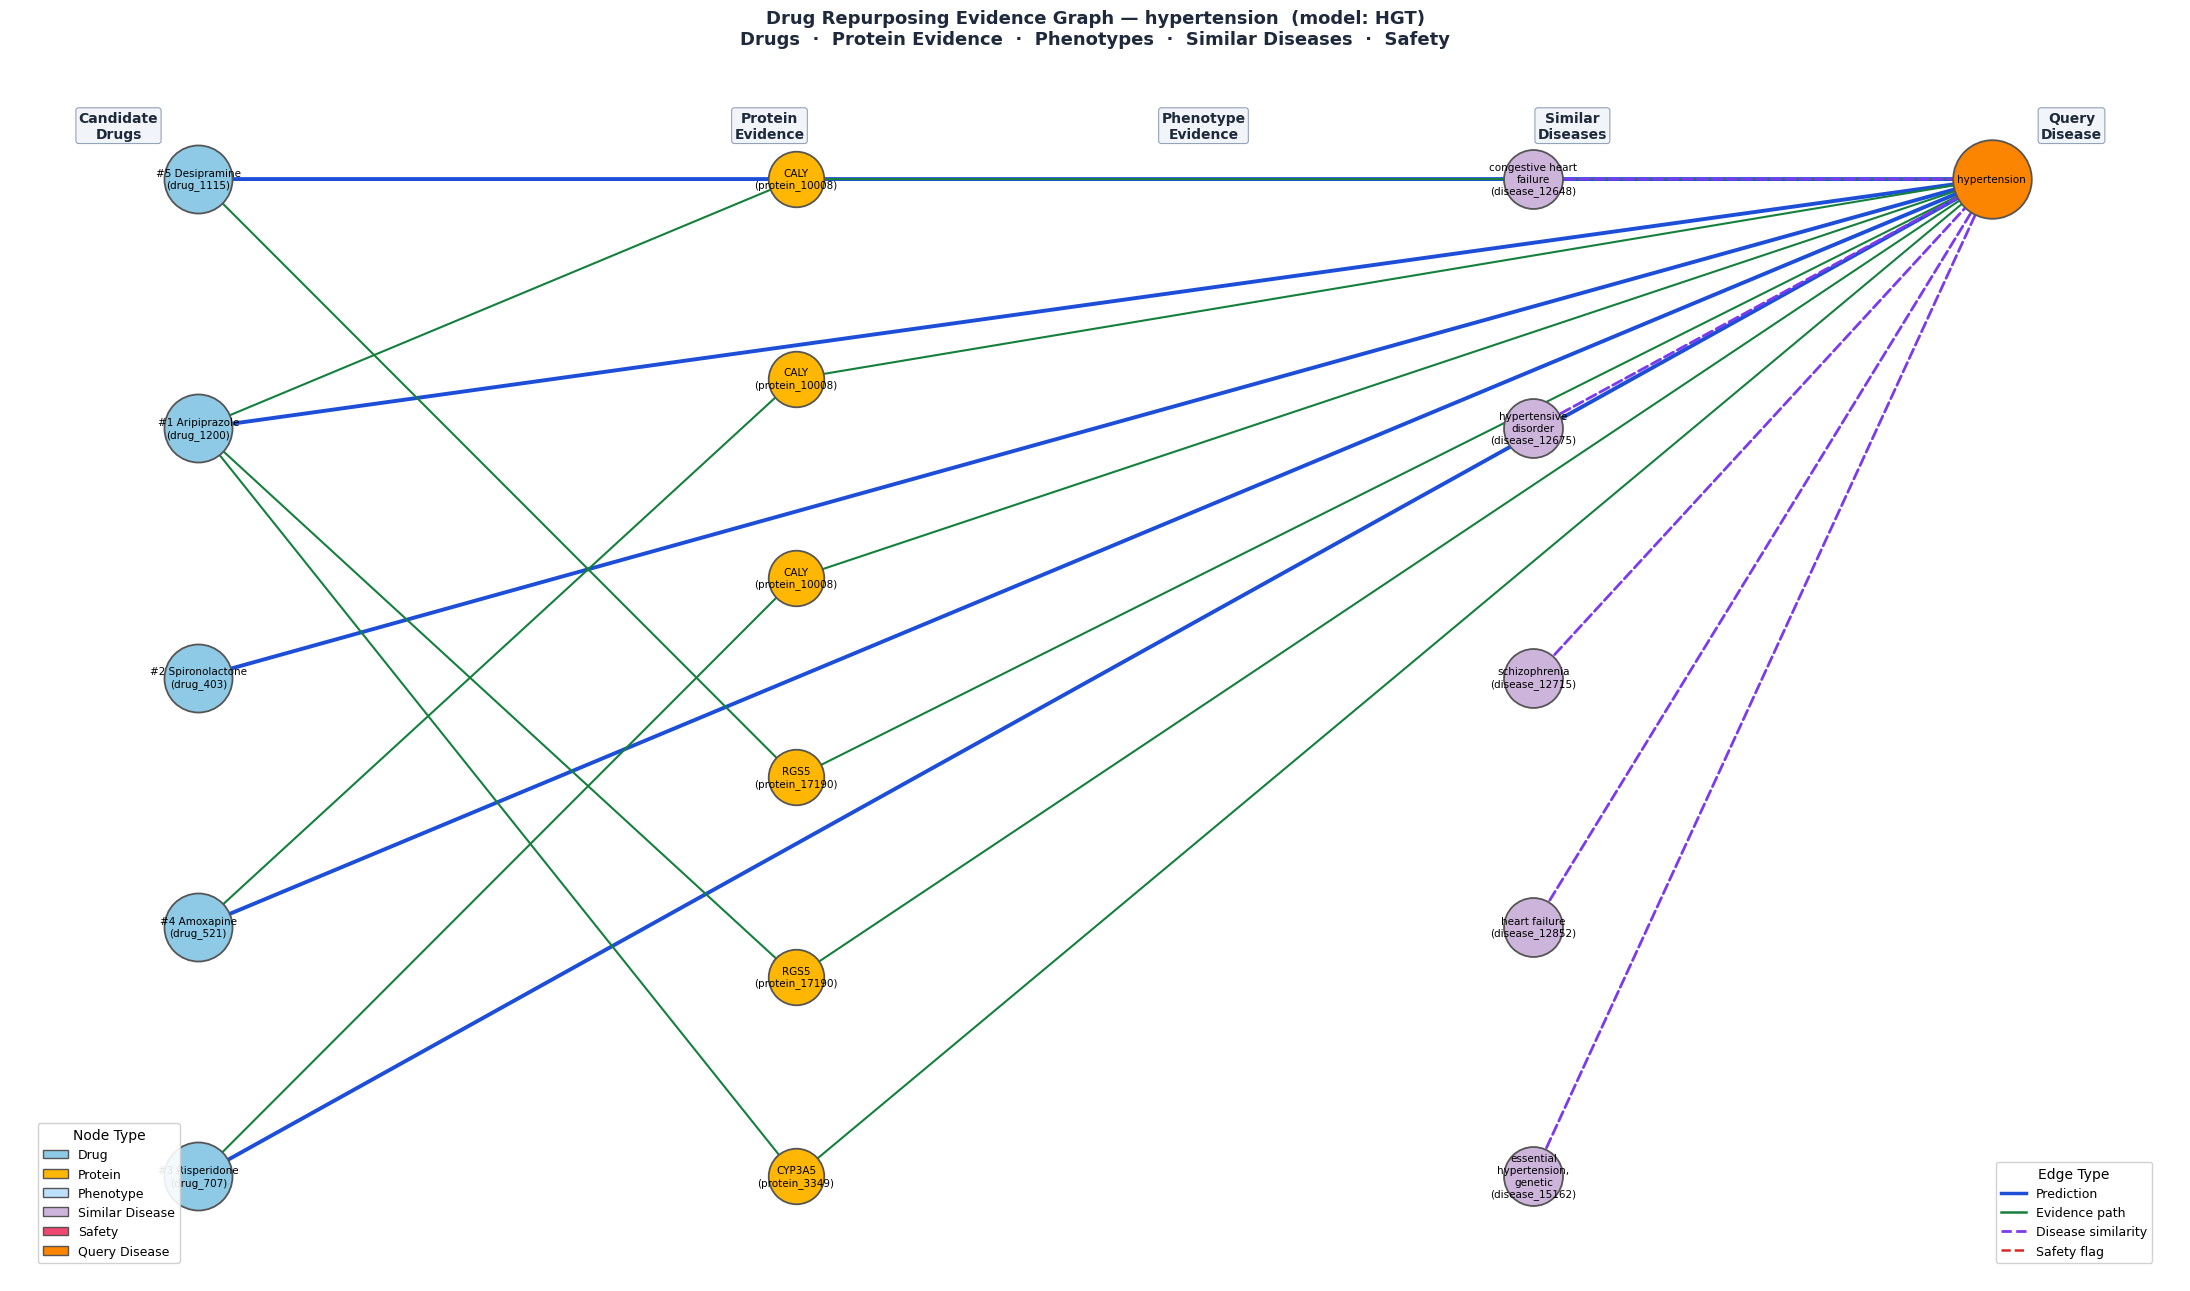

  Subgraph saved → /mnt/data/demo_subgraph.png

═════════════════════════════════════════════════════════════════
  OUTPUT 4 — RAG EXPLANATION & SUMMARY
═════════════════════════════════════════════════════════════════

DRUG REPURPOSING REPORT
═════════════════════════════════════════════════════════════════
Disease query   : hypertension
Model           : HGT

SIMILAR DISEASES USED AS CONTEXT
─────────────────────────────────────────────────────────────────
Diseases most biologically similar to the query were identified using:
embedding cosine similarity · disease ontology edges · shared proteins
PPI-expanded protein bridges · phenotype overlap · shared therapeutics

  • hypertensive disorder (disease_12675) (similarity=0.799, embedding=0.997, shared proteins=12, shared effects=0)
  • essential hypertension, genetic (disease_15162) (similarity=0.734, embedding=0.827, shared proteins=12, shared effects=0)
  • schizophrenia (disease_12715) (similarity=0.596, embedding=0.976, shared prot

,drug,known_treatment_for,model_score,similar_disease_support,rerank_score,risk,evidence_summary,safety_summary
rank,,,,,,,,
1,Aripiprazole (drug_1200),"bipolar disorder, schizophrenia, autism spectrum disorder (+1 more)",0.554106,0.587499,0.651633,low,Shared protein target: Aripiprazole (drug_1200) --[drug_enzyme_protein]--> CYP3A5 (protein_3349) <--[disease_associa...,No direct contraindication or adverse overlap signal found.
2,Spironolactone (drug_403),"Bartter disease, primary aldosteronism, congestive heart failure (+1 more)",0.553825,0.706262,0.521170,low,Related disease transfer: Spironolactone (drug_403) --[known treatment]--> hypertensive disorder (disease_12675) --[...,No direct contraindication or adverse overlap signal found.
3,Risperidone (drug_707),"autism susceptibility 1, manic bipolar affective disorder, bipolar disorder (+2 more)",0.554088,0.587499,0.501623,low,Protein interaction bridge: Risperidone (drug_707) --[drug_target_protein]--> DRD1 (protein_3816) --[protein_interac...,No direct contraindication or adverse overlap signal found.
4,Amoxapine (drug_521),"dysthymic disorder, neurotic disorder, anxiety disorder",0.554136,0.573907,0.498252,low,Protein interaction bridge: Amoxapine (drug_521) --[drug_target_protein]--> DRD1 (protein_3816) --[protein_interacts...,No direct contraindication or adverse overlap signal found.
5,Desipramine (drug_1115),"dysthymic disorder, neurotic disorder, anxiety disorder",0.553715,0.573907,0.498020,low,Protein interaction bridge: Desipramine (drug_1115) --[drug_target_protein]--> ADRB2 (protein_3281) --[protein_inter...,No direct contraindication or adverse overlap signal found.


In [ ]:
# Run the Demo

assert "run_demo" in globals(), "run_demo not found — run Block 13 first."

# Demo 1

DEMO_QUERY = "hypertension"   # try: "type 2 diabetes", "alzheimer disease", etc.
DEMO_MODEL = "hgt"            # "hgt" or "baseline"

demo_artifacts = run_demo(DEMO_QUERY, DEMO_MODEL)

#### → Demonstration - 2.

- Disease : `migraine`
- Model : `hgt`


═════════════════════════════════════════════════════════════════
  DRUG REPURPOSING DEMO
  Query   : 'migraine'  →  migraine disorder
  Model   : HGT
═════════════════════════════════════════════════════════════════

  Scoring 100 drug candidates ...
  Computing disease similarity ...

═════════════════════════════════════════════════════════════════
  OUTPUT 1 — TOP 5 CANDIDATE DRUGS
  Disease : migraine disorder  |  Model : HGT
═════════════════════════════════════════════════════════════════


,Drug,Model Score,Sim. Support,Rerank Score,Risk,Evidence,Safety Flags,Known Treatment For
Rank,,,,,,,,
1,Nintedanib (drug_5521),0.565758,0.236155,0.520206,low,3,0,"acute interstitial pneumonia, idiopathic interstitial pneumonia, non-small cell lung carcinoma (disease) (+2 more)"
2,Doxepin (drug_1107),0.565872,0.230991,0.478978,low,2,0,"dermatitis, atopic, insomnia (disease), atopic eczema (+3 more)"
3,Lamotrigine (drug_533),0.565785,0.000000,0.471182,low,3,0,"visual epilepsy, cutis verticis gyrata, epilepsy"
4,Progesterone (drug_378),0.565854,0.000000,0.396219,high,3,1,"endometriosis of uterus, postmenopausal atrophic vaginitis, endometrium neoplasm (+3 more)"
5,Phenytoin (drug_237),0.565896,0.000000,0.361243,low,1,0,"visual epilepsy, Lennox-Gastaut syndrome, status epilepticus (+3 more)"



═════════════════════════════════════════════════════════════════
  OUTPUT 2 — TOP 10 SIMILAR DISEASES
═════════════════════════════════════════════════════════════════


,Similar Disease,Similarity Score,Embedding Cos,Shared Proteins,Shared Effects,Shared Drugs
Rank,,,,,,
1,familial prostate carcinoma (disease_8836),0.638075,0.967754,4,0,0
2,prostate carcinoma (disease_12774),0.612707,0.986160,3,0,0
3,prostate cancer (disease_15606),0.611220,0.977666,3,0,0
4,anxiety disorder (disease_15492),0.603288,0.988454,3,0,0
5,unipolar depression (disease_12863),0.601884,0.994502,3,0,0
6,"migraine with or without aura, susceptibility to (disease_1476)",0.583472,0.940466,3,0,9
7,lung cancer (disease_16106),0.575666,0.989300,2,0,0
8,schizophrenia (disease_12715),0.574439,0.784823,3,0,0
9,colorectal cancer (disease_13149),0.573458,0.989514,2,0,0



═════════════════════════════════════════════════════════════════
  OUTPUT 3 — EVIDENCE & SIMILARITY SUBGRAPH
═════════════════════════════════════════════════════════════════


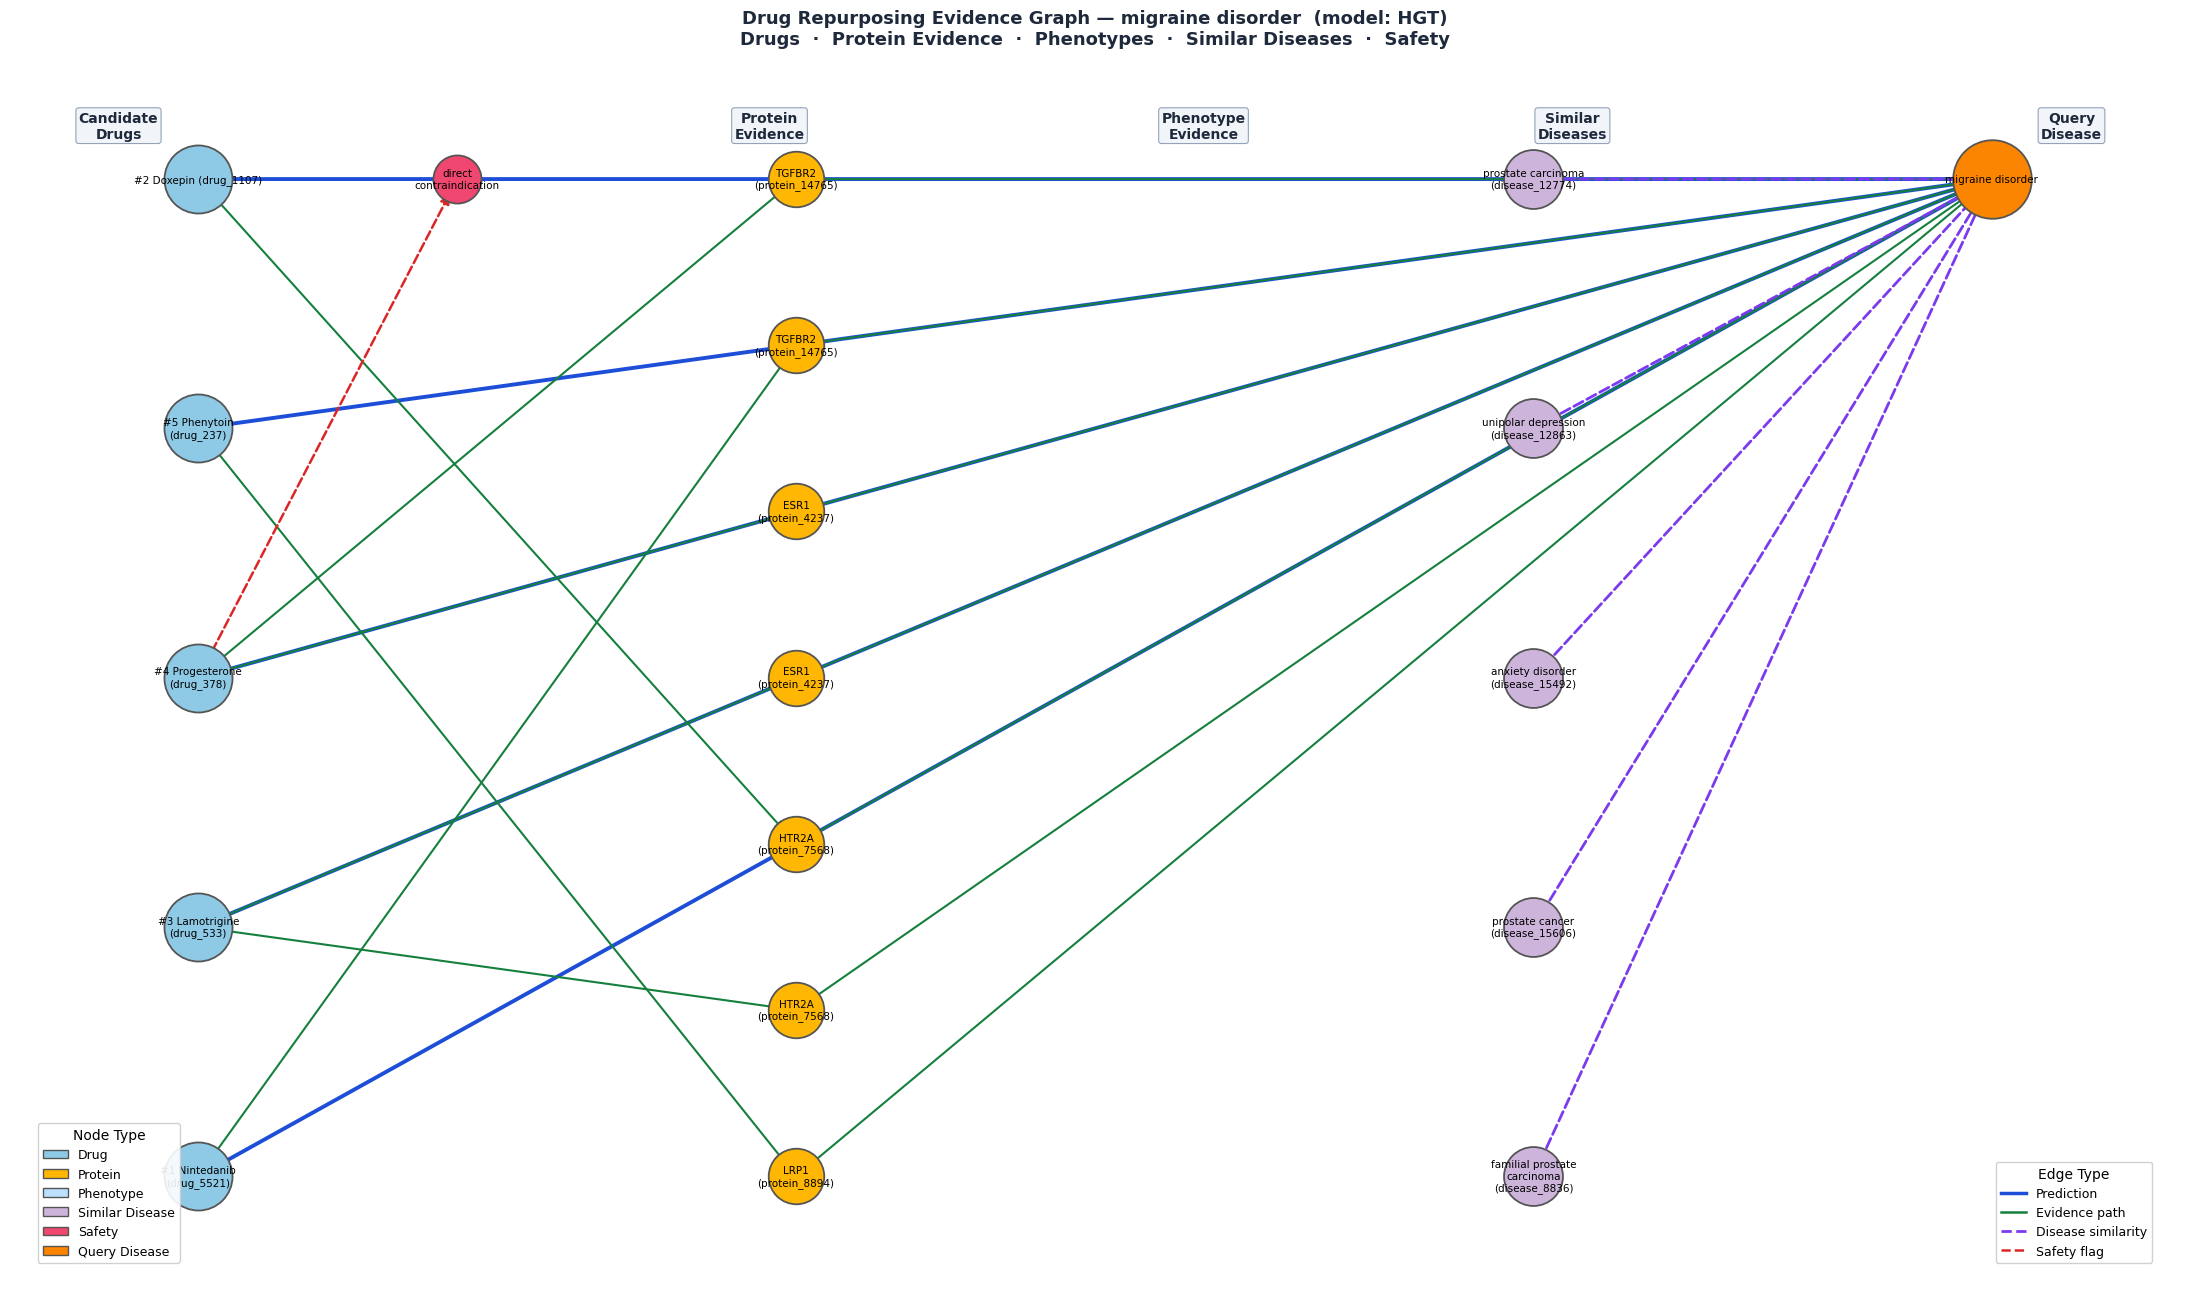

  Subgraph saved → /mnt/data/demo_subgraph.png

═════════════════════════════════════════════════════════════════
  OUTPUT 4 — RAG EXPLANATION & SUMMARY
═════════════════════════════════════════════════════════════════

DRUG REPURPOSING REPORT
═════════════════════════════════════════════════════════════════
Disease query   : migraine disorder
Model           : HGT

SIMILAR DISEASES USED AS CONTEXT
─────────────────────────────────────────────────────────────────
Diseases most biologically similar to the query were identified using:
embedding cosine similarity · disease ontology edges · shared proteins
PPI-expanded protein bridges · phenotype overlap · shared therapeutics

  • familial prostate carcinoma (disease_8836) (similarity=0.638, embedding=0.968, shared proteins=4, shared effects=0)
  • prostate carcinoma (disease_12774) (similarity=0.613, embedding=0.986, shared proteins=3, shared effects=0)
  • prostate cancer (disease_15606) (similarity=0.611, embedding=0.978, shared protein

,drug,known_treatment_for,model_score,similar_disease_support,rerank_score,risk,evidence_summary,safety_summary
rank,,,,,,,,
1,Nintedanib (drug_5521),"acute interstitial pneumonia, idiopathic interstitial pneumonia, non-small cell lung carcinoma (disease) (+2 more)",0.565758,0.236155,0.520206,low,Protein interaction bridge: Nintedanib (drug_5521) --[drug_target_protein]--> FGFR1 (protein_4564) --[protein_intera...,No direct contraindication or adverse overlap signal found.
2,Doxepin (drug_1107),"dermatitis, atopic, insomnia (disease), atopic eczema (+3 more)",0.565872,0.230991,0.478978,low,Shared protein target: Doxepin (drug_1107) --[drug_target_protein]--> HTR2A (protein_7568) <--[disease_associated_wi...,No direct contraindication or adverse overlap signal found.
3,Lamotrigine (drug_533),"visual epilepsy, cutis verticis gyrata, epilepsy",0.565785,0.000000,0.471182,low,Shared protein target: Lamotrigine (drug_533) --[drug_target_protein]--> HTR2A (protein_7568) <--[disease_associated...,No direct contraindication or adverse overlap signal found.
4,Progesterone (drug_378),"endometriosis of uterus, postmenopausal atrophic vaginitis, endometrium neoplasm (+3 more)",0.565854,0.000000,0.396219,high,Shared protein target: Progesterone (drug_378) --[drug_target_protein]--> ESR1 (protein_4237) <--[disease_associated...,Direct safety warning: Direct contraindication: Progesterone (drug_378) --[contraindication]-- migraine disorder (di...
5,Phenytoin (drug_237),"visual epilepsy, Lennox-Gastaut syndrome, status epilepticus (+3 more)",0.565896,0.000000,0.361243,low,Protein interaction bridge: Phenytoin (drug_237) --[drug_target_protein]--> CACNA1A (protein_15376) --[protein_inter...,No direct contraindication or adverse overlap signal found.


In [ ]:
# Demo 2

DEMO_QUERY = "migraine"    # try: "type 2 diabetes", "alzheimer disease", etc.
DEMO_MODEL = "hgt"         # "hgt" or "baseline"

demo_artifacts = run_demo(DEMO_QUERY, DEMO_MODEL)

#### → Demonstration - 3.

- Disease : `psoriasis`
- Model : `hgt`


═════════════════════════════════════════════════════════════════
  DRUG REPURPOSING DEMO
  Query   : 'psoriasis'  →  psoriasis
  Model   : HGT
═════════════════════════════════════════════════════════════════

  Scoring 100 drug candidates ...
  Computing disease similarity ...

═════════════════════════════════════════════════════════════════
  OUTPUT 1 — TOP 5 CANDIDATE DRUGS
  Disease : psoriasis  |  Model : HGT
═════════════════════════════════════════════════════════════════


,Drug,Model Score,Sim. Support,Rerank Score,Risk,Evidence,Safety Flags,Known Treatment For
Rank,,,,,,,,
1,Methylprednisolone (drug_929),0.573084,0.673471,0.683564,low,6,0,"X-linked adrenal hypoplasia congenita, chondrocalcinosis, dermatitis, atopic (+73 more)"
2,Regorafenib (drug_5408),0.572930,0.565849,0.656573,low,5,0,"gastrointestinal stromal tumor, pediatric hepatocellular carcinoma, adenocarcinoma of liver and intrahepatic biliary..."
3,Ramucirumab (drug_3456),0.572884,0.851147,0.627873,low,2,0,"pediatric hepatocellular carcinoma, undifferentiated carcinoma of liver and intrahepatic biliary tract, liver cancer..."
4,Fluocinonide (drug_1014),0.572963,0.326529,0.596762,low,6,0,"primary cutaneous T-cell lymphoma, discoid lupus erythematosus, dermatitis (+8 more)"
5,Doxorubicin (drug_966),0.572843,0.285298,0.586388,low,6,0,"acute myeloid leukemia and myelodysplastic syndromes related to topoisomerase type 2 inhibitor, acute myeloid leukem..."



═════════════════════════════════════════════════════════════════
  OUTPUT 2 — TOP 10 SIMILAR DISEASES
═════════════════════════════════════════════════════════════════


,Similar Disease,Similarity Score,Embedding Cos,Shared Proteins,Shared Effects,Shared Drugs
Rank,,,,,,
1,parapsoriasis (disease_14126),0.794633,0.984647,59,0,7
2,"psoriasis 14, pustular (disease_2356)",0.721991,0.849412,57,0,0
3,dermatitis (disease_9036),0.666350,0.895644,2,0,4
4,lung cancer (disease_16106),0.582209,0.954773,14,0,1
5,pustular psoriasis (disease_8434),0.581464,0.986316,1,0,0
6,rheumatoid arthritis (disease_15665),0.579723,0.979051,14,0,3
7,hepatocellular carcinoma (disease_14718),0.577839,0.976508,17,0,0
8,liver cancer (disease_9657),0.576892,0.987054,16,0,0
9,hereditary breast ovarian cancer syndrome (disease_10777),0.574417,0.994999,12,0,0



═════════════════════════════════════════════════════════════════
  OUTPUT 3 — EVIDENCE & SIMILARITY SUBGRAPH
═════════════════════════════════════════════════════════════════


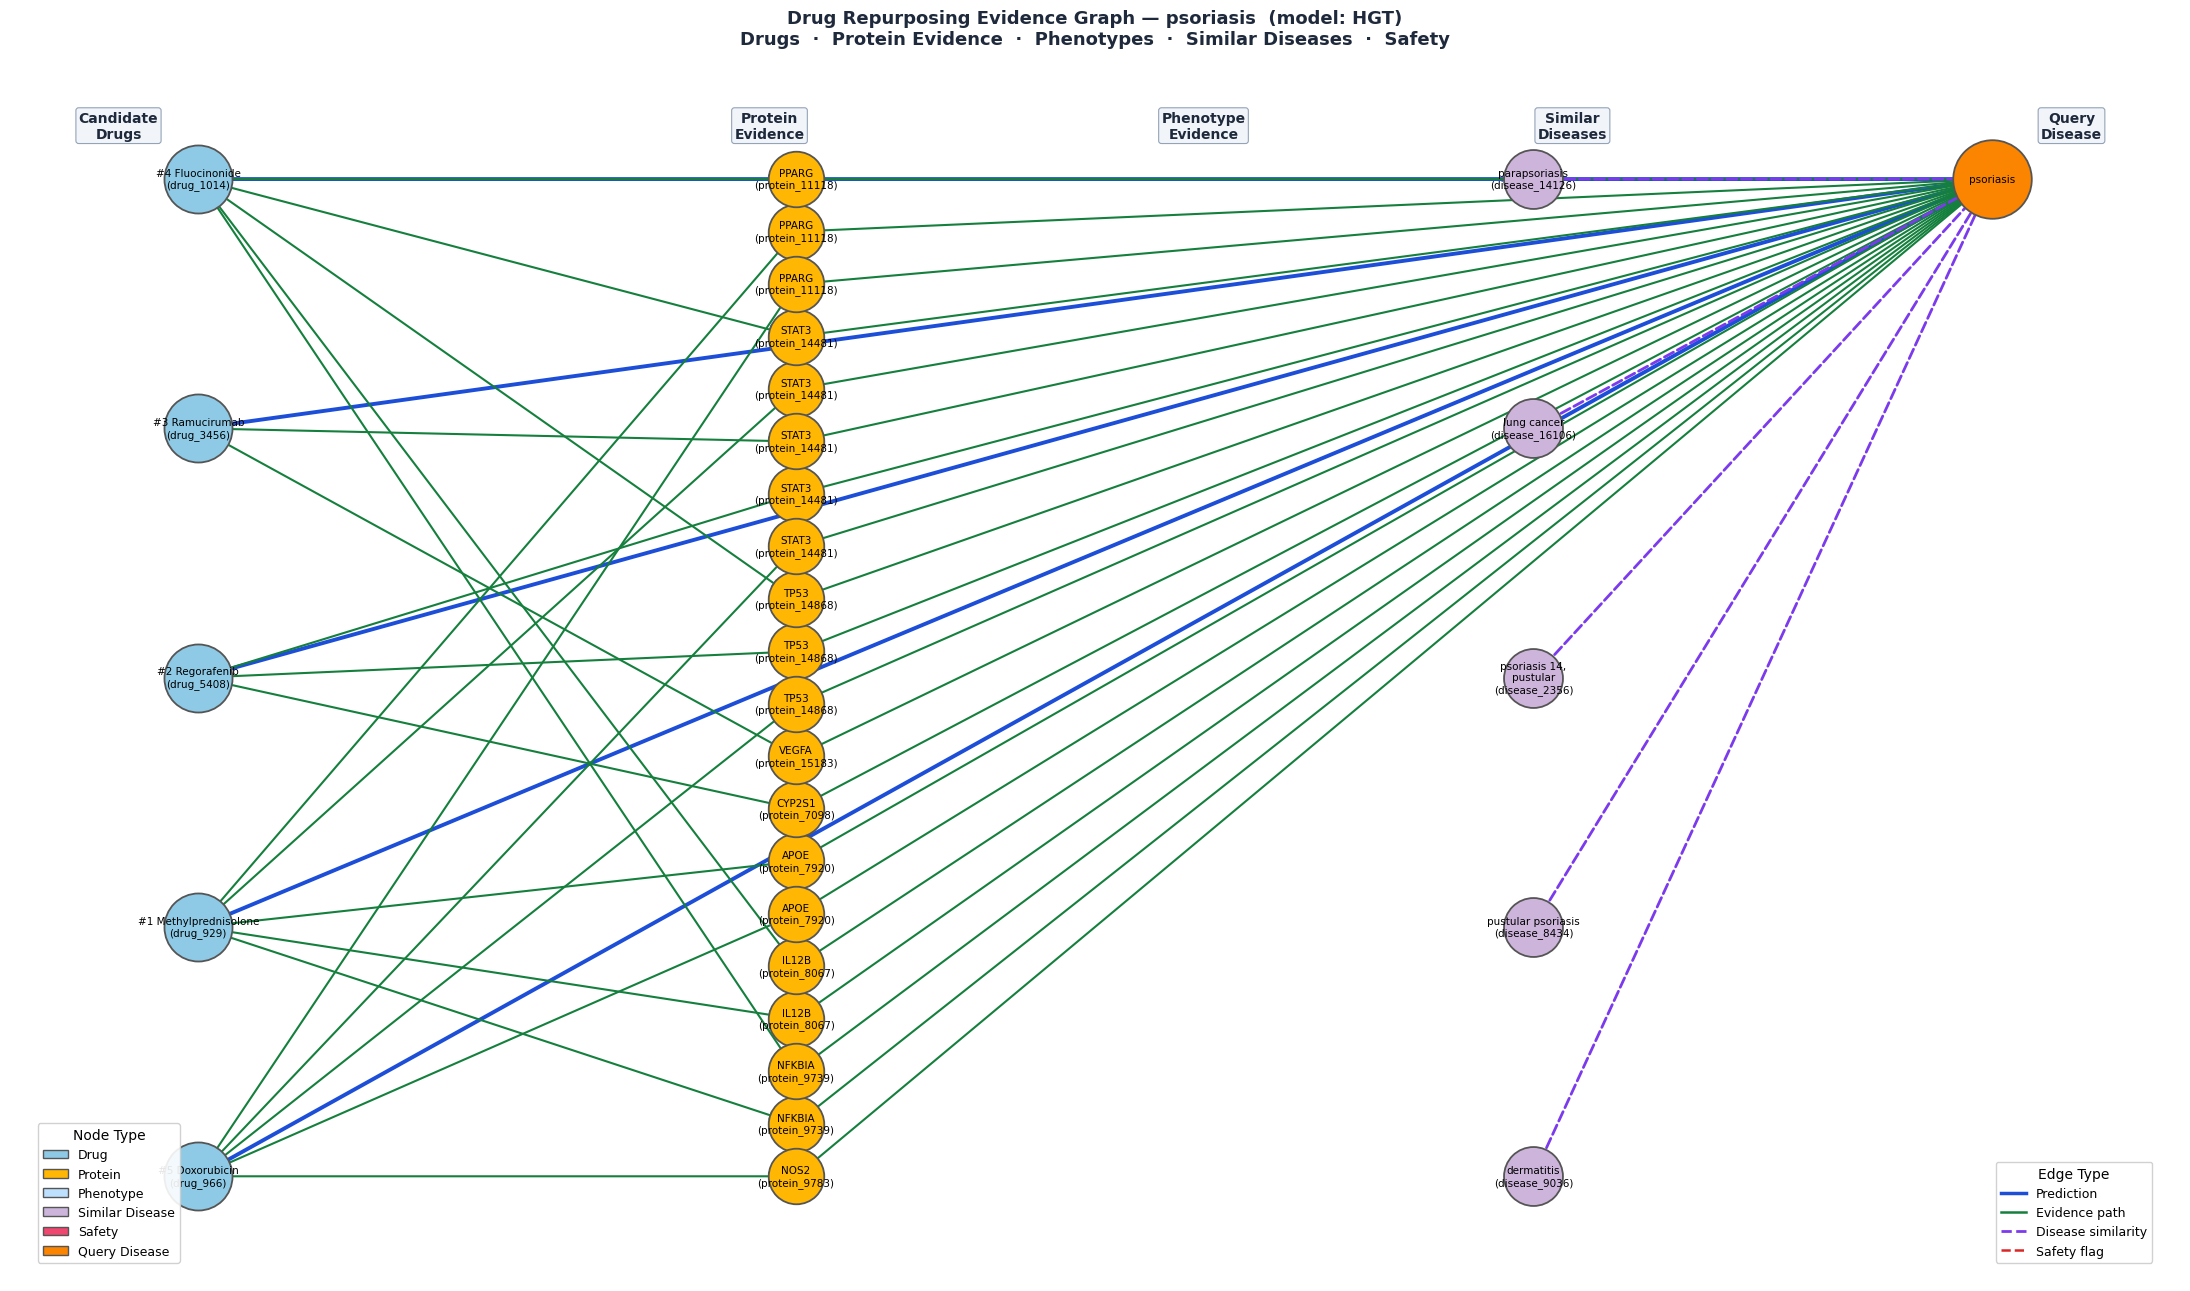

  Subgraph saved → /mnt/data/demo_subgraph.png

═════════════════════════════════════════════════════════════════
  OUTPUT 4 — RAG EXPLANATION & SUMMARY
═════════════════════════════════════════════════════════════════

DRUG REPURPOSING REPORT
═════════════════════════════════════════════════════════════════
Disease query   : psoriasis
Model           : HGT

SIMILAR DISEASES USED AS CONTEXT
─────────────────────────────────────────────────────────────────
Diseases most biologically similar to the query were identified using:
embedding cosine similarity · disease ontology edges · shared proteins
PPI-expanded protein bridges · phenotype overlap · shared therapeutics

  • parapsoriasis (disease_14126) (similarity=0.795, embedding=0.985, shared proteins=59, shared effects=0)
  • psoriasis 14, pustular (disease_2356) (similarity=0.722, embedding=0.849, shared proteins=57, shared effects=0)
  • dermatitis (disease_9036) (similarity=0.666, embedding=0.896, shared proteins=2, shared effects=0)

,drug,known_treatment_for,model_score,similar_disease_support,rerank_score,risk,evidence_summary,safety_summary
rank,,,,,,,,
1,Methylprednisolone (drug_929),"X-linked adrenal hypoplasia congenita, chondrocalcinosis, dermatitis, atopic (+73 more)",0.573084,0.673471,0.683564,low,Protein interaction bridge: Methylprednisolone (drug_929) --[drug_carrier_protein]--> ALB (protein_4264) --[protein_...,No direct contraindication or adverse overlap signal found.
2,Regorafenib (drug_5408),"gastrointestinal stromal tumor, pediatric hepatocellular carcinoma, adenocarcinoma of liver and intrahepatic biliary...",0.572930,0.565849,0.656573,low,Protein interaction bridge: Regorafenib (drug_5408) --[drug_target_protein]--> EPHA2 (protein_3964) --[protein_inter...,No direct contraindication or adverse overlap signal found.
3,Ramucirumab (drug_3456),"pediatric hepatocellular carcinoma, undifferentiated carcinoma of liver and intrahepatic biliary tract, liver cancer...",0.572884,0.851147,0.627873,low,Protein interaction bridge: Ramucirumab (drug_3456) --[drug_target_protein]--> KDR (protein_8358) --[protein_interac...,No direct contraindication or adverse overlap signal found.
4,Fluocinonide (drug_1014),"primary cutaneous T-cell lymphoma, discoid lupus erythematosus, dermatitis (+8 more)",0.572963,0.326529,0.596762,low,Protein interaction bridge: Fluocinonide (drug_1014) --[drug_target_protein]--> NR3C1 (protein_6984) --[protein_inte...,No direct contraindication or adverse overlap signal found.
5,Doxorubicin (drug_966),"acute myeloid leukemia and myelodysplastic syndromes related to topoisomerase type 2 inhibitor, acute myeloid leukem...",0.572843,0.285298,0.586388,low,Shared protein target: Doxorubicin (drug_966) --[drug_enzyme_protein]--> NOS2 (protein_9783) <--[disease_associated_...,No direct contraindication or adverse overlap signal found.


In [16]:
# Demo 3

DEMO_QUERY = "psoriasis"    # try: "type 2 diabetes", "alzheimer disease", etc.
DEMO_MODEL = "hgt"         # "hgt" or "baseline"

demo_artifacts = run_demo(DEMO_QUERY, DEMO_MODEL)

#### → Demonstration - 4.

- Disease : `anemia`
- Model : `hgt`


═════════════════════════════════════════════════════════════════
  DRUG REPURPOSING DEMO
  Query   : 'anemia'  →  anemia (disease)
  Model   : HGT
═════════════════════════════════════════════════════════════════

  Scoring 100 drug candidates ...
  Computing disease similarity ...

═════════════════════════════════════════════════════════════════
  OUTPUT 1 — TOP 5 CANDIDATE DRUGS
  Disease : anemia (disease)  |  Model : HGT
═════════════════════════════════════════════════════════════════


,Drug,Model Score,Sim. Support,Rerank Score,Risk,Evidence,Safety Flags,Known Treatment For
Rank,,,,,,,,
1,Testosterone (drug_600),0.566466,0.0,0.511556,low,5,0,"premature menopause, combined pituitary hormone deficiencies, genetic form, pituitary deficiency (+20 more)"
2,Testosterone enanthate (drug_6450),0.562182,0.0,0.509200,low,5,0,"premature menopause, trisomy 13, androgen insensitivity syndrome (+3 more)"
3,Ketoconazole (drug_995),0.561272,0.0,0.508700,low,4,0,"chromomycosis, white piedra, Cushing syndrome (+11 more)"
4,Cisplatin (drug_494),0.561239,0.0,0.508682,low,6,0,"borderline epithelial tumor of ovary, malignant non-dysgerminomatous germ cell tumor of ovary, familial ovarian canc..."
5,Methotrexate (drug_540),0.562198,0.0,0.434209,high,5,1,"juvenile idiopathic arthritis, Langerhans cell histiocytosis, non-Hodgkin lymphoma (+15 more)"



═════════════════════════════════════════════════════════════════
  OUTPUT 2 — TOP 10 SIMILAR DISEASES
═════════════════════════════════════════════════════════════════


,Similar Disease,Similarity Score,Embedding Cos,Shared Proteins,Shared Effects,Shared Drugs
Rank,,,,,,
1,macrocytic anemia (disease) (disease_8672),0.804716,0.952129,36,1,0
2,sideroblastic anemia (disease_15701),0.694448,0.961711,1,2,0
3,pancytopenia (disease_3251),0.660468,0.987846,3,0,0
4,beta-thalassemia and related diseases (disease_4814),0.604658,0.759981,2,0,0
5,microcytic anemia (disease_1809),0.593104,0.716523,0,1,0
6,hypochromic anemia (disease_2332),0.591500,0.688182,0,1,0
7,undifferentiated carcinoma of the corpus uteri (disease_4026),0.581832,0.950627,12,0,0
8,breast cancer (disease_14717),0.572418,0.896834,12,0,0
9,aplastic anemia (disease_3742),0.569642,0.648997,2,0,0



═════════════════════════════════════════════════════════════════
  OUTPUT 3 — EVIDENCE & SIMILARITY SUBGRAPH
═════════════════════════════════════════════════════════════════


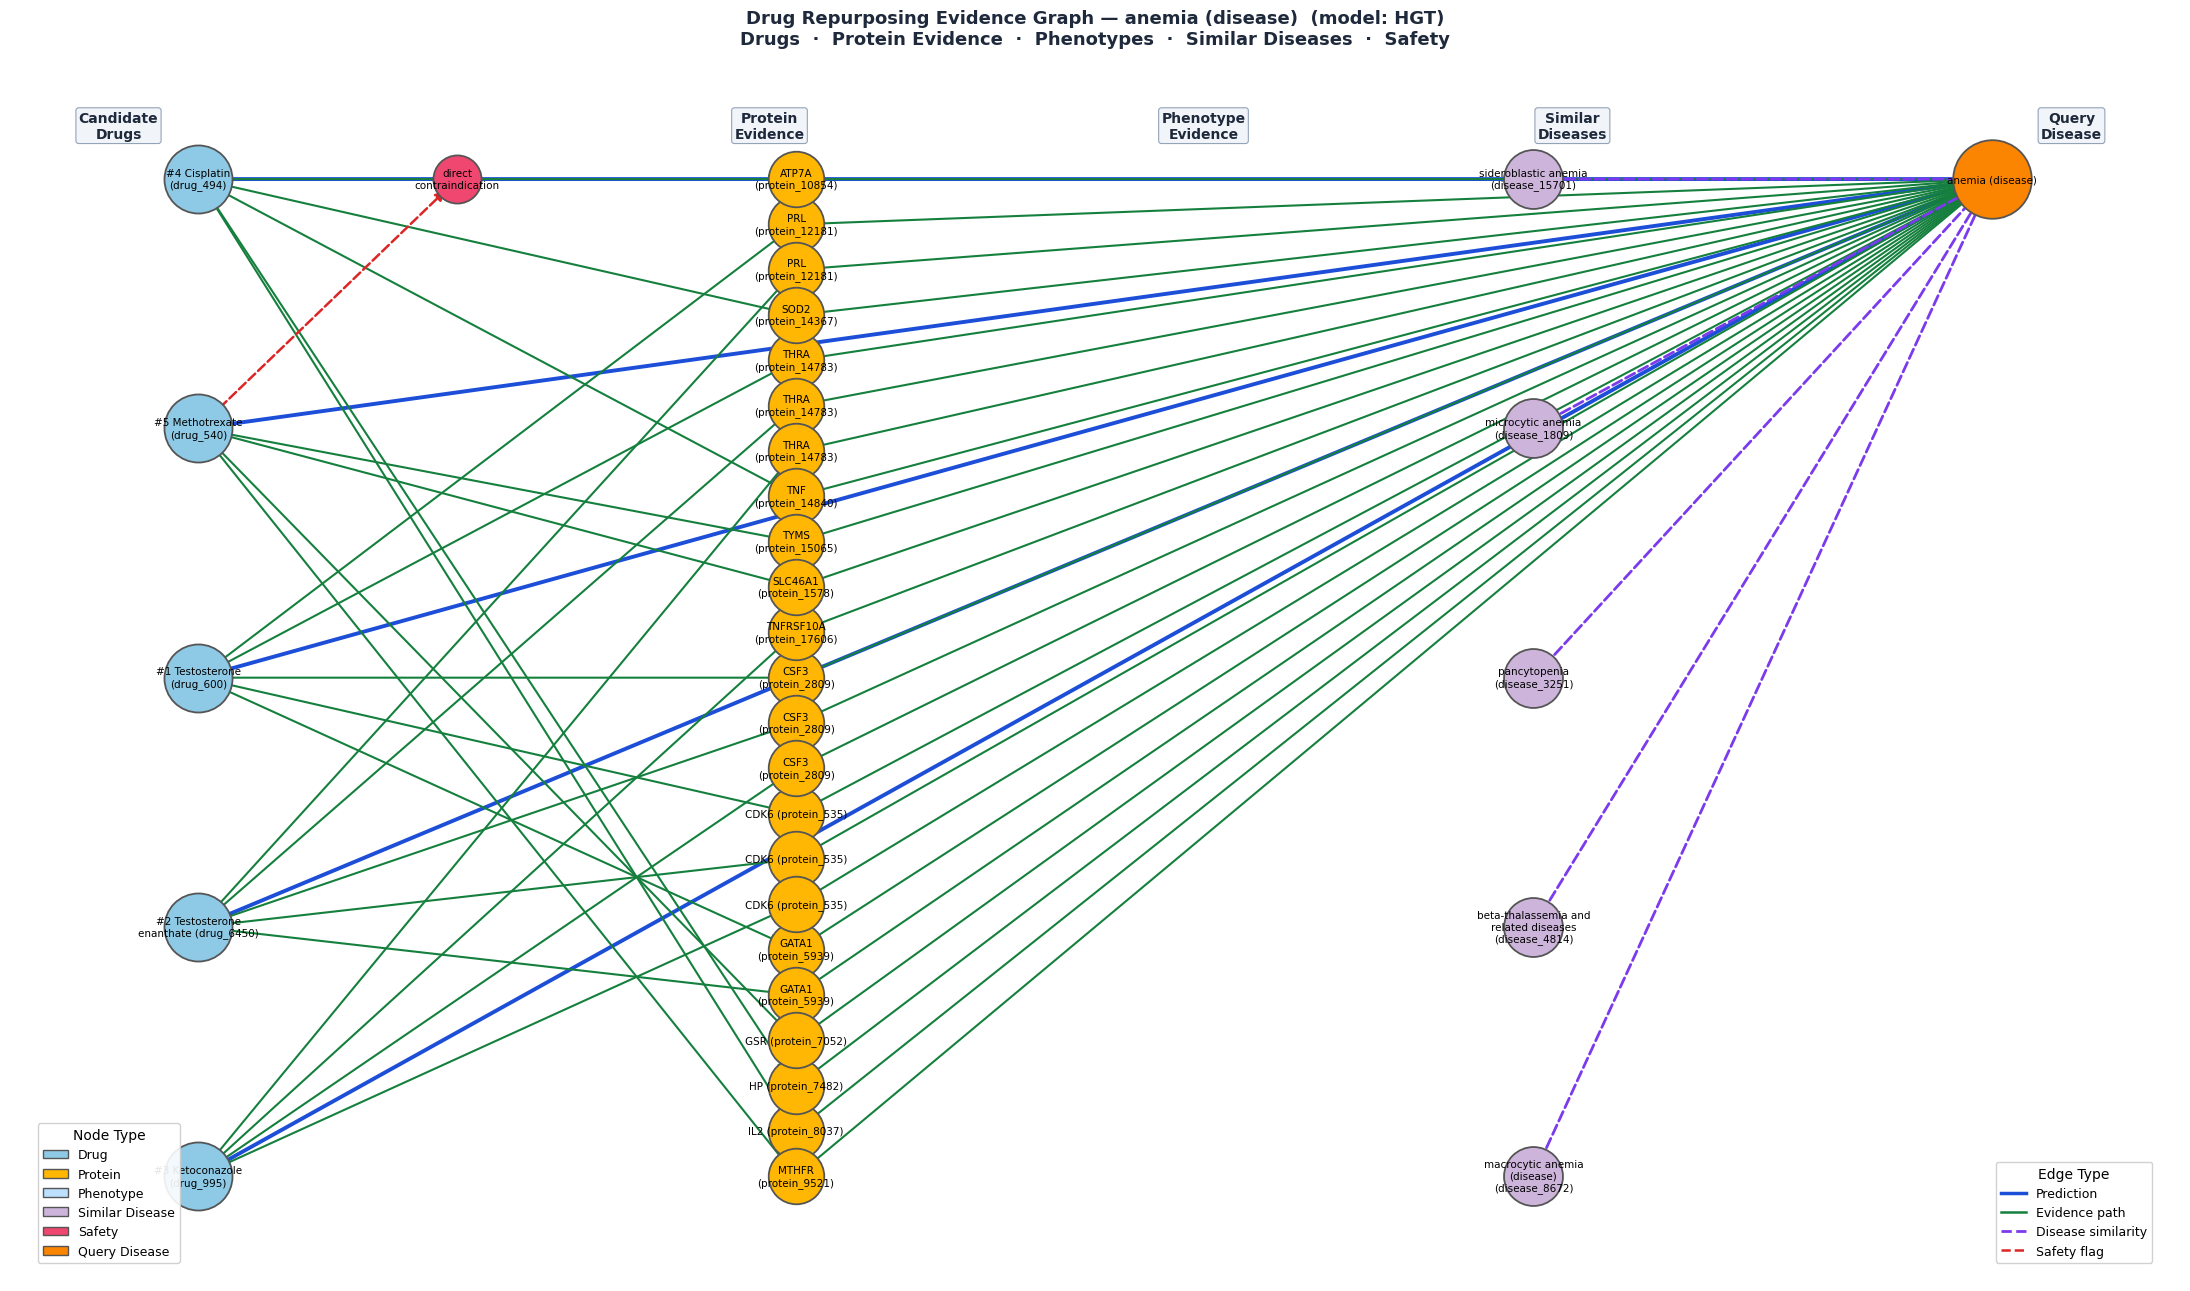

  Subgraph saved → /mnt/data/demo_subgraph.png

═════════════════════════════════════════════════════════════════
  OUTPUT 4 — RAG EXPLANATION & SUMMARY
═════════════════════════════════════════════════════════════════

DRUG REPURPOSING REPORT
═════════════════════════════════════════════════════════════════
Disease query   : anemia (disease)
Model           : HGT

SIMILAR DISEASES USED AS CONTEXT
─────────────────────────────────────────────────────────────────
Diseases most biologically similar to the query were identified using:
embedding cosine similarity · disease ontology edges · shared proteins
PPI-expanded protein bridges · phenotype overlap · shared therapeutics

  • macrocytic anemia (disease) (disease_8672) (similarity=0.805, embedding=0.952, shared proteins=36, shared effects=1)
  • sideroblastic anemia (disease_15701) (similarity=0.694, embedding=0.962, shared proteins=1, shared effects=2)
  • pancytopenia (disease_3251) (similarity=0.660, embedding=0.988, shared proteins=

,drug,known_treatment_for,model_score,similar_disease_support,rerank_score,risk,evidence_summary,safety_summary
rank,,,,,,,,
1,Testosterone (drug_600),"premature menopause, combined pituitary hormone deficiencies, genetic form, pituitary deficiency (+20 more)",0.566466,0.0,0.511556,low,Protein interaction bridge: Testosterone (drug_600) --[drug_target_protein]--> ESR1 (protein_4237) --[protein_intera...,No direct contraindication or adverse overlap signal found.
2,Testosterone enanthate (drug_6450),"premature menopause, trisomy 13, androgen insensitivity syndrome (+3 more)",0.562182,0.0,0.509200,low,Protein interaction bridge: Testosterone enanthate (drug_6450) --[drug_target_protein]--> ESR1 (protein_4237) --[pro...,No direct contraindication or adverse overlap signal found.
3,Ketoconazole (drug_995),"chromomycosis, white piedra, Cushing syndrome (+11 more)",0.561272,0.0,0.508700,low,Protein interaction bridge: Ketoconazole (drug_995) --[drug_target_protein]--> AR (protein_8143) --[protein_interact...,No direct contraindication or adverse overlap signal found.
4,Cisplatin (drug_494),"borderline epithelial tumor of ovary, malignant non-dysgerminomatous germ cell tumor of ovary, familial ovarian canc...",0.561239,0.0,0.508682,low,Shared protein target: Cisplatin (drug_494) --[drug_transporter_protein]--> ATP7A (protein_10854) <--[disease_associ...,No direct contraindication or adverse overlap signal found.
5,Methotrexate (drug_540),"juvenile idiopathic arthritis, Langerhans cell histiocytosis, non-Hodgkin lymphoma (+15 more)",0.562198,0.0,0.434209,high,Shared protein target: Methotrexate (drug_540) --[drug_enzyme_protein]--> TYMS (protein_15065) <--[disease_associate...,Direct safety warning: Direct contraindication: Methotrexate (drug_540) --[contraindication]-- anemia (disease) (dis...


In [18]:
# Demo 4

DEMO_QUERY = "anemia"    # try: "type 2 diabetes", "alzheimer disease", etc.
DEMO_MODEL = "hgt"         # "hgt" or "baseline"

demo_artifacts = run_demo(DEMO_QUERY, DEMO_MODEL)

#### → Demonstration - 5.

- Disease : `alzheimer's`
- Model : `hgt`


═════════════════════════════════════════════════════════════════
  DRUG REPURPOSING DEMO
  Query   : 'alzheimer's'  →  Alzheimer disease
  Model   : HGT
═════════════════════════════════════════════════════════════════

  Scoring 100 drug candidates ...
  Computing disease similarity ...

═════════════════════════════════════════════════════════════════
  OUTPUT 1 — TOP 5 CANDIDATE DRUGS
  Disease : Alzheimer disease  |  Model : HGT
═════════════════════════════════════════════════════════════════


,Drug,Model Score,Sim. Support,Rerank Score,Risk,Evidence,Safety Flags,Known Treatment For
Rank,,,,,,,,
1,Istradefylline (drug_5977),0.568464,0.237003,0.571906,low,6,0,"X-linked parkinsonism-spasticity syndrome, early-onset parkinsonism-intellectual disability syndrome, Parkinson dise..."
2,Safinamide (drug_3813),0.568407,0.237003,0.571875,low,7,0,"X-linked parkinsonism-spasticity syndrome, early-onset parkinsonism-intellectual disability syndrome, Parkinson dise..."
3,Droxidopa (drug_3666),0.568343,0.237003,0.571839,low,5,0,"X-linked parkinsonism-spasticity syndrome, early-onset parkinsonism-intellectual disability syndrome, Parkinson dise..."
4,Bromocriptine (drug_1162),0.568243,0.237003,0.571784,low,5,0,"X-linked parkinsonism-spasticity syndrome, early-onset parkinsonism-intellectual disability syndrome, Parkinson dise..."
5,Lithium carbonate (drug_6544),0.568421,0.227618,0.569536,low,4,0,"headache disorder, manic bipolar affective disorder, juvenile arthritis due to defect in LACC1 (+5 more)"



═════════════════════════════════════════════════════════════════
  OUTPUT 2 — TOP 10 SIMILAR DISEASES
═════════════════════════════════════════════════════════════════


,Similar Disease,Similarity Score,Embedding Cos,Shared Proteins,Shared Effects,Shared Drugs
Rank,,,,,,
1,Alzheimer disease without neurofibrillary tangles (disease_1207),0.777324,0.980951,101,0,2
2,dementia (disease) (disease_4029),0.660359,0.951862,6,0,0
3,Pick disease (disease_15540),0.625575,0.975548,101,3,3
4,Parkinson disease (disease_1428),0.621532,0.977789,18,17,0
5,cerebellar degeneration (disease_8600),0.620203,0.973985,101,0,4
6,hereditary breast carcinoma (disease_4152),0.610758,0.952930,23,2,0
7,Reye syndrome (disease_13495),0.599356,0.996321,101,0,5
8,anxiety disorder (disease_15492),0.597925,0.964913,29,1,0
9,major affective disorder (disease_14864),0.596919,0.962324,23,2,0



═════════════════════════════════════════════════════════════════
  OUTPUT 3 — EVIDENCE & SIMILARITY SUBGRAPH
═════════════════════════════════════════════════════════════════


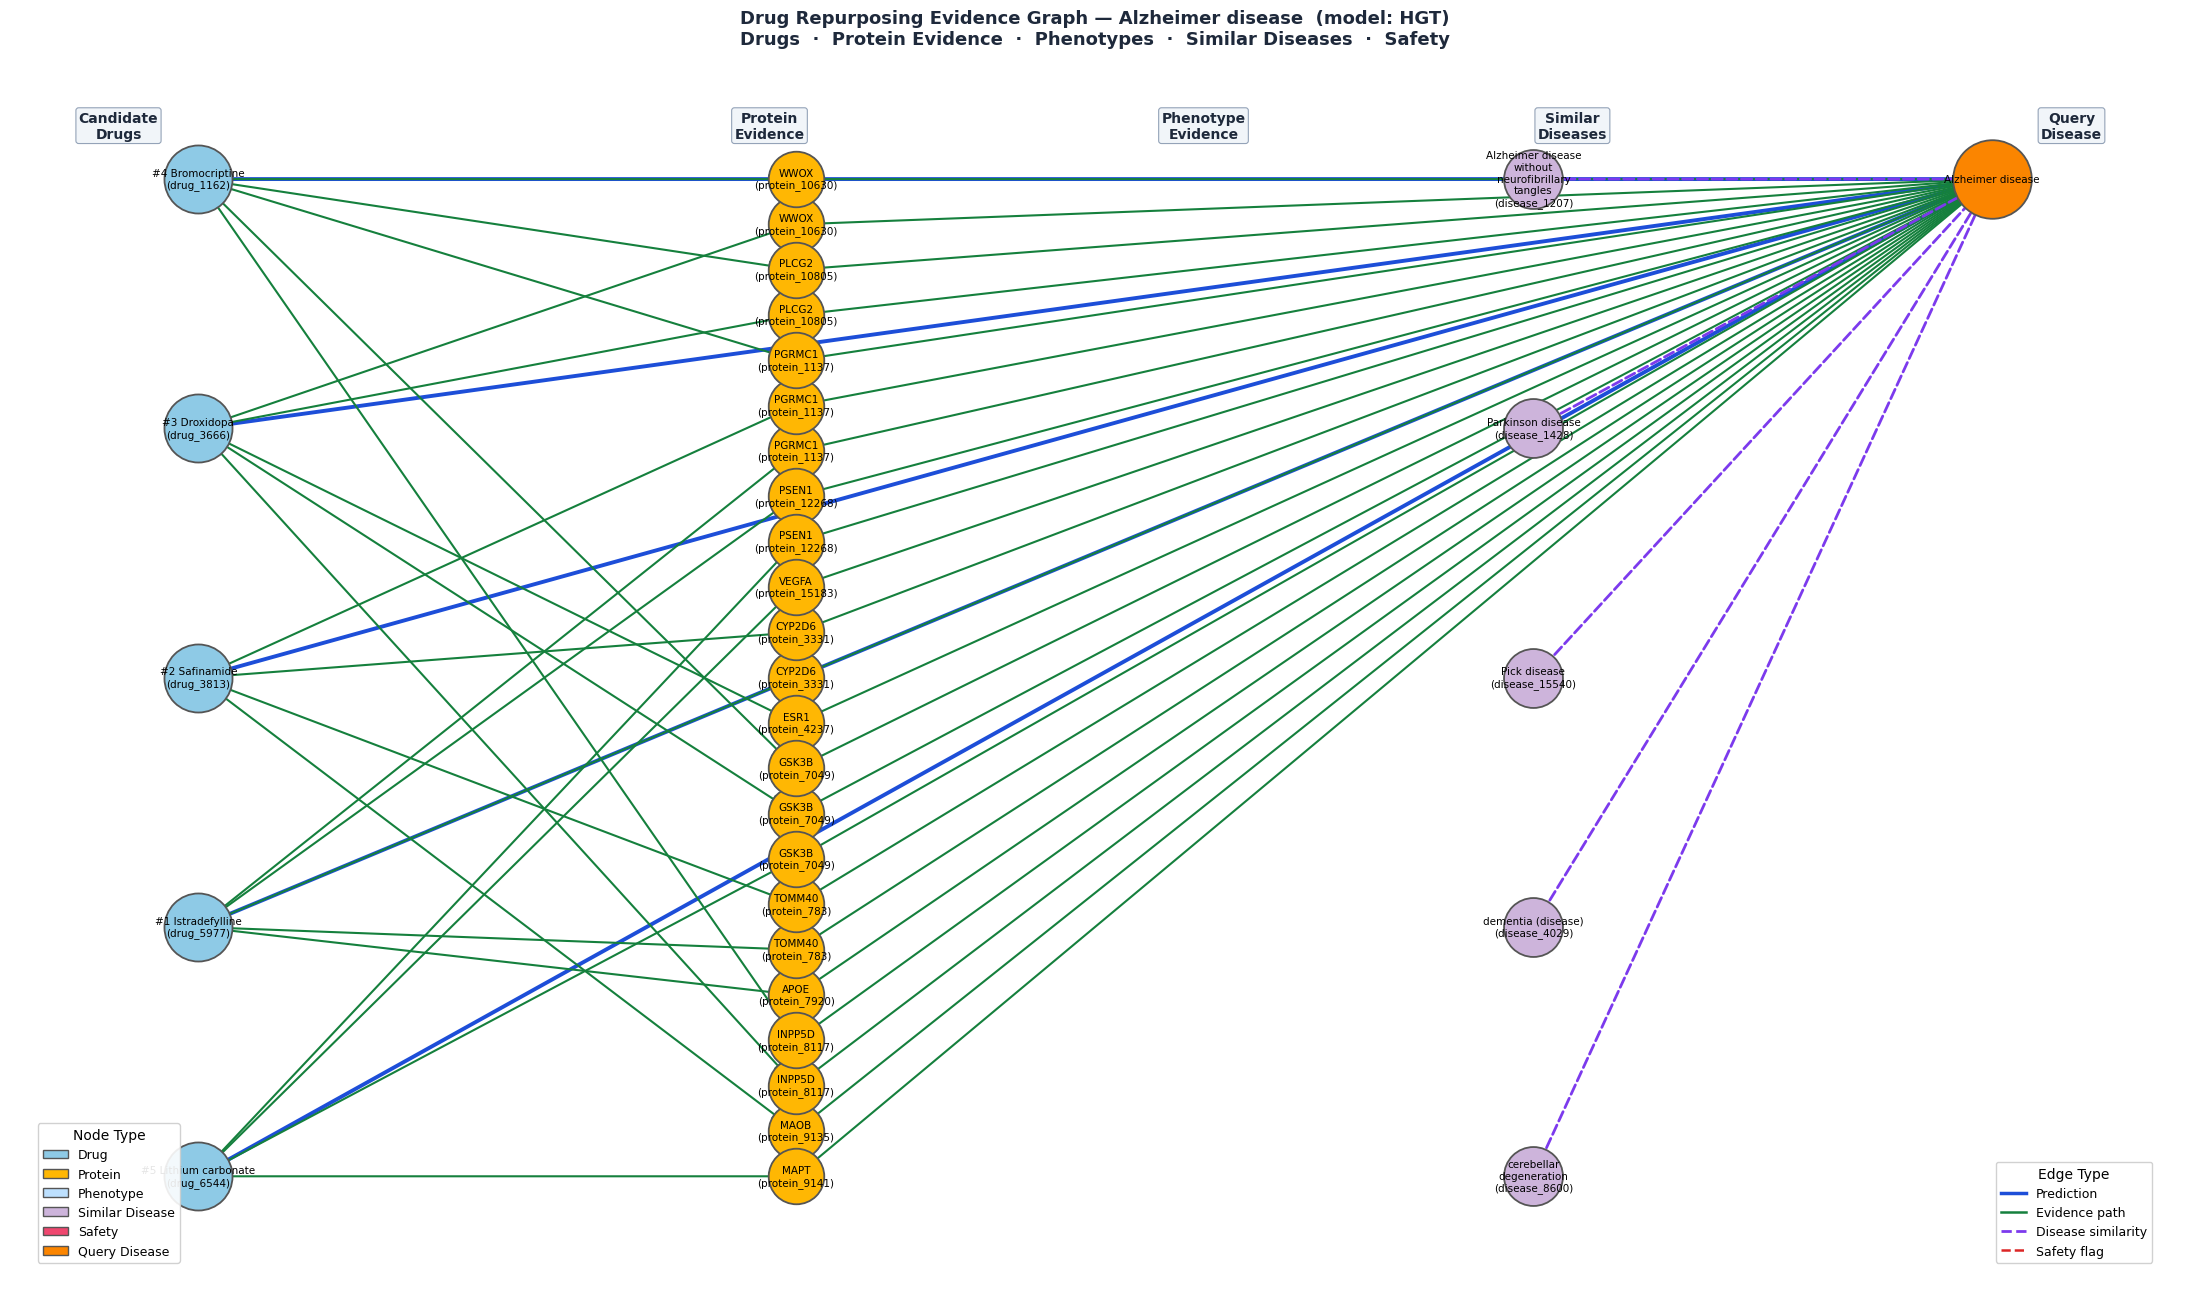

  Subgraph saved → /mnt/data/demo_subgraph.png

═════════════════════════════════════════════════════════════════
  OUTPUT 4 — RAG EXPLANATION & SUMMARY
═════════════════════════════════════════════════════════════════

DRUG REPURPOSING REPORT
═════════════════════════════════════════════════════════════════
Disease query   : Alzheimer disease
Model           : HGT

SIMILAR DISEASES USED AS CONTEXT
─────────────────────────────────────────────────────────────────
Diseases most biologically similar to the query were identified using:
embedding cosine similarity · disease ontology edges · shared proteins
PPI-expanded protein bridges · phenotype overlap · shared therapeutics

  • Alzheimer disease without neurofibrillary tangles (disease_1207) (similarity=0.777, embedding=0.981, shared proteins=101, shared effects=0)
  • dementia (disease) (disease_4029) (similarity=0.660, embedding=0.952, shared proteins=6, shared effects=0)
  • Pick disease (disease_15540) (similarity=0.626, embedding=0

,drug,known_treatment_for,model_score,similar_disease_support,rerank_score,risk,evidence_summary,safety_summary
rank,,,,,,,,
1,Istradefylline (drug_5977),"X-linked parkinsonism-spasticity syndrome, early-onset parkinsonism-intellectual disability syndrome, Parkinson dise...",0.568464,0.237003,0.571906,low,Shared protein target: Istradefylline (drug_5977) --[drug_enzyme_protein]--> CYP2D6 (protein_3331) <--[disease_assoc...,No direct contraindication or adverse overlap signal found.
2,Safinamide (drug_3813),"X-linked parkinsonism-spasticity syndrome, early-onset parkinsonism-intellectual disability syndrome, Parkinson dise...",0.568407,0.237003,0.571875,low,Shared protein target: Safinamide (drug_3813) --[drug_target_protein]--> MAOB (protein_9135) <--[disease_associated_...,No direct contraindication or adverse overlap signal found.
3,Droxidopa (drug_3666),"X-linked parkinsonism-spasticity syndrome, early-onset parkinsonism-intellectual disability syndrome, Parkinson dise...",0.568343,0.237003,0.571839,low,Protein interaction bridge: Droxidopa (drug_3666) --[drug_target_protein]--> ADRA2A (protein_3097) --[protein_intera...,No direct contraindication or adverse overlap signal found.
4,Bromocriptine (drug_1162),"X-linked parkinsonism-spasticity syndrome, early-onset parkinsonism-intellectual disability syndrome, Parkinson dise...",0.568243,0.237003,0.571784,low,Protein interaction bridge: Bromocriptine (drug_1162) --[drug_enzyme_protein]--> CYP3A4 (protein_3344) --[protein_in...,No direct contraindication or adverse overlap signal found.
5,Lithium carbonate (drug_6544),"headache disorder, manic bipolar affective disorder, juvenile arthritis due to defect in LACC1 (+5 more)",0.568421,0.227618,0.569536,low,Shared protein target: Lithium carbonate (drug_6544) --[drug_target_protein]--> GSK3B (protein_7049) <--[disease_ass...,No direct contraindication or adverse overlap signal found.


In [19]:
# Demo 5

DEMO_QUERY = "alzheimer's"  # try: "type 2 diabetes", "alzheimer disease", etc.
DEMO_MODEL = "hgt"         # "hgt" or "baseline"

demo_artifacts = run_demo(DEMO_QUERY, DEMO_MODEL)